# SleepSense: Unified Data Documentation & Retrieval

This document centralizes the data acquisition process for the three core datasets: **Sensor**, **Check-in**, and **Research**.

### 1. Sensor Table (Environmental IoT)
Real-time and historical sensor data retrieved via REST API.
- **Full History:** `https://iot.cpe.ku.ac.th/red/b6410545576/api/sleepsense`
- **Range Query:** `https://iot.cpe.ku.ac.th/red/b6410545576/api/sleepsense/range?start={T1}&end={T2}`

### 2. Check-in Table (Subjective User Data)
User sleep timing and scores collected via Google Forms.

### 3. Research Table (Scoring Rubric)
Secondary environmental benchmarks used as a 100-point reference for the base model.

In [ ]:
import requests
import pandas as pd
import gspread
from oauth2client.service_account import ServiceAccountCredentials

In [ ]:
# --- CONFIGURATION ---
KEY_FILE = 'sleepsense-491911-4c989b81c85d.json'

In [ ]:
# --- 1. SENSOR API LOADER ---
def get_sensor_data(start=None, end=None):
    """Fetches sensor data. Uses range API if start/end times are provided."""
    base_url = "https://iot.cpe.ku.ac.th/red/b6410545576/api/sleepsense"
    if start and end:
        url = f"{base_url}/range"
        params = {'start': start, 'end': end}
        response = requests.get(url, params=params)
    else:
        # Some APIs default to a small limit; we will try to fetch the full history
        response = requests.get(base_url)

    if response.status_code == 200:
        data = response.json().get('data', [])
        df = pd.DataFrame(data)
        if not df.empty:
            df['recorded_at'] = pd.to_datetime(df['recorded_at'], utc=True)
        return df

    print(f"API Error {response.status_code}: {response.text}")
    return pd.DataFrame()

In [ ]:
# --- 2. GOOGLE SHEETS LOADER ---
def get_sheet_data(spreadsheet_name, worksheet_name):
    """Loads data from Google Sheets using Service Account."""
    scope = ['https://spreadsheets.google.com/feeds', 'https://www.googleapis.com/auth/drive']
    creds = ServiceAccountCredentials.from_json_keyfile_name(KEY_FILE, scope)
    client = gspread.authorize(creds)
    sheet = client.open(spreadsheet_name).worksheet(worksheet_name)
    return pd.DataFrame(sheet.get_all_records())

In [ ]:
# --- EXECUTION ---
print("Loading all available data...")

# Fetching full datasets to ensure real-time flexibility
df_sensor = get_sensor_data()
df_checkin = get_sheet_data('Sleep Sense Morning Check-in (Responses)', 'Form Responses 1')
df_research = get_sheet_data('Sleep Sense Secondary Data', 'rubric')


print(
    f"Successfully loaded:\n"
    f"- Sensor: {len(df_sensor)} total rows\n"
    f"- Check-in: {len(df_checkin)} total rows\n"
    f"- Research: {len(df_research)} total rows\n"
)

# Display the most recent sensor data for confirmation
print("\nLatest Sensor Records:")
if not df_sensor.empty:
    display(df_sensor.sort_values('recorded_at', ascending=False).head(5))
else:
    print("No sensor data available to display.")

Loading all available data...
Successfully loaded:
- Sensor: 431 total rows
- Check-in: 8 total rows
- Research: 31 total rows


Latest Sensor Records:


,id,device_id,recorded_at,temp_c,hum_pct,light_lux,snd_avg,snd_peak,snd_var,snd_evt,pm1,pm25,pm10
430,431,SleepSense_01,2026-04-06 16:28:32+00:00,34.0,54.0,42.70,40.38,44.56,0.71,0,21.7,29.1,29.8
429,430,SleepSense_01,2026-04-06 16:18:02+00:00,34.0,54.0,41.13,39.99,43.03,0.55,0,21.9,29.6,30.5
428,429,SleepSense_01,2026-04-06 16:07:49+00:00,34.0,54.0,42.64,41.04,47.39,1.01,0,22.4,30.8,32.4
427,428,SleepSense_01,2026-04-06 15:57:35+00:00,34.0,53.5,42.85,40.50,43.99,0.87,0,22.4,31.0,32.6
426,427,SleepSense_01,2026-04-06 15:47:25+00:00,34.0,53.1,40.01,41.74,50.30,0.92,0,22.4,30.9,32.3


In [ ]:
# --- 1. VIEW SENSOR TABLE ---
print('Table: Sensor Data (Environmental Metrics)')
display(df_sensor.head())

Table: Sensor Data (Environmental Metrics)


,id,device_id,recorded_at,temp_c,hum_pct,light_lux,snd_avg,snd_peak,snd_var,snd_evt,pm1,pm25,pm10
0,1,SleepSense_01,2026-03-24 15:10:13+00:00,27.0,46.8,7.60,40.30,47.15,1.63,0,14.9,18.2,18.7
1,2,SleepSense_01,2026-03-24 15:40:53+00:00,27.0,48.0,26.86,41.31,45.34,0.83,0,14.3,16.9,17.4
2,3,SleepSense_01,2026-03-24 16:11:33+00:00,27.0,46.2,26.70,42.04,48.29,0.79,0,14.0,16.8,17.1
3,4,SleepSense_01,2026-03-24 16:42:14+00:00,27.0,45.0,26.05,41.97,49.93,1.24,0,12.0,14.3,14.6
4,5,SleepSense_01,2026-03-24 17:12:54+00:00,27.0,45.4,27.07,47.88,51.72,1.16,0,11.9,14.2,14.3


In [ ]:
# --- 2. VIEW CHECK-IN TABLE ---
print('Table: User Check-in (Sleep Scores)')
display(df_checkin.head())

Table: User Check-in (Sleep Scores)


,Timestamp,Email Address,Sleep Start Date,Sleep Start Time,Wake-Up Date,Wake-Up Time,Sleep Score
0,4/1/2026 15:43:24,ratchaprapa.c@ku.th,3/24/2026,11:30:00 PM,3/25/2026,7:30:00 AM,50
1,4/1/2026 15:44:52,ratchaprapa.c@ku.th,3/25/2026,11:00:00 PM,3/26/2026,8:00:00 AM,60
2,4/1/2026 15:46:38,ratchaprapa.c@ku.th,3/27/2026,1:00:00 AM,3/27/2026,7:00:00 AM,40
3,3/31/2026 10:32:24,ratchaprapa.c@ku.th,3/31/2026,12:00:00 AM,3/31/2026,8:55:00 AM,60
4,4/3/2026 10:54:56,ratchaprapa.c@ku.th,4/3/2026,2:00:00 AM,4/3/2026,8:30:00 AM,75


In [ ]:
# --- 3. VIEW RESEARCH TABLE ---
print('Table: Research Rubric (Scoring Reference)')
display(df_research)

Table: Research Rubric (Scoring Reference)


,No.,Factor,min,max,Reference
0,1,Tempurature (°C),18.00,20.00,https://lces.osa.cuhk.edu.hk/learning-enhancem...
1,2,Humidity (%),30.00,50.00,https://www.trane.com/residential/en/resources...
2,3,Light (Lux),0.00,1.00,https://blog.policy.manchester.ac.uk/sci-tech/...
3,4,Noise (dB),20.00,40.00,https://pmc.ncbi.nlm.nih.gov/articles/PMC46089...
4,5,Sound Event (Time),0.00,0.00,https://academic.oup.com/sleep/article/46/5/zs...
5,6,PM1 (µg/m³),0.00,5.00,https://iopscience.iop.org/article/10.1088/251...
6,7,PM2.5 (µg/m³),0.00,20.00,https://www.indoorairhygiene.org/pm2-5-explain...
7,8,PM10 (µg/m³),0.00,30.00,https://www.who.int/news-room/feature-stories/...
8,9,Tempurature (°C),15.00,19.00,https://health.clevelandclinic.org/what-is-the...
9,10,Tempurature (°C),16.00,18.00,https://www.philips.co.uk/c-e/ho/articles/air-...




---


## **Select and Integrate only usable data**
### schema
- Sleep Score  (from checkin table)
- temp_c, hum_pct, light_lux,	snd_avg,	snd_evt,	pm1,	pm25,	pm10  (from senser table)
select the sensor value only in the sleep interval written in checkin table

In [ ]:
# 1. Clean column names to handle any hidden spaces
df_checkin.columns = [c.strip() for c in df_checkin.columns]

# 2. Integrate Date and Time into single timestamp columns
# Using exact matches: 'Wake-Up Date' and 'Wake-Up Time' (Capital U)
df_checkin['Start Time'] = pd.to_datetime(df_checkin['Sleep Start Date'] + ' ' + df_checkin['Sleep Start Time'])
df_checkin['End Time'] = pd.to_datetime(df_checkin['Wake-Up Date'] + ' ' + df_checkin['Wake-Up Time'])

# 3. Display the updated check-in dataframe
print("Check-in data with integrated Timestamps:")
display(df_checkin[['Start Time', 'End Time', 'Sleep Score']].head())

Check-in data with integrated Timestamps:


C:\Users\proun\AppData\Local\Temp\ipykernel_5672\276044945.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_checkin['Start Time'] = pd.to_datetime(df_checkin['Sleep Start Date'] + ' ' + df_checkin['Sleep Start Time'])


,Start Time,End Time,Sleep Score
0,2026-03-24 23:30:00,2026-03-25 07:30:00,50
1,2026-03-25 23:00:00,2026-03-26 08:00:00,60
2,2026-03-27 01:00:00,2026-03-27 07:00:00,40
3,2026-03-31 00:00:00,2026-03-31 08:55:00,60
4,2026-04-03 02:00:00,2026-04-03 08:30:00,75


In [ ]:
import numpy as np
import pandas as pd

def extract_sensor_sessions(df_checkin):
    """
    Extracts and samples sensor data for each sleep session defined in check-in data.
    Returns a DataFrame with formatted Session IDs (e.g., S-01).
    """
    all_sessions_data = []

    print("Starting precise sensor data retrieval for each session...")

    for idx, session in df_checkin.iterrows():
        # Create formatted Session ID: S-01, S-02, etc.
        session_label = f"S-{(idx + 1):02d}"

        # Get sleep interval
        start_time = session['Start Time']
        end_time = session['End Time']

        # Format timestamps for API query
        t1 = start_time.strftime('%Y-%m-%d %H:%M:%S')
        t2 = end_time.strftime('%Y-%m-%d %H:%M:%S')

        # Fetch data for this specific window
        df_raw_session = get_sensor_data(start=t1, end=t2)

        if not df_raw_session.empty:
            # Sort and add session metadata
            df_raw_session = df_raw_session.sort_values('recorded_at')
            df_raw_session['Session ID'] = session_label
            df_raw_session['Sleep_Score'] = session['Sleep Score']

            # --- SAMPLING LOGIC: 5 rows per session ---
            n_records = len(df_raw_session)
            if n_records > 5:
                indices = np.linspace(0, n_records - 1, 5).astype(int)
                df_sampled = df_raw_session.iloc[indices].copy()
            else:
                df_sampled = df_raw_session.copy()

            print(f"{session_label}: {n_records} total found -> Sampled {len(df_sampled)} records")

            # Select schema-aligned columns
            target_cols = ['Session ID', 'recorded_at', 'temp_c', 'hum_pct', 'light_lux', 'snd_avg', 'snd_evt', 'pm1', 'pm25', 'pm10', 'Sleep_Score']
            available_cols = [c for c in target_cols if c in df_sampled.columns]
            all_sessions_data.append(df_sampled[available_cols])
        else:
            print(f"{session_label}: No data found in window ({t1} to {t2})")

    if all_sessions_data:
        return pd.concat(all_sessions_data, ignore_index=True)
    return pd.DataFrame()

# Execute integration and save to a clearly named variable
df_sensor_sessions = extract_sensor_sessions(df_checkin)

if not df_sensor_sessions.empty:
    print(f"\nSuccess! Integrated Sensor Table Ready.")
    display(df_sensor_sessions)
else:
    print("Process completed, but no usable sensor data was found.")

Starting precise sensor data retrieval for each session...
S-01: 14 total found -> Sampled 5 records
S-02: 23 total found -> Sampled 5 records
S-03: 8 total found -> Sampled 5 records
S-04: No data found in window (2026-03-31 00:00:00 to 2026-03-31 08:55:00)
S-05: 13 total found -> Sampled 5 records
S-06: 5 total found -> Sampled 5 records
S-07: 8 total found -> Sampled 5 records
S-08: 15 total found -> Sampled 5 records

Success! Integrated Sensor Table Ready.


,Session ID,recorded_at,temp_c,hum_pct,light_lux,snd_avg,snd_evt,pm1,pm25,pm10,Sleep_Score
0,S-01,2026-03-24 16:42:14+00:00,27.0,45.0,26.05,41.97,0,12.0,14.3,14.6,50
1,S-01,2026-03-24 18:24:27+00:00,31.0,48.1,4.43,39.27,0,11.7,13.6,13.8,50
2,S-01,2026-03-24 20:06:40+00:00,31.0,61.3,4.57,39.58,0,15.6,19.0,20.2,50
3,S-01,2026-03-24 21:59:08+00:00,31.0,62.1,4.54,40.66,0,15.3,19.1,19.5,50
4,S-01,2026-03-25 00:22:18+00:00,31.0,62.8,11.46,41.97,0,15.9,19.5,19.6,50
5,S-02,2026-03-25 16:13:11+00:00,28.0,44.1,27.80,43.65,0,14.3,17.9,18.2,60
6,S-02,2026-03-25 17:24:45+00:00,28.0,44.0,27.27,43.43,0,14.0,16.7,17.0,60
7,S-02,2026-03-25 18:46:49+00:00,28.0,43.0,21.80,46.65,0,12.8,15.2,15.7,60
8,S-02,2026-03-25 19:58:06+00:00,28.0,46.8,3.22,40.18,0,14.7,17.3,18.1,60
9,S-02,2026-03-25 22:01:21+00:00,30.0,60.9,3.16,39.04,0,18.2,22.6,23.1,60




---



---



## Prepare secondary data
reformat table

In [ ]:
import pandas as pd
import numpy as np

def expand_research_rubric(df):
    """
    Expands the research rubric rows based on min/max ranges and maps them to sensor columns.
    """
    # Map research factors to sensor column names
    factor_map = {
        'Tempurature (°C)': 'temp_c',
        'Humidity (%)': 'hum_pct',
        'Light (Lux)': 'light_lux',
        'Noise (dB)': 'snd_avg',
        'Sound Event (Time)': 'snd_evt',
        'PM1 (µg/m³)': 'pm1',
        'PM2.5 (µg/m³)': 'pm25',
        'PM10 (µg/m³)': 'pm10'
    }

    target_cols = ['Session ID', 'recorded_at', 'temp_c', 'hum_pct', 'light_lux', 'snd_avg', 'snd_evt', 'pm1', 'pm25', 'pm10', 'Sleep_Score']
    expanded_rows = []

    # Iterate through each research factor row
    for idx, row in df.iterrows():
        session_id = f"R-{(idx + 1):02d}"
        factor_name = row.get('Factor', '').strip()
        target_col = factor_map.get(factor_name)

        # Skip if factor is not in our mapping or lacks range
        if not target_col:
            continue

        try:
            vmin = float(row.get('min', np.nan))
            vmax = float(row.get('max', np.nan))
        except (ValueError, TypeError):
            continue

        if pd.isna(vmin) or pd.isna(vmax):
            continue

        # Expand range into steps of 1
        val_range = np.arange(int(vmin), int(vmax) + 1)

        for val in val_range:
            new_row = {col: np.nan for col in target_cols}
            new_row['Session ID'] = session_id
            new_row['Sleep_Score'] = 100
            new_row[target_col] = val
            # Setting a dummy timestamp for research data consistency if needed
            new_row['recorded_at'] = pd.Timestamp('2026-01-01')
            expanded_rows.append(new_row)

    return pd.DataFrame(expanded_rows, columns=target_cols)

# Process the research table
df_research_sessions = expand_research_rubric(df_research)

print(f"Generated {len(df_research_sessions)} research records from {len(df_research)} rubric entries.")
display(df_research_sessions)

Generated 444 research records from 31 rubric entries.


,Session ID,recorded_at,temp_c,hum_pct,light_lux,snd_avg,snd_evt,pm1,pm25,pm10,Sleep_Score
0,R-01,2026-01-01,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100
1,R-01,2026-01-01,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100
2,R-01,2026-01-01,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100
3,R-02,2026-01-01,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,100
4,R-02,2026-01-01,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,100
...,...,...,...,...,...,...,...,...,...,...,...
439,R-31,2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,100
440,R-31,2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,100
441,R-31,2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,100
442,R-31,2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,11.0,NaN,100




---



# Integrate 2 table

--- Combined Data Summary ---


,temp_c,hum_pct,light_lux,snd_avg,snd_evt,pm1,pm25,pm10,Sleep_Score
count,90.000000,223.000000,45.000000,154.000000,36.0,41.000000,69.000000,66.000000,479.000000
mean,21.707778,46.047085,8.096000,24.684805,0.0,12.190244,13.027536,16.563636,97.473904
std,5.219997,8.481999,12.638719,14.162308,0.0,5.746077,7.464049,7.946506,10.011857
min,15.000000,30.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,40.000000
25%,17.000000,40.000000,0.000000,12.250000,0.0,6.600000,7.000000,10.250000,100.000000
50%,20.000000,46.000000,3.000000,25.000000,0.0,14.000000,13.000000,17.550000,100.000000
75%,26.750000,52.800000,5.890000,39.530000,0.0,16.700000,19.000000,22.075000,100.000000
max,32.000000,62.800000,38.630000,46.650000,0.0,20.700000,29.200000,32.700000,100.000000


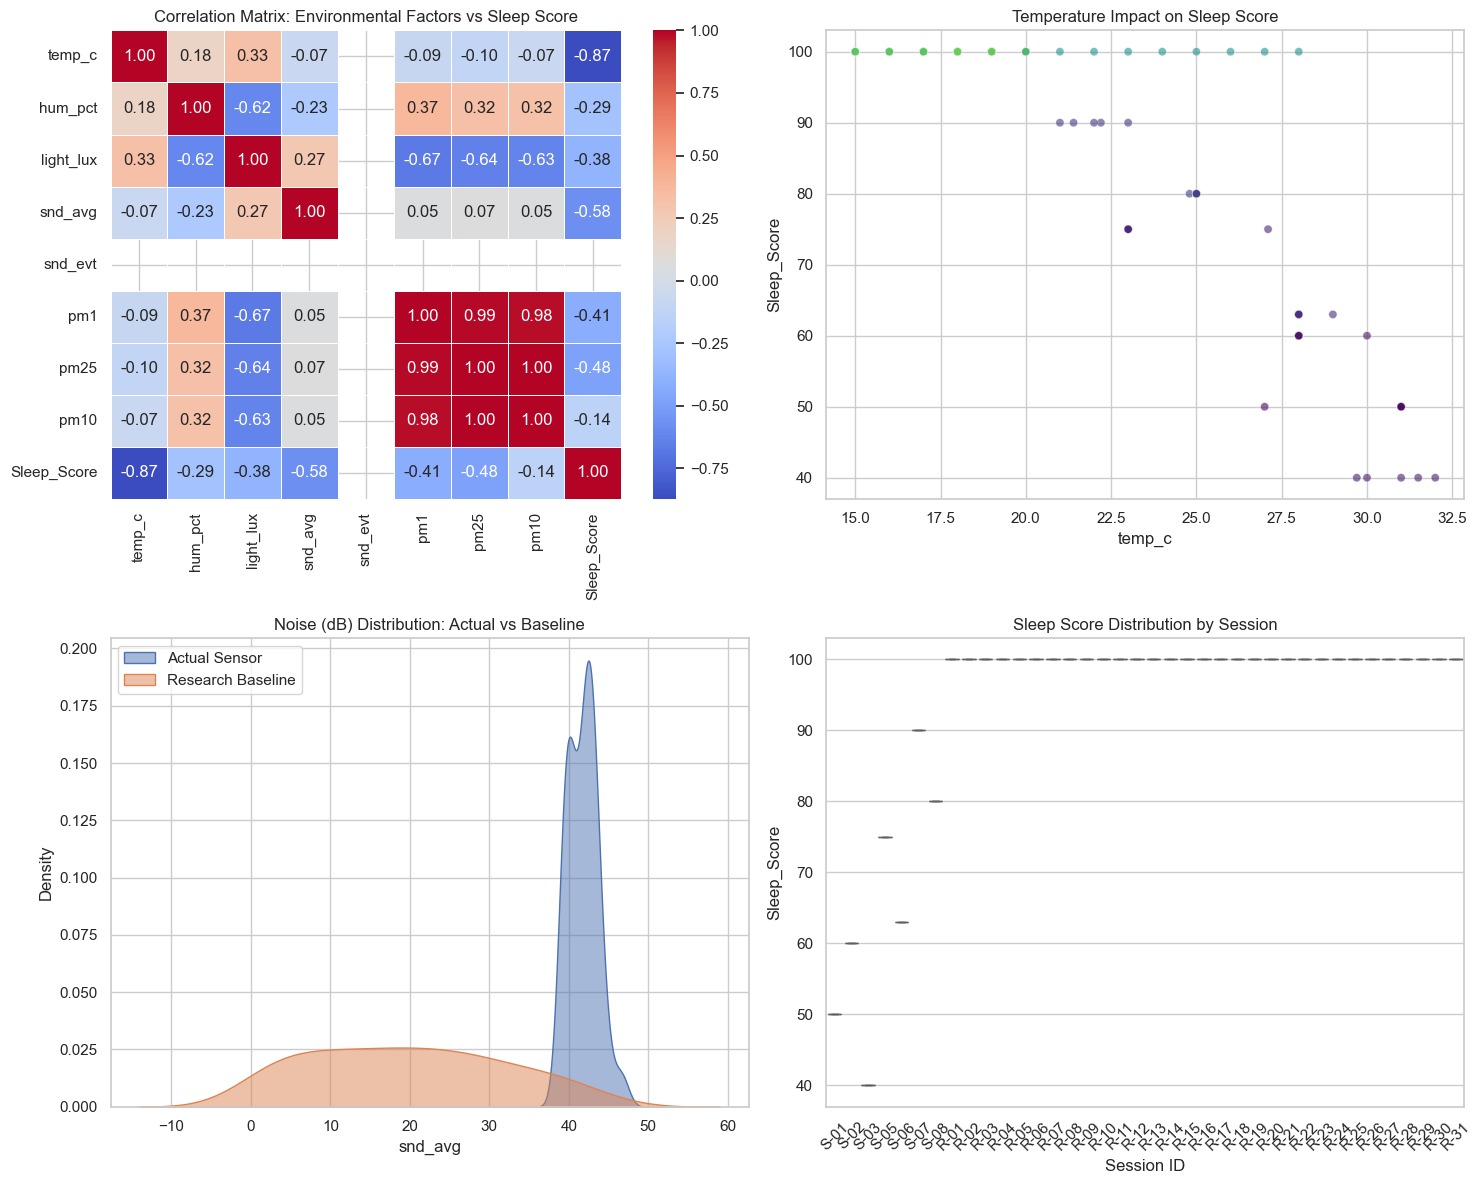


Final Integrated Data Table (Top 10 Rows):


,Session ID,recorded_at,temp_c,hum_pct,light_lux,snd_avg,snd_evt,pm1,pm25,pm10,Sleep_Score
0,S-01,2026-03-24 16:42:14+00:00,27.0,45.0,26.05,41.97,0.0,12.0,14.3,14.6,50
1,S-01,2026-03-24 18:24:27+00:00,31.0,48.1,4.43,39.27,0.0,11.7,13.6,13.8,50
2,S-01,2026-03-24 20:06:40+00:00,31.0,61.3,4.57,39.58,0.0,15.6,19.0,20.2,50
3,S-01,2026-03-24 21:59:08+00:00,31.0,62.1,4.54,40.66,0.0,15.3,19.1,19.5,50
4,S-01,2026-03-25 00:22:18+00:00,31.0,62.8,11.46,41.97,0.0,15.9,19.5,19.6,50
...,...,...,...,...,...,...,...,...,...,...,...
474,R-31,2026-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,100
475,R-31,2026-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,100
476,R-31,2026-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,100
477,R-31,2026-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,11.0,NaN,100


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Integrate the two datasets
# Combine Sensor (Actual) and Research (Baseline) tables
df_combined = pd.concat([df_sensor_sessions, df_research_sessions], ignore_index=True)

# Ensure data types are correct for EDA
numeric_cols = ['temp_c', 'hum_pct', 'light_lux', 'snd_avg', 'snd_evt', 'pm1', 'pm25', 'pm10', 'Sleep_Score']
df_combined[numeric_cols] = df_combined[numeric_cols].apply(pd.to_numeric, errors='coerce')

# 2. EDA: Statistical Summary
print("--- Combined Data Summary ---")
display(df_combined.describe())

# 3. Visualization: Data Trends and Impact
plt.figure(figsize=(15, 12))
sns.set_theme(style="whitegrid")

# Plot A: Correlation Heatmap
plt.subplot(2, 2, 1)
corr = df_combined[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix: Environmental Factors vs Sleep Score")

# Plot B: Temperature vs Sleep Score Distribution
plt.subplot(2, 2, 2)
sns.scatterplot(data=df_combined, x='temp_c', y='Sleep_Score', hue='Session ID', alpha=0.6, palette='viridis', legend=False)
plt.title("Temperature Impact on Sleep Score")

# Plot C: Noise Level Distribution (Sensor vs Research)
plt.subplot(2, 2, 3)
sns.kdeplot(data=df_sensor_sessions, x='snd_avg', label='Actual Sensor', fill=True, alpha=0.5)
sns.kdeplot(data=df_research_sessions, x='snd_avg', label='Research Baseline', fill=True, alpha=0.5)
plt.title("Noise (dB) Distribution: Actual vs Baseline")
plt.legend()

# Plot D: Boxplot of Sleep Scores per Session
plt.subplot(2, 2, 4)
sns.boxplot(data=df_combined, x='Session ID', y='Sleep_Score', hue='Session ID', palette='Set3', legend=False)
plt.xticks(rotation=45)
plt.title("Sleep Score Distribution by Session")

plt.tight_layout()
plt.show()

# Display consolidated final table
print("\nFinal Integrated Data Table (Top 10 Rows):")
display(df_combined)

# Exploratory Data Analysis (EDA)

This section provides a multi-faceted exploration of all three data sources **before** modeling, covering:

1. **Check-in & Sleep Behavior** — how many hours subjects sleep, score distributions, timing patterns
2. **Sensor Time-Series & Statistics** — raw sensor history across all 8 channels, gap with ideal ranges
3. **Session Environmental Profiles** — how conditions differ across actual sleep nights
4. **Distribution Comparison** — actual sensor sessions vs research ideal baselines for every factor
5. **Factor vs Sleep Score Relationships** — scatter plots + Pearson correlation ranking
6. **Data Quality & Coverage** — missing values, source breakdown, per-session completeness

> **Variables available here:** `df_sensor`, `df_checkin`, `df_sensor_sessions`, `df_research_sessions`, `df_combined`


## 1. Check-in & Sleep Behavior

Explores the **subjective check-in data**: how long subjects slept, their reported scores, when they went to bed, and whether duration correlates with how they felt.

C:\Users\proun\AppData\Local\Temp\ipykernel_5672\351316028.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


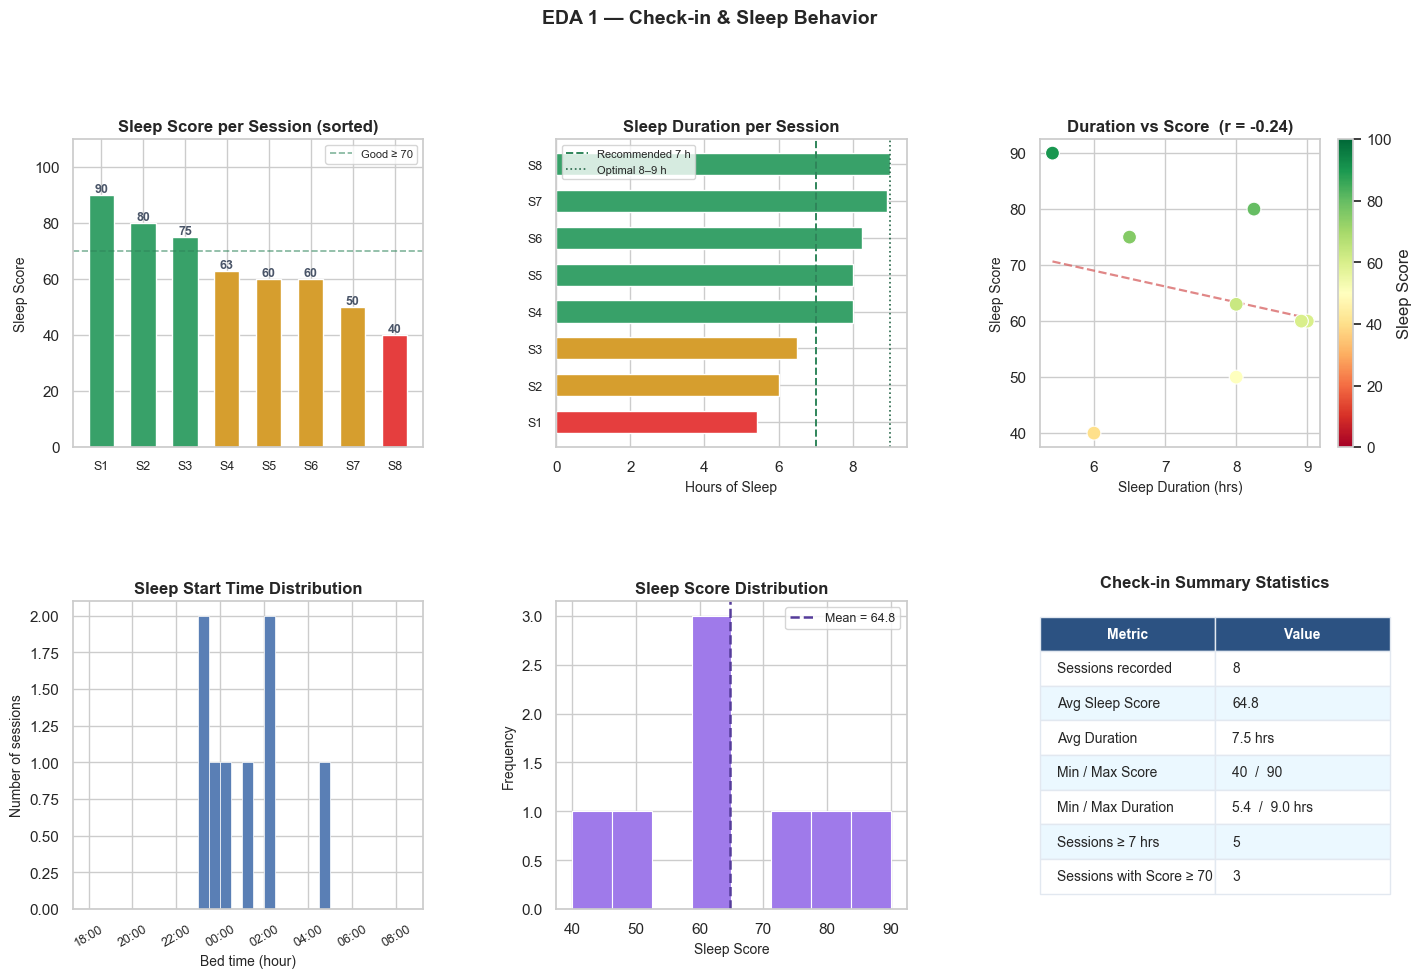

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

df_ci = df_checkin.copy()
df_ci.columns = [c.strip() for c in df_ci.columns]
df_ci['Sleep Score']          = pd.to_numeric(df_ci['Sleep Score'], errors='coerce')
df_ci['Sleep Duration (hrs)'] = (df_ci['End Time'] - df_ci['Start Time']).dt.total_seconds() / 3600
df_ci['Start Hour']           = df_ci['Start Time'].dt.hour + df_ci['Start Time'].dt.minute / 60

fig = plt.figure(figsize=(17, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)

# ── A: Sleep Score bar chart (sorted high→low) ──────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
scores_sorted = df_ci['Sleep Score'].dropna().sort_values(ascending=False)
palette_rg    = ['#38a169' if s >= 70 else '#d69e2e' if s >= 50 else '#e53e3e' for s in scores_sorted]
bars = ax1.bar(range(len(scores_sorted)), scores_sorted.values, color=palette_rg, width=0.6, edgecolor='white')
for i, v in enumerate(scores_sorted.values):
    ax1.text(i, v + 1.0, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold', color='#4a5568')
ax1.set_xticks(range(len(scores_sorted)))
ax1.set_xticklabels([f'S{j+1}' for j in range(len(scores_sorted))], fontsize=9)
ax1.set_ylabel('Sleep Score', fontsize=10)
ax1.set_ylim(0, 110)
ax1.set_title('Sleep Score per Session (sorted)', fontweight='bold')
ax1.axhline(70, color='#2f855a', linestyle='--', linewidth=1.2, alpha=0.6, label='Good ≥ 70')
ax1.legend(fontsize=8)

# ── B: Sleep duration per session ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
dur_sorted = df_ci.dropna(subset=['Sleep Duration (hrs)']).sort_values('Sleep Duration (hrs)', ascending=True)
dur_colors = ['#38a169' if d >= 7 else '#d69e2e' if d >= 6 else '#e53e3e'
              for d in dur_sorted['Sleep Duration (hrs)']]
ax2.barh(range(len(dur_sorted)), dur_sorted['Sleep Duration (hrs)'], color=dur_colors,
         height=0.6, edgecolor='white')
ax2.axvline(7, color='#2f855a', linestyle='--', linewidth=1.4, label='Recommended 7 h')
ax2.axvline(9, color='#276749', linestyle=':',  linewidth=1.2, label='Optimal 8–9 h')
ax2.set_yticks(range(len(dur_sorted)))
ax2.set_yticklabels([f'S{i+1}' for i in range(len(dur_sorted))], fontsize=9)
ax2.set_xlabel('Hours of Sleep', fontsize=10)
ax2.set_title('Sleep Duration per Session', fontweight='bold')
ax2.legend(fontsize=8)

# ── C: Duration vs Score scatter + trend ───────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
dv = df_ci.dropna(subset=['Sleep Duration (hrs)', 'Sleep Score'])
sc = ax3.scatter(dv['Sleep Duration (hrs)'], dv['Sleep Score'],
                 c=dv['Sleep Score'], cmap='RdYlGn', vmin=0, vmax=100,
                 s=100, zorder=3, edgecolors='white', linewidth=0.8)
plt.colorbar(sc, ax=ax3, label='Sleep Score')
if len(dv) >= 2:
    z = np.polyfit(dv['Sleep Duration (hrs)'], dv['Sleep Score'], 1)
    xr = np.linspace(dv['Sleep Duration (hrs)'].min(), dv['Sleep Duration (hrs)'].max(), 50)
    ax3.plot(xr, np.poly1d(z)(xr), 'r--', linewidth=1.6, alpha=0.75)
    r = dv['Sleep Duration (hrs)'].corr(dv['Sleep Score'])
    ax3.set_title(f'Duration vs Score  (r = {r:.2f})', fontweight='bold')
else:
    ax3.set_title('Duration vs Score', fontweight='bold')
ax3.set_xlabel('Sleep Duration (hrs)', fontsize=10)
ax3.set_ylabel('Sleep Score', fontsize=10)

# ── D: Sleep start time histogram ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
start_hrs = df_ci['Start Hour'].dropna()
bins = np.arange(18, 33, 0.5)        # 18:00 → 32:00 (= next-day 08:00)
start_wrapped = start_hrs.apply(lambda h: h + 24 if h < 12 else h)
ax4.hist(start_wrapped, bins=bins, color='#5a7fb5', edgecolor='white', linewidth=0.5)
tick_vals = np.arange(18, 33, 2)
ax4.set_xticks(tick_vals)
ax4.set_xticklabels([f'{int(h%24):02d}:00' for h in tick_vals], fontsize=9, rotation=30)
ax4.set_xlabel('Bed time (hour)', fontsize=10)
ax4.set_ylabel('Number of sessions', fontsize=10)
ax4.set_title('Sleep Start Time Distribution', fontweight='bold')

# ── E: Score histogram ──────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(df_ci['Sleep Score'].dropna(), bins=8, color='#9f7aea',
         edgecolor='white', linewidth=0.8)
mean_s = df_ci['Sleep Score'].mean()
ax5.axvline(mean_s, color='#553c9a', linestyle='--', linewidth=1.8, label=f'Mean = {mean_s:.1f}')
ax5.set_xlabel('Sleep Score', fontsize=10)
ax5.set_ylabel('Frequency', fontsize=10)
ax5.set_title('Sleep Score Distribution', fontweight='bold')
ax5.legend(fontsize=9)

# ── F: Summary stats table ──────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
stats_data = [
    ['Sessions recorded',       f"{len(df_ci)}"],
    ['Avg Sleep Score',          f"{df_ci['Sleep Score'].mean():.1f}"],
    ['Avg Duration',             f"{df_ci['Sleep Duration (hrs)'].mean():.1f} hrs"],
    ['Min / Max Score',          f"{df_ci['Sleep Score'].min():.0f}  /  {df_ci['Sleep Score'].max():.0f}"],
    ['Min / Max Duration',       f"{df_ci['Sleep Duration (hrs)'].min():.1f}  /  {df_ci['Sleep Duration (hrs)'].max():.1f} hrs"],
    ['Sessions ≥ 7 hrs',         f"{(df_ci['Sleep Duration (hrs)'] >= 7).sum()}"],
    ['Sessions with Score ≥ 70', f"{(df_ci['Sleep Score'] >= 70).sum()}"],
]
tbl = ax6.table(cellText=stats_data, colLabels=['Metric', 'Value'],
                cellLoc='left', loc='center', bbox=[0, 0.05, 1, 0.9])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#e2e8f0')
    if r == 0:
        cell.set_facecolor('#2c5282'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#ebf8ff')
ax6.set_title('Check-in Summary Statistics', fontweight='bold', pad=10)

fig.suptitle('EDA 1 — Check-in & Sleep Behavior', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 2. Sensor Time-Series & Statistics

Plots the **full history** of all 8 environmental channels from the IoT sensor. The green band shows each factor's **research-ideal** range. The summary table compares real readings against those ideal thresholds.

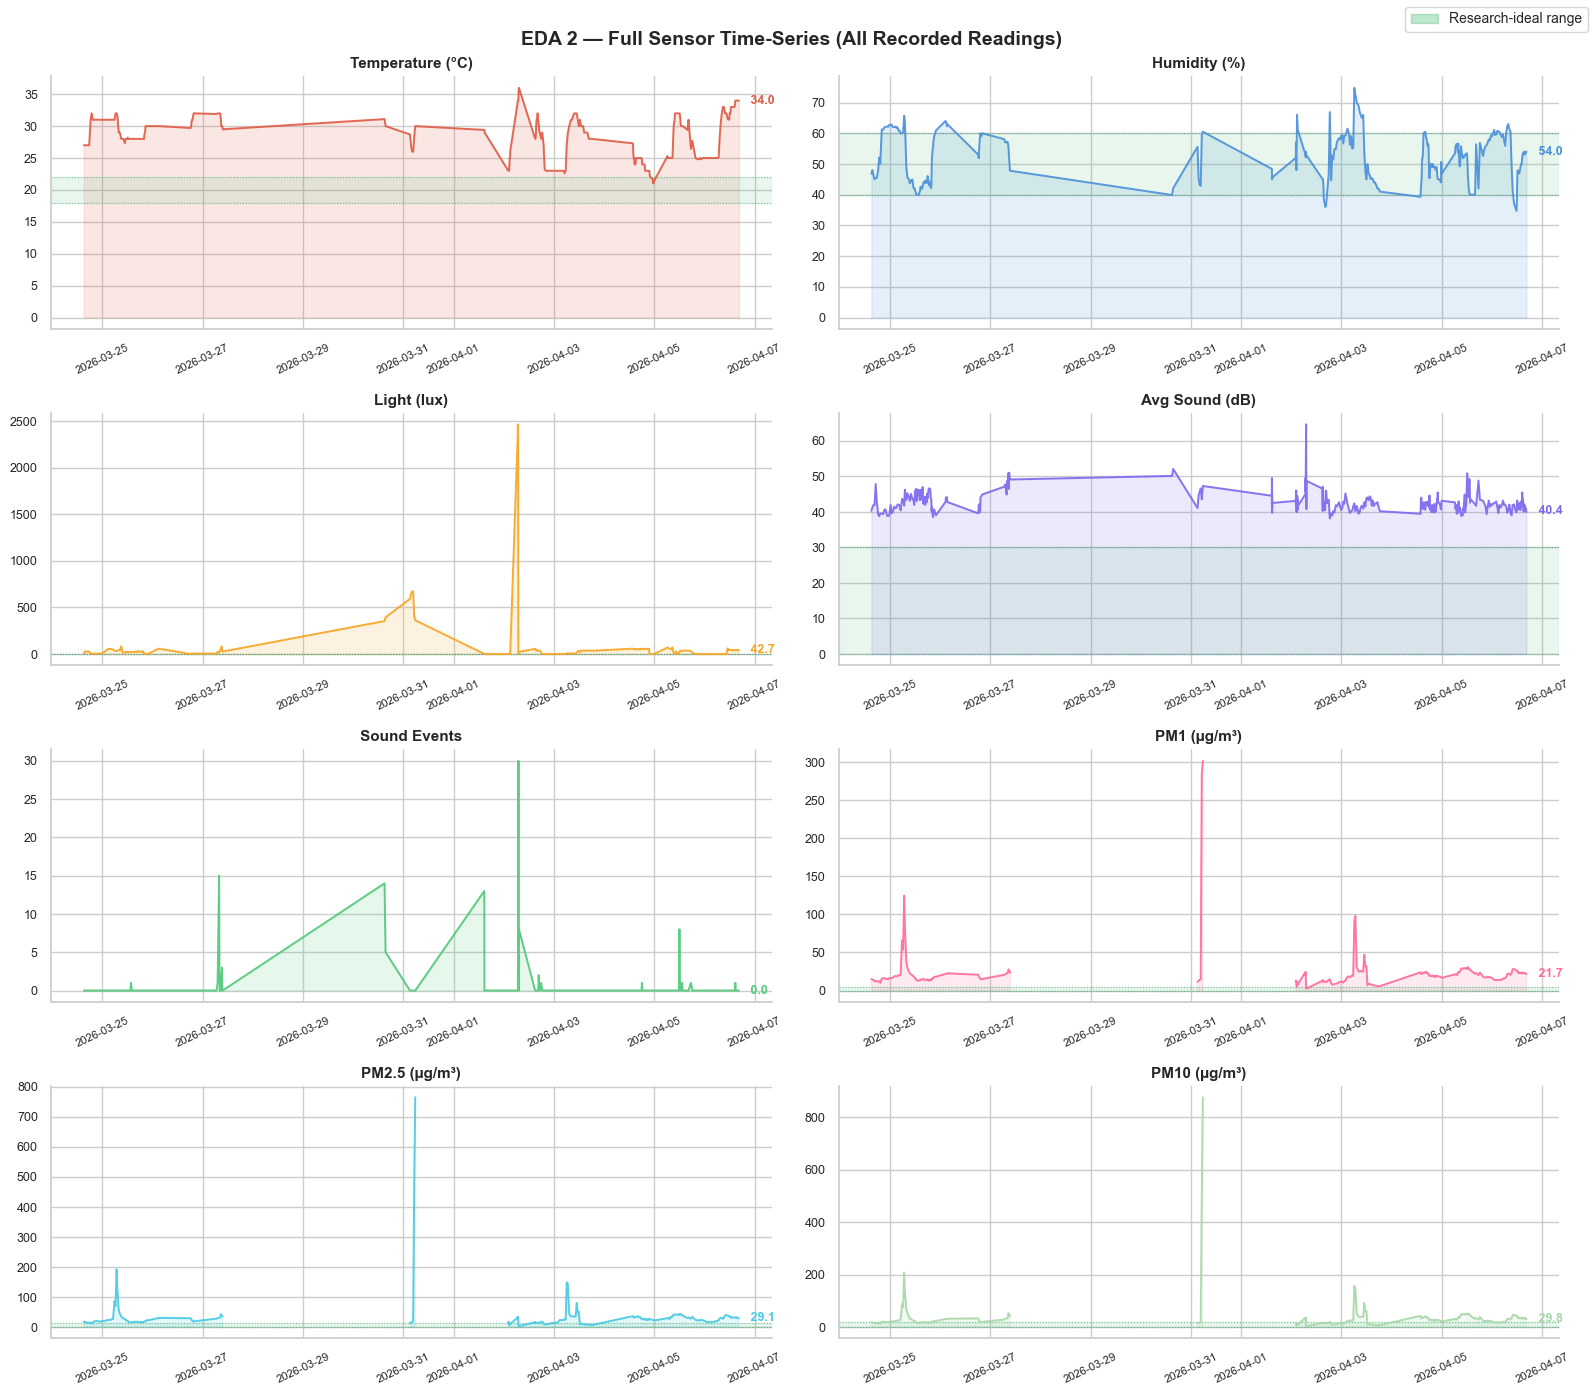

─── Sensor Statistics vs Research Ideal Ranges ───


,Factor,N readings,Mean,Std,Min,Max,Ideal range,% in ideal
0,Temperature (°C),431,28.13,3.64,21.00,36.00,18.0–22.0,1%
1,Humidity (%),431,51.84,7.60,34.70,74.80,40.0–60.0,80%
2,Light (lux),431,76.50,322.32,0.00,2467.99,0.0–5.0,39%
3,Avg Sound (dB),431,43.27,3.58,38.18,64.68,0.0–30.0,0%
4,Sound Events,431,0.80,4.03,0.00,30.00,0.0–0.0,92%
5,PM1 (µg/m³),405,19.82,22.23,2.50,301.80,0.0–5.0,2%
6,PM2.5 (µg/m³),405,27.72,46.52,2.83,765.30,0.0–12.0,15%
7,PM10 (µg/m³),405,29.75,51.91,2.83,876.90,0.0–20.0,43%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid")

ALL_FACTORS = ['temp_c', 'hum_pct', 'light_lux', 'snd_avg', 'snd_evt', 'pm1', 'pm25', 'pm10']
FACTOR_LABELS = {
    'temp_c':    'Temperature (°C)',
    'hum_pct':   'Humidity (%)',
    'light_lux': 'Light (lux)',
    'snd_avg':   'Avg Sound (dB)',
    'snd_evt':   'Sound Events',
    'pm1':       'PM1 (µg/m³)',
    'pm25':      'PM2.5 (µg/m³)',
    'pm10':      'PM10 (µg/m³)',
}
IDEAL = {                        # (ideal_lo, ideal_hi)
    'temp_c':    (18.0, 22.0),
    'hum_pct':   (40.0, 60.0),
    'light_lux': (0.0,   5.0),
    'snd_avg':   (0.0,  30.0),
    'snd_evt':   (0.0,   0.0),
    'pm1':       (0.0,   5.0),
    'pm25':      (0.0,  12.0),
    'pm10':      (0.0,  20.0),
}
COLORS = ['#e05a44','#4a90d9','#f5a623','#7b68ee','#50c878','#ff6b9d','#48cae4','#a8d8a8']

df_s = df_sensor.copy().sort_values('recorded_at')

# ── Full time-series: 4×2 grid ───────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(ALL_FACTORS):
    ax    = axes[i]
    color = COLORS[i]
    vals  = pd.to_numeric(df_s[col], errors='coerce')
    times = df_s['recorded_at']

    ax.plot(times, vals, color=color, linewidth=1.4, alpha=0.9, zorder=3)
    ax.fill_between(times, vals, alpha=0.14, color=color)

    lo, hi = IDEAL[col]
    if hi > 0:
        ax.axhspan(lo, hi, color='#48bb78', alpha=0.12, zorder=1)
        ax.axhline(lo, color='#38a169', linewidth=0.8, linestyle=':', alpha=0.6)
        ax.axhline(hi, color='#38a169', linewidth=0.8, linestyle=':', alpha=0.6)

    # Annotate latest value
    last_val = vals.dropna().iloc[-1] if not vals.dropna().empty else None
    if last_val is not None:
        ax.annotate(f' {last_val:.1f}',
                    xy=(times.iloc[-1], last_val),
                    xytext=(6, 0), textcoords='offset points',
                    fontsize=9, color=color, fontweight='bold', va='center')

    ax.set_title(FACTOR_LABELS[col], fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=25, labelsize=8)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ideal_patch = mpatches.Patch(color='#48bb78', alpha=0.35, label='Research-ideal range')
fig.legend(handles=[ideal_patch], loc='upper right', fontsize=10)
fig.suptitle('EDA 2 — Full Sensor Time-Series (All Recorded Readings)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary statistics vs ideal ranges ───────────────────────────────────────
stat_rows = []
for col in ALL_FACTORS:
    vals = pd.to_numeric(df_s[col], errors='coerce').dropna()
    lo, hi = IDEAL[col]
    if hi > 0:
        pct_ideal = ((vals >= lo) & (vals <= hi)).mean() * 100
    else:
        pct_ideal = (vals == 0).mean() * 100
    stat_rows.append({
        'Factor':       FACTOR_LABELS[col],
        'N readings':   len(vals),
        'Mean':         round(vals.mean(), 2),
        'Std':          round(vals.std(),  2),
        'Min':          round(vals.min(),  2),
        'Max':          round(vals.max(),  2),
        'Ideal range':  f"{lo}–{hi}",
        '% in ideal':   f"{pct_ideal:.0f}%",
    })

print('─── Sensor Statistics vs Research Ideal Ranges ───')
display(pd.DataFrame(stat_rows))


## 3. Session Environmental Profiles

Shows how the **8 environmental factors differ across each actual sleep session**. Two heatmaps are presented side-by-side: raw median values (to read exact numbers) and a 0–1 normalized view (to compare which factor was relatively high or low on a given night). A per-session summary table is shown below.

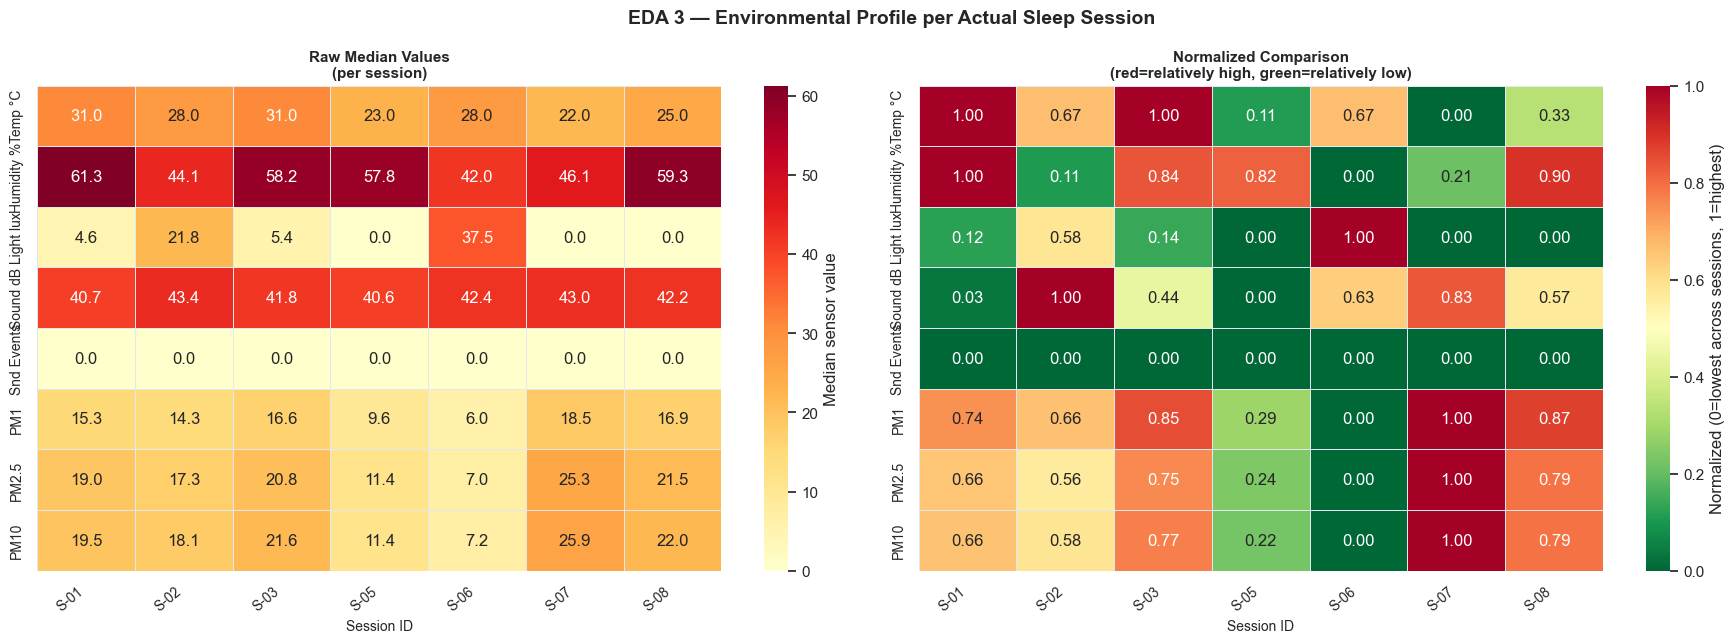

─── Session-level Medians (Actual Sensor Sessions) ───


,Sleep_Score,temp_c,hum_pct,light_lux,snd_avg,snd_evt,pm1,pm25,pm10
Session ID,,,,,,,,,
S-01,50.0,31.0,61.3,4.57,40.66,0.0,15.3,19.0,19.5
S-02,60.0,28.0,44.1,21.80,43.43,0.0,14.3,17.3,18.1
S-03,40.0,31.0,58.2,5.37,41.84,0.0,16.6,20.8,21.6
S-05,75.0,23.0,57.8,0.00,40.57,0.0,9.6,11.4,11.4
S-06,63.0,28.0,42.0,37.52,42.38,0.0,6.0,7.0,7.2
S-07,90.0,22.0,46.1,0.00,42.95,0.0,18.5,25.3,25.9
S-08,80.0,25.0,59.3,0.00,42.19,0.0,16.9,21.5,22.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

ALL_FACTORS   = ['temp_c','hum_pct','light_lux','snd_avg','snd_evt','pm1','pm25','pm10']
FACTOR_LABELS = ['Temp °C','Humidity %','Light lux','Sound dB','Snd Events','PM1','PM2.5','PM10']

if df_sensor_sessions.empty:
    print("No actual sensor sessions available — skipping session profile plots.")
else:
    df_ss = df_sensor_sessions.copy()
    for col in ALL_FACTORS:
        df_ss[col] = pd.to_numeric(df_ss[col], errors='coerce')
    df_ss['Sleep_Score'] = pd.to_numeric(df_ss['Sleep_Score'], errors='coerce')

    session_med = df_ss.groupby('Session ID')[ALL_FACTORS + ['Sleep_Score']].median()
    # Only keep sessions with at least some data
    session_med = session_med.dropna(how='all', subset=ALL_FACTORS)

    # Normalize 0–1 for the right panel
    env_data   = session_med[ALL_FACTORS]
    env_norm   = (env_data - env_data.min()) / (env_data.max() - env_data.min() + 1e-9)

    fig, axes = plt.subplots(1, 2, figsize=(18, max(4, len(session_med) * 0.65 + 2)))

    # ── Left: raw medians ───────────────────────────────────────────────────
    sns.heatmap(
        env_data.T, ax=axes[0],
        cmap='YlOrRd', annot=True, fmt='.1f',
        linewidths=0.6, linecolor='#e2e8f0',
        cbar_kws={'label': 'Median sensor value'},
    )
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right', fontsize=10)
    axes[0].set_yticklabels(FACTOR_LABELS, fontsize=10)
    axes[0].set_title('Raw Median Values\n(per session)', fontweight='bold', fontsize=11)
    axes[0].set_xlabel('Session ID', fontsize=10)

    # ── Right: normalized (0=low relative to other sessions, 1=high) ────────
    # Color is now inverted: green=low (better for most factors), red=high
    sns.heatmap(
        env_norm.T, ax=axes[1],
        cmap='RdYlGn_r', annot=True, fmt='.2f',
        linewidths=0.6, linecolor='#e2e8f0',
        cbar_kws={'label': 'Normalized (0=lowest across sessions, 1=highest)'},
        vmin=0, vmax=1,
    )
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha='right', fontsize=10)
    axes[1].set_yticklabels(FACTOR_LABELS, fontsize=10)
    axes[1].set_title('Normalized Comparison\n(red=relatively high, green=relatively low)',
                      fontweight='bold', fontsize=11)
    axes[1].set_xlabel('Session ID', fontsize=10)

    fig.suptitle('EDA 3 — Environmental Profile per Actual Sleep Session',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Session summary table with Sleep Score ───────────────────────────────
    summary_tbl = session_med.round(2).copy()
    summary_tbl.insert(0, 'Sleep_Score', summary_tbl.pop('Sleep_Score'))
    print('─── Session-level Medians (Actual Sensor Sessions) ───')
    display(summary_tbl)


## 4. Distribution Comparison: Actual Sessions vs Research Baseline

For each of the 8 environmental factors, overlaid KDE curves compare the **real sensor distributions** (red) against the **research ideal ranges** (blue). Dashed vertical lines mark the group means. Overlap tells us how close real-world conditions are to the research benchmarks.

C:\Users\proun\AppData\Local\Temp\ipykernel_5672\444756539.py:34: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(actual,   ax=ax, fill=True, alpha=0.40,


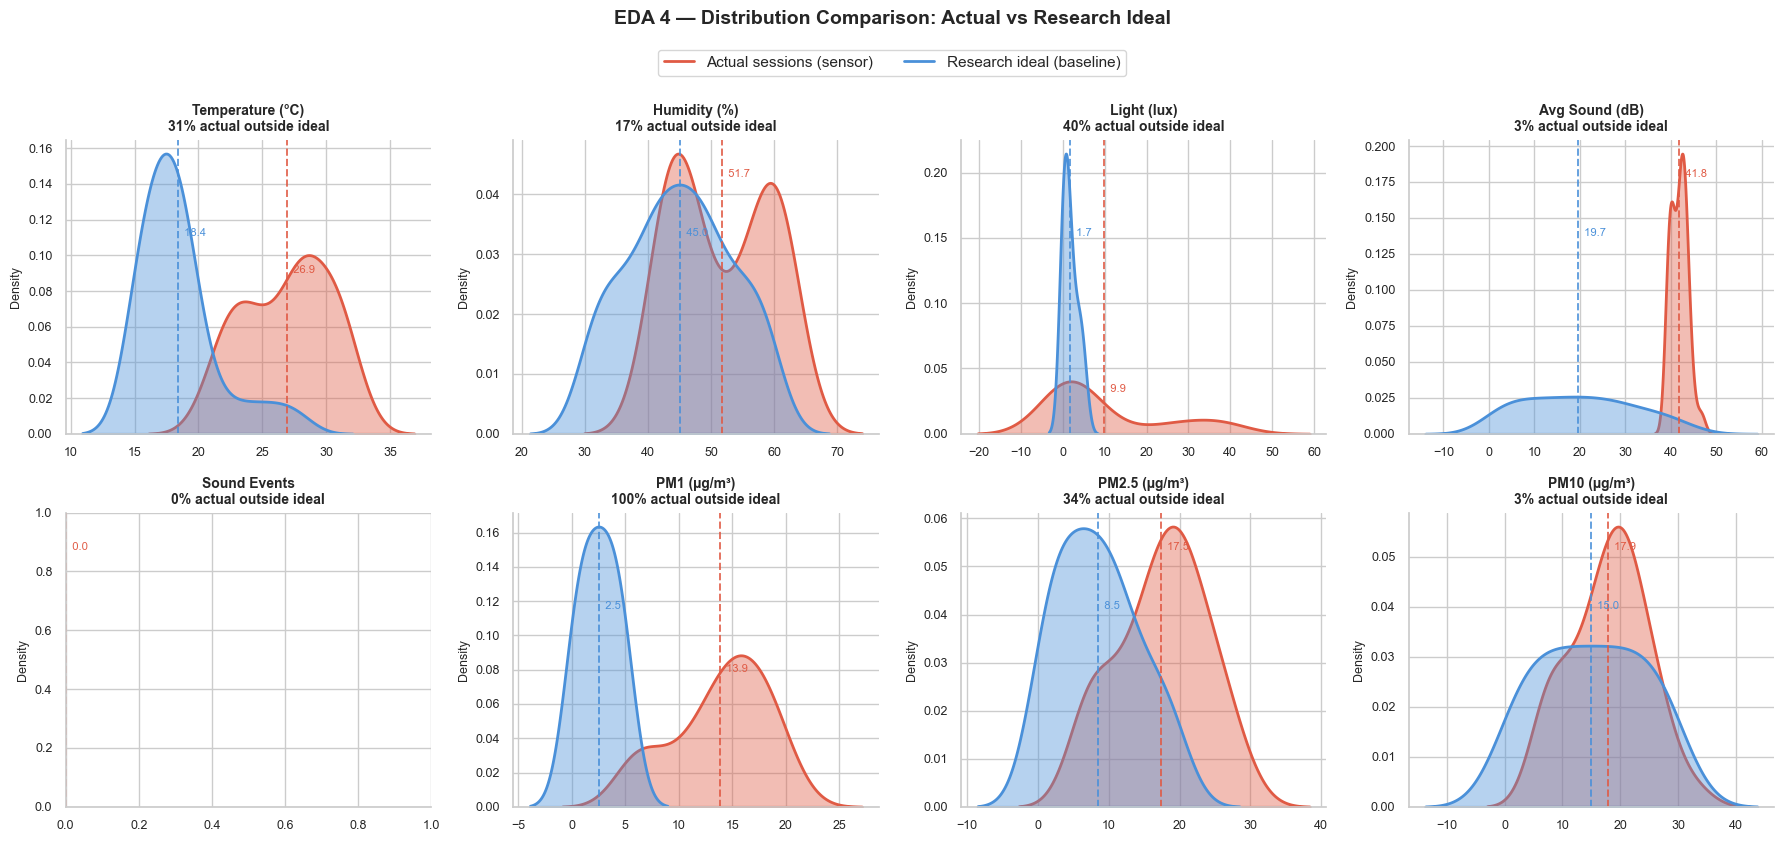

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

sns.set_theme(style="whitegrid")

ALL_FACTORS   = ['temp_c','hum_pct','light_lux','snd_avg','snd_evt','pm1','pm25','pm10']
FACTOR_LABELS = {
    'temp_c':    'Temperature (°C)',
    'hum_pct':   'Humidity (%)',
    'light_lux': 'Light (lux)',
    'snd_avg':   'Avg Sound (dB)',
    'snd_evt':   'Sound Events',
    'pm1':       'PM1 (µg/m³)',
    'pm25':      'PM2.5 (µg/m³)',
    'pm10':      'PM10 (µg/m³)',
}
COLOR_ACTUAL   = '#e05a44'
COLOR_RESEARCH = '#4a90d9'

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(ALL_FACTORS):
    ax = axes[i]
    actual   = pd.to_numeric(df_sensor_sessions[col], errors='coerce').dropna() \
               if not df_sensor_sessions.empty else pd.Series(dtype=float)
    research = pd.to_numeric(df_research_sessions[col], errors='coerce').dropna() \
               if not df_research_sessions.empty else pd.Series(dtype=float)

    if len(actual) > 1:
        sns.kdeplot(actual,   ax=ax, fill=True, alpha=0.40,
                    color=COLOR_ACTUAL,   linewidth=2.0, label='Actual sensor')
        ax.axvline(actual.mean(),   color=COLOR_ACTUAL,   linestyle='--',
                   linewidth=1.4, alpha=0.85)
        ax.text(actual.mean(), ax.get_ylim()[1] * 0.9,
                f'  {actual.mean():.1f}', color=COLOR_ACTUAL, fontsize=8, va='top')
    elif len(actual) == 1:
        ax.axvline(actual.iloc[0], color=COLOR_ACTUAL, linewidth=2,
                   linestyle='-', label=f'Actual = {actual.iloc[0]:.1f}')

    if len(research) > 1:
        sns.kdeplot(research, ax=ax, fill=True, alpha=0.40,
                    color=COLOR_RESEARCH, linewidth=2.0, label='Research ideal')
        ax.axvline(research.mean(), color=COLOR_RESEARCH, linestyle='--',
                   linewidth=1.4, alpha=0.85)
        ax.text(research.mean(), ax.get_ylim()[1] * 0.70,
                f'  {research.mean():.1f}', color=COLOR_RESEARCH, fontsize=8, va='top')

    # Percentage gap: how many actual readings are OUTSIDE the research range
    if len(actual) > 0 and len(research) > 0:
        r_lo, r_hi = research.min(), research.max()
        pct_outside = ((actual < r_lo) | (actual > r_hi)).mean() * 100
        ax.set_title(f'{FACTOR_LABELS[col]}\n{pct_outside:.0f}% actual outside ideal',
                     fontweight='bold', fontsize=10)
    else:
        ax.set_title(FACTOR_LABELS[col], fontweight='bold', fontsize=10)

    ax.set_xlabel('')
    ax.set_ylabel('Density', fontsize=9)
    ax.tick_params(labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Shared legend at top
actual_patch   = mlines.Line2D([], [], color=COLOR_ACTUAL,   linewidth=2, label='Actual sessions (sensor)')
research_patch = mlines.Line2D([], [], color=COLOR_RESEARCH, linewidth=2, label='Research ideal (baseline)')
fig.legend(handles=[actual_patch, research_patch], loc='upper center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.01))

fig.suptitle('EDA 4 — Distribution Comparison: Actual vs Research Ideal',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


## 5. Factor vs Sleep Score Relationships

Eight scatter plots (one per factor) with a regression trend line. Data points are color-coded by source: **red = actual sensor sessions**, **blue = research baseline**. The bottom panel ranks all 8 factors by their **Pearson correlation with Sleep Score**, making it easy to see which environmental variable is most predictive.

c:\Users\proun\Downloads\archive-889266F7-7168-4BE1-B3B8-274F567DA2D1\Users\supakritaphonmaeklong\Code\proud-da-final\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\proun\Downloads\archive-889266F7-7168-4BE1-B3B8-274F567DA2D1\Users\supakritaphonmaeklong\Code\proud-da-final\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


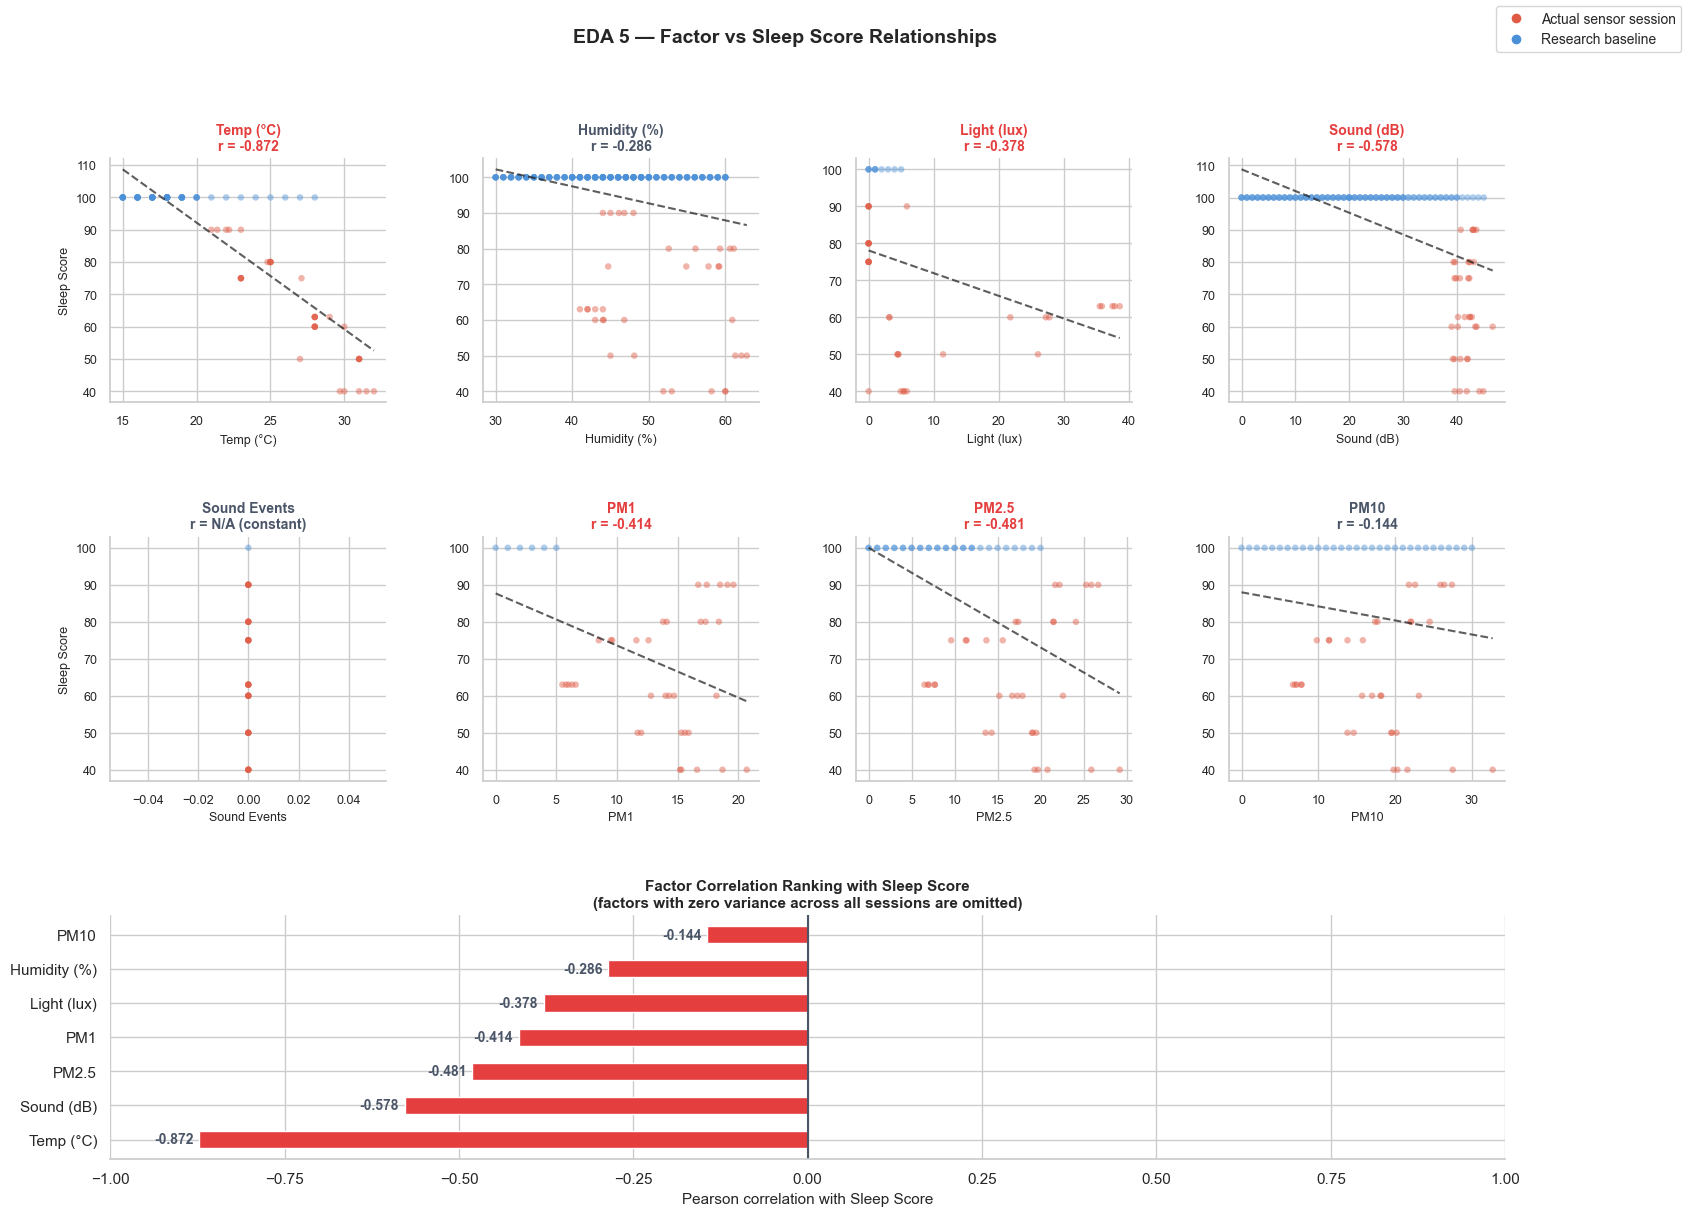


─── Pearson Correlation Summary ───
           r with Sleep_Score                         note
temp_c              -0.872287                             
snd_avg             -0.577865                             
pm25                -0.481165                             
pm1                 -0.414361                             
light_lux           -0.378443                             
hum_pct             -0.285964                             
pm10                -0.143653                             
snd_evt                   NaN  constant column — undefined


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

sns.set_theme(style="whitegrid")

ALL_FACTORS   = ['temp_c','hum_pct','light_lux','snd_avg','snd_evt','pm1','pm25','pm10']
FACTOR_LABELS = ['Temp (°C)','Humidity (%)','Light (lux)','Sound (dB)',
                 'Sound Events','PM1','PM2.5','PM10']

numeric_cols = ALL_FACTORS + ['Sleep_Score']
df_plot = df_combined[numeric_cols + ['Session ID']].copy()
for col in numeric_cols:
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

source_color = df_plot['Session ID'].apply(
    lambda x: '#e05a44' if str(x).startswith('S') else '#4a90d9'
)
df_clean = df_plot.dropna(subset=['Sleep_Score'])

# Correlation ranking
corrs = df_clean[ALL_FACTORS].corrwith(df_clean['Sleep_Score'])

# ── Layout: 2×4 scatter grid + full-width correlation bar ───────────────────
fig = plt.figure(figsize=(18, 13))
gs  = plt.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.35)

for i, (col, label) in enumerate(zip(ALL_FACTORS, FACTOR_LABELS)):
    row = i // 4
    col_idx = i % 4
    ax = fig.add_subplot(gs[row, col_idx])

    ax.scatter(df_plot[col], df_plot['Sleep_Score'],
               c=source_color, alpha=0.45, s=22, zorder=3, edgecolors='none')

    sub = df_clean[[col, 'Sleep_Score']].dropna()
    # Guard: skip polyfit if column is constant (zero variance causes SVD failure)
    has_variance = len(sub) >= 3 and sub[col].std() > 1e-9 and sub['Sleep_Score'].std() > 1e-9
    if has_variance:
        try:
            z  = np.polyfit(sub[col], sub['Sleep_Score'], 1)
            xr = np.linspace(sub[col].min(), sub[col].max(), 60)
            ax.plot(xr, np.poly1d(z)(xr), 'k--', linewidth=1.5, alpha=0.70, zorder=4)
        except np.linalg.LinAlgError:
            pass  # constant-like column after dropna; skip trend line
    r = corrs[col]
    r_str = f'{r:+.3f}' if pd.notna(r) else 'N/A (constant)'
    r_color = '#e53e3e' if pd.notna(r) and r < -0.3 else '#38a169' if pd.notna(r) and r > 0.3 else '#4a5568'
    ax.set_title(f'{label}\nr = {r_str}', fontsize=10, fontweight='bold', color=r_color)

    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Sleep Score' if col_idx == 0 else '', fontsize=9)
    ax.tick_params(labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Bottom: correlation bar chart (full width) ───────────────────────────────
ax_corr = fig.add_subplot(gs[2, :])
# Drop NaN correlations (arise from zero-variance columns like snd_evt=0 everywhere)
corrs_sorted = corrs.dropna().sort_values()
bar_colors   = ['#e53e3e' if v < 0 else '#38a169' for v in corrs_sorted]
bar_labels   = [FACTOR_LABELS[ALL_FACTORS.index(c)] for c in corrs_sorted.index]

bars = ax_corr.barh(bar_labels, corrs_sorted.values, color=bar_colors,
                    height=0.50, edgecolor='white')
ax_corr.axvline(0, color='#4a5568', linewidth=1.5)
for bar, val in zip(bars, corrs_sorted.values):
    x_pos = val + (0.008 if val >= 0 else -0.008)
    ha    = 'left' if val >= 0 else 'right'
    ax_corr.text(x_pos, bar.get_y() + bar.get_height() / 2,
                 f'{val:+.3f}', va='center', ha=ha, fontsize=10, fontweight='bold',
                 color='#4a5568')
ax_corr.set_xlabel('Pearson correlation with Sleep Score', fontsize=11)
ax_corr.set_title('Factor Correlation Ranking with Sleep Score\n'
                  '(factors with zero variance across all sessions are omitted)',
                  fontweight='bold', fontsize=11)
ax_corr.spines['top'].set_visible(False)
ax_corr.spines['right'].set_visible(False)
ax_corr.spines['left'].set_visible(False)
ax_corr.set_xlim(-1.0, 1.0)

# Legend
actual_dot   = mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#e05a44', markersize=8, label='Actual sensor session')
research_dot = mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#4a90d9', markersize=8, label='Research baseline')
fig.legend(handles=[actual_dot, research_dot], loc='upper right', fontsize=10)

fig.suptitle('EDA 5 — Factor vs Sleep Score Relationships', fontsize=14, fontweight='bold')
plt.show()

print('\n─── Pearson Correlation Summary ───')
corr_summary = corrs.sort_values().rename('r with Sleep_Score')
corr_summary = corr_summary.to_frame()
corr_summary['note'] = corr_summary['r with Sleep_Score'].apply(
    lambda v: 'constant column — undefined' if pd.isna(v) else ''
)
print(corr_summary.to_string())


## 6. Data Quality & Coverage

Three complementary views of data completeness:
- **Missing-value map** — every row of the combined dataset with red cells marking NaN
- **Source breakdown** — how many rows come from real sensor sessions vs research baseline
- **Per-session completeness** — percentage of factor readings that are present for each actual sleep session

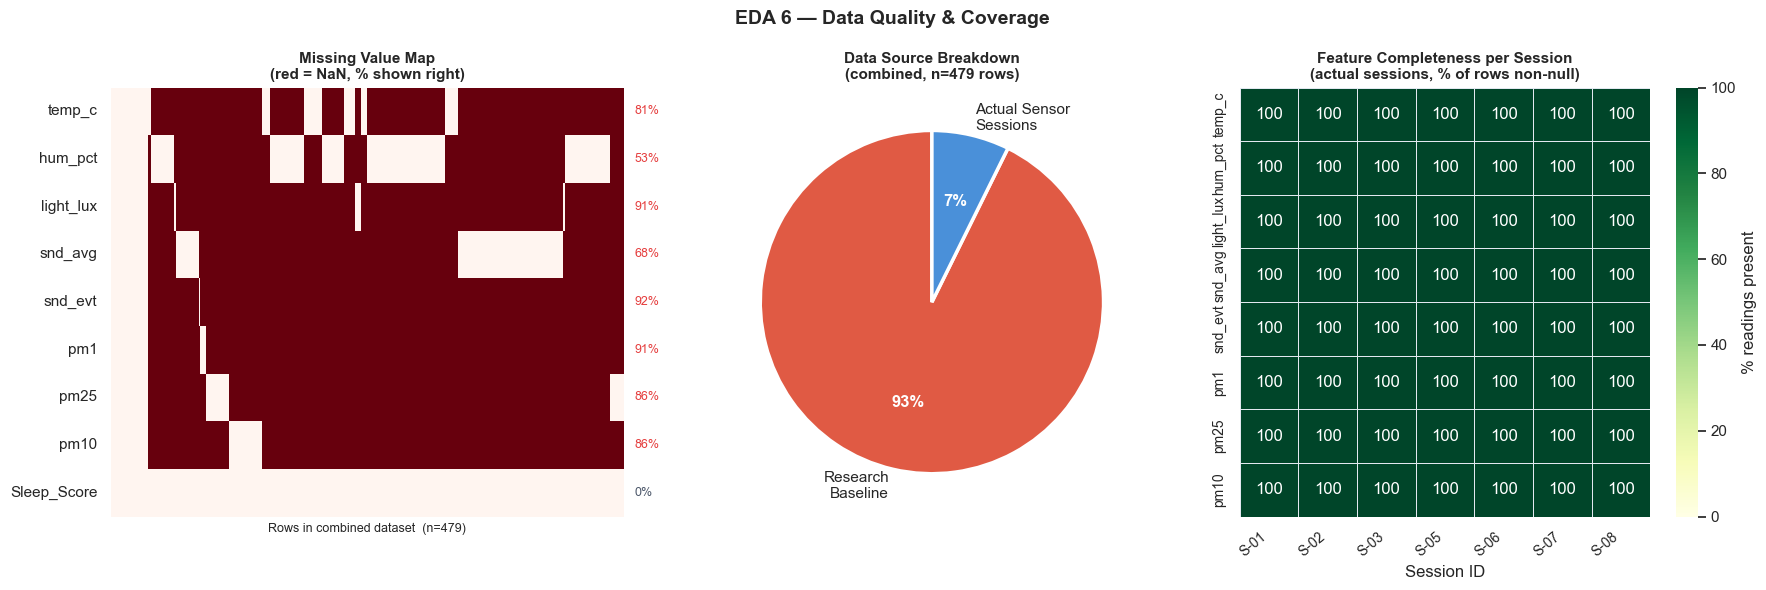


─── Dataset Coverage Summary ───


,Dataset,Total rows,Unique sessions,% Sleep_Score NaN
0,df_sensor (full history),431,—,—
1,df_checkin (check-in),8,8,0%
2,df_sensor_sessions,35,7,0%
3,df_research_sessions,444,31,0%
4,df_combined,479,38,0%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid")

ALL_FACTORS = ['temp_c','hum_pct','light_lux','snd_avg','snd_evt','pm1','pm25','pm10']
DISPLAY_COLS = ALL_FACTORS + ['Sleep_Score']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── A: Missing value map (combined dataset) ──────────────────────────────────
ax = axes[0]
df_miss = df_combined[DISPLAY_COLS].apply(pd.to_numeric, errors='coerce').isnull().astype(int)
sns.heatmap(df_miss.T, ax=ax, cmap='Reds', cbar=False,
            xticklabels=False, yticklabels=DISPLAY_COLS,
            linewidths=0, vmin=0, vmax=1)
for i, col in enumerate(DISPLAY_COLS):
    pct = df_miss[col].mean() * 100
    ax.text(len(df_miss) * 1.02, i + 0.5, f'{pct:.0f}%',
            va='center', fontsize=9, color='#e53e3e' if pct > 50 else '#4a5568')
ax.set_title('Missing Value Map\n(red = NaN, % shown right)',
             fontweight='bold', fontsize=11)
ax.set_xlabel(f'Rows in combined dataset  (n={len(df_combined)})', fontsize=9)
ax.set_ylabel('')

# ── B: Data source pie chart ─────────────────────────────────────────────────
ax = axes[1]
source_label = df_combined['Session ID'].apply(
    lambda x: 'Actual Sensor\nSessions' if str(x).startswith('S') else 'Research\nBaseline'
)
counts  = source_label.value_counts()
palette = ['#e05a44', '#4a90d9']
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.0f%%',
    colors=palette,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    textprops={'fontsize': 11},
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('white')
ax.set_title(f'Data Source Breakdown\n(combined, n={len(df_combined)} rows)',
             fontweight='bold', fontsize=11)

# ── C: Per-session completeness (actual sessions only) ───────────────────────
ax = axes[2]
if not df_sensor_sessions.empty:
    df_ss = df_sensor_sessions.copy()
    for col in ALL_FACTORS:
        df_ss[col] = pd.to_numeric(df_ss[col], errors='coerce')
    completeness = (
        df_ss.groupby('Session ID')[ALL_FACTORS]
        .apply(lambda g: g.notna().mean() * 100)
    )
    sns.heatmap(
        completeness.T, ax=ax,
        cmap='YlGn', annot=True, fmt='.0f',
        linewidths=0.6, linecolor='#e2e8f0',
        vmin=0, vmax=100,
        cbar_kws={'label': '% readings present'},
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=10)
    ax.set_yticklabels(ALL_FACTORS, fontsize=10)
    ax.set_title('Feature Completeness per Session\n(actual sessions, % of rows non-null)',
                 fontweight='bold', fontsize=11)
else:
    ax.text(0.5, 0.5, 'No actual sensor sessions loaded',
            ha='center', va='center', fontsize=12, color='#718096')
    ax.axis('off')

fig.suptitle('EDA 6 — Data Quality & Coverage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Dataset coverage summary table ───────────────────────────────────────────
def safe_nunique_sessions(df):
    return df['Session ID'].nunique() if 'Session ID' in df.columns and not df.empty else 0

def safe_score_nan(df, col='Sleep Score'):
    if df.empty:
        return '—'
    c = col if col in df.columns else 'Sleep_Score'
    if c not in df.columns:
        return '—'
    return f"{pd.to_numeric(df[c], errors='coerce').isna().mean()*100:.0f}%"

rows = [
    ['df_sensor (full history)',  len(df_sensor),             '—',                              '—'],
    ['df_checkin (check-in)',     len(df_checkin),            len(df_checkin),                  safe_score_nan(df_checkin)],
    ['df_sensor_sessions',        len(df_sensor_sessions),    safe_nunique_sessions(df_sensor_sessions), safe_score_nan(df_sensor_sessions, 'Sleep_Score')],
    ['df_research_sessions',      len(df_research_sessions),  safe_nunique_sessions(df_research_sessions), safe_score_nan(df_research_sessions, 'Sleep_Score')],
    ['df_combined',               len(df_combined),           safe_nunique_sessions(df_combined), safe_score_nan(df_combined, 'Sleep_Score')],
]
print('\n─── Dataset Coverage Summary ───')
display(pd.DataFrame(rows, columns=['Dataset', 'Total rows', 'Unique sessions', '% Sleep_Score NaN']))


## Modeling-oriented preprocessing (before regression)

**Why not only `StandardScaler`?** Environmental IoT data mixes scales (°C vs lux vs µg/m³), heavy tails (PM, light spikes), and **many repeated sensor rows per night** that share one subjective **Sleep Score**. Fitting on raw repeated rows inflates \(n\) and breaks the usual independence assumption, which makes coefficients and \(R^2\) optimistic.

**What we do instead (all tied to this use case):**

1. **Session-level aggregation (median per `Session ID`)** — One representative environment vector per scored sleep episode; medians resist short spikes better than means.
2. **Block-wise transforms in a `ColumnTransformer`:**
   - **`log1p` + `RobustScaler`** on `light_lux`, `snd_evt`, `pm1`, `pm25`, `pm10` — non-negative, right-skewed channels (particles, events, light) where a log-like compression is standard in environmental modeling.
   - **Winsorize (5th–95th percentile on the training split) + `RobustScaler`** on `temp_c`, `hum_pct`, `snd_avg` — comfort and noise level are roughly linear but still prone to outliers; winsorizing limits leverage of bad readings while `RobustScaler` (median/IQR) stays stable if tails remain.
3. **`GroupShuffleSplit` by session** — When there are enough distinct sessions, we report error on **held-out nights** so metrics reflect generalization across sessions, not across duplicated timestamps.

The final **`Pipeline`** is refit on **all** session rows for deployment (`optimize_sleep` and live API scoring) so production uses the full signal.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, RobustScaler

# --- 1) Session-level design matrix (one row per scored sleep episode) ---
all_factors = ['temp_c', 'hum_pct', 'light_lux', 'snd_avg', 'snd_evt', 'pm1', 'pm25', 'pm10']

agg_map = {c: 'median' for c in all_factors}
agg_map['Sleep_Score'] = 'median'

df_session = (
    df_combined.groupby('Session ID', as_index=False)
    .agg(agg_map)
    .dropna(subset=['Sleep_Score'])
)

print(
    f"Session-level table: {len(df_session)} rows "
    f"(aggregated from {len(df_combined)} raw rows across "
    f"{df_combined['Session ID'].nunique()} session ids)"
)


class Winsorizer(BaseEstimator, TransformerMixin):
    """Per-feature quantile clipping fit on training data only (reduces sensor spike leverage)."""

    def __init__(self, lower_q=0.05, upper_q=0.95):
        self.lower_q = lower_q
        self.upper_q = upper_q

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lo_ = np.nanquantile(X, self.lower_q, axis=0)
        self.hi_ = np.nanquantile(X, self.upper_q, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lo_, self.hi_)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


# ── Adaptive: apply log1p only where data actually shows meaningful positive skew ──
# With a small dataset the distribution often doesn't match the textbook assumption
# that PM / light is always right-skewed.  We measure first, decide second.
SKEW_THRESHOLD = 0.75   # rule-of-thumb: |skew| > 0.75 warrants a transformation

feature_skew = {
    c: pd.to_numeric(df_session[c], errors='coerce').dropna().skew()
    for c in all_factors
}

# log1p is only valid for non-negative features AND only helps when skew is truly positive
log_skewed = [
    c for c in all_factors
    if pd.notna(feature_skew.get(c))
    and feature_skew[c] > SKEW_THRESHOLD
    and pd.to_numeric(df_session[c], errors='coerce').min() >= 0
]
comfort_linear = [c for c in all_factors if c not in log_skewed]

print(f"Skewness-based feature assignment  (threshold > {SKEW_THRESHOLD}):")
for c in all_factors:
    tag = '→ log1p + RobustScaler' if c in log_skewed else '→ Winsor  + RobustScaler'
    s   = feature_skew.get(c, float('nan'))
    print(f"  {c:12s}  skew = {s:+.2f}  {tag}")

# ── Sub-pipelines ──
log_block = Pipeline(
    steps=[
        ('impute', SimpleImputer(strategy='median')),
        ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('scale', RobustScaler()),
    ]
)

comfort_block = Pipeline(
    steps=[
        ('impute', SimpleImputer(strategy='median')),
        ('winsor', Winsorizer(lower_q=0.05, upper_q=0.95)),
        ('scale', RobustScaler()),
    ]
)

# ── ColumnTransformer — only include log_skew block if any features qualify ──
_transformers = []
if log_skewed:
    _transformers.append(('log_skew', log_block, log_skewed))
if comfort_linear:
    _transformers.append(('comfort', comfort_block, comfort_linear))

prep = ColumnTransformer(
    transformers=_transformers,
    remainder='drop',
    verbose_feature_names_out=False,
)

modeling_pipeline = Pipeline(steps=[('prep', prep), ('reg', LinearRegression())])

X_sess = df_session[all_factors]
y_sess = df_session['Sleep_Score']
groups = df_session['Session ID'].astype(str)

n_sessions = groups.nunique()
if n_sessions >= 3:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.35, random_state=42)
    train_idx, test_idx = next(gss.split(X_sess, y_sess, groups=groups))
    modeling_pipeline.fit(X_sess.iloc[train_idx], y_sess.iloc[train_idx])
    y_hat = modeling_pipeline.predict(X_sess.iloc[test_idx])
    print("\n--- Held-out sessions (GroupShuffleSplit) ---")
    print(f"Train sessions: {groups.iloc[train_idx].nunique()} | Test sessions: {groups.iloc[test_idx].nunique()}")
    print(f"MAE: {mean_absolute_error(y_sess.iloc[test_idx], y_hat):.3f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_sess.iloc[test_idx], y_hat)):.3f}")
    print(f"MAPE: {np.mean(np.abs((y_sess.iloc[test_idx] - y_hat) / y_sess.iloc[test_idx])*100):.3f} Percent")
    print(f"R²: {r2_score(y_sess.iloc[test_idx], y_hat):.3f}")

# Refit on all sessions for downstream scoring (optimize_sleep / API)
modeling_pipeline.fit(X_sess, y_sess)
print("\nFitted modeling_pipeline on all session-level rows for deployment.")


Session-level table: 38 rows (aggregated from 479 raw rows across 38 session ids)
Skewness-based feature assignment  (threshold > 0.75):
  temp_c        skew = +0.83  → log1p + RobustScaler
  hum_pct       skew = +0.52  → Winsor  + RobustScaler
  light_lux     skew = +2.04  → log1p + RobustScaler
  snd_avg       skew = -1.12  → Winsor  + RobustScaler
  snd_evt       skew = +0.00  → Winsor  + RobustScaler
  pm1           skew = -0.86  → Winsor  + RobustScaler
  pm25          skew = -0.10  → Winsor  + RobustScaler
  pm10          skew = -0.54  → Winsor  + RobustScaler

--- Held-out sessions (GroupShuffleSplit) ---
Train sessions: 24 | Test sessions: 14
MAE: 7.090
RMSE: 10.681
MAPE: 8.741 Percent
R²: 0.523

Fitted modeling_pipeline on all session-level rows for deployment.


### Preprocessing Visualizations

Five plots demonstrate **what each preprocessing step does to the data** and **why it matters** for modeling:

1. **Session Aggregation** — shows multiple raw sensor readings collapsing into one median per sleep night
2. **Adaptive Log1p Decision** — skewness is *measured* from the actual session data; log1p is only applied to features whose skewness exceeds 0.75, preventing the transformation from adding noise to features that aren't actually skewed
3. **Winsorization** — before/after for comfort features (temp, humidity, sound); 5th–95th percentile clipping removes extreme spikes without losing the variable
4. **Scale Normalization (RobustScaler)** — all 8 features on a common axis before vs after; models treat features equally only when scales are comparable
5. **GroupShuffleSplit** — which sessions are held out for testing vs used for training; ensures no single night appears in both sets


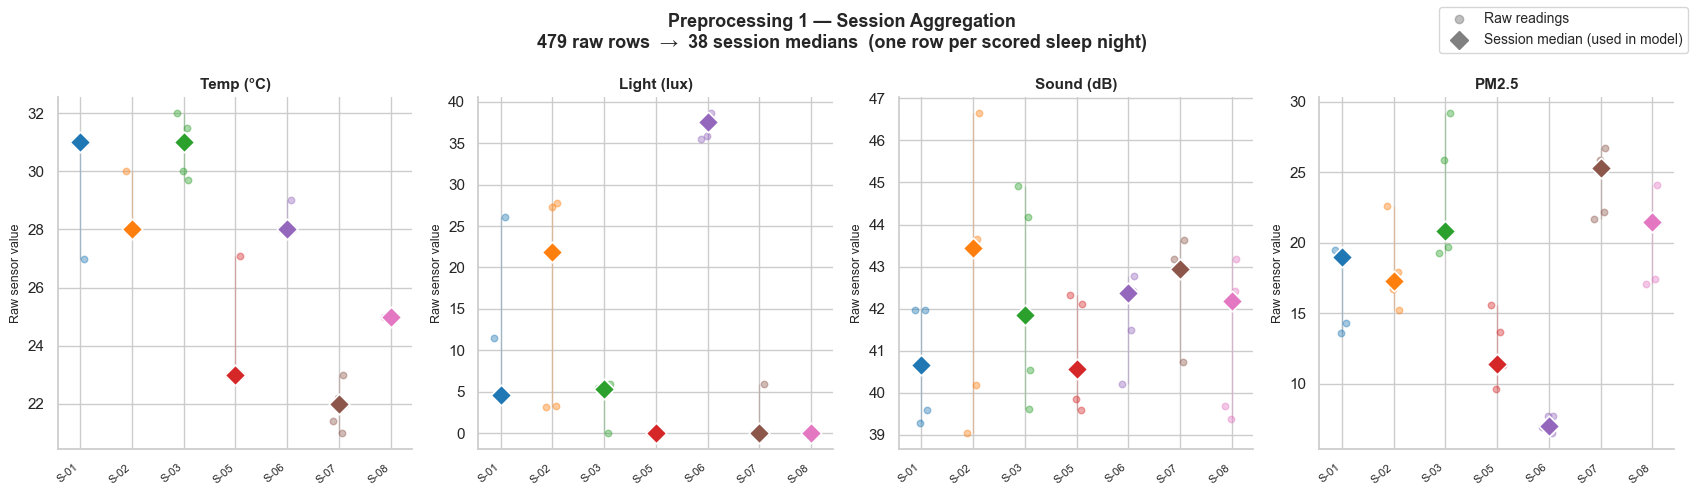

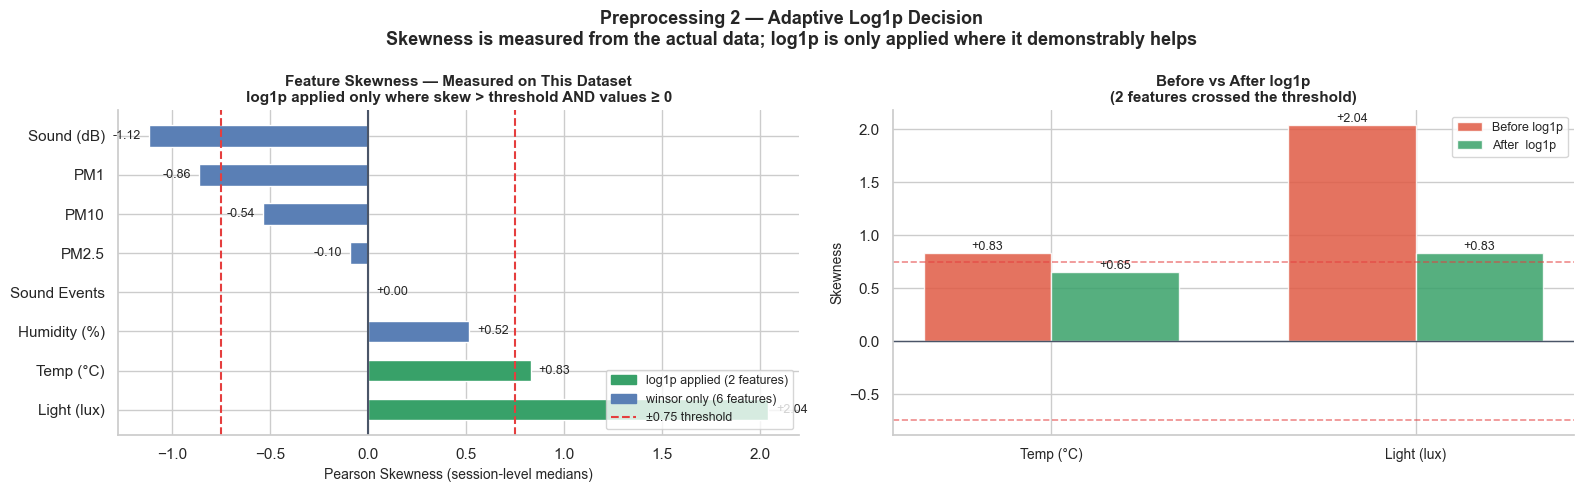

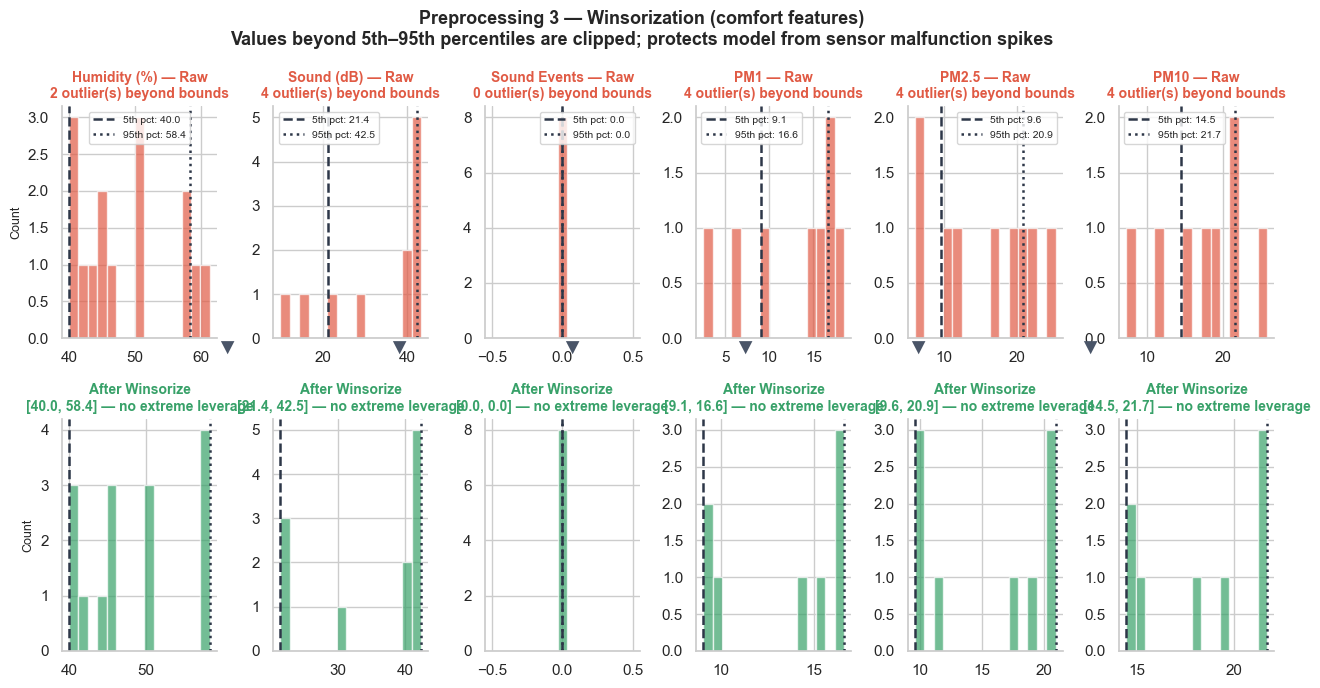

C:\Users\proun\AppData\Local\Temp\ipykernel_5672\1985416139.py:229: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\proun\AppData\Local\Temp\ipykernel_5672\1985416139.py:247: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


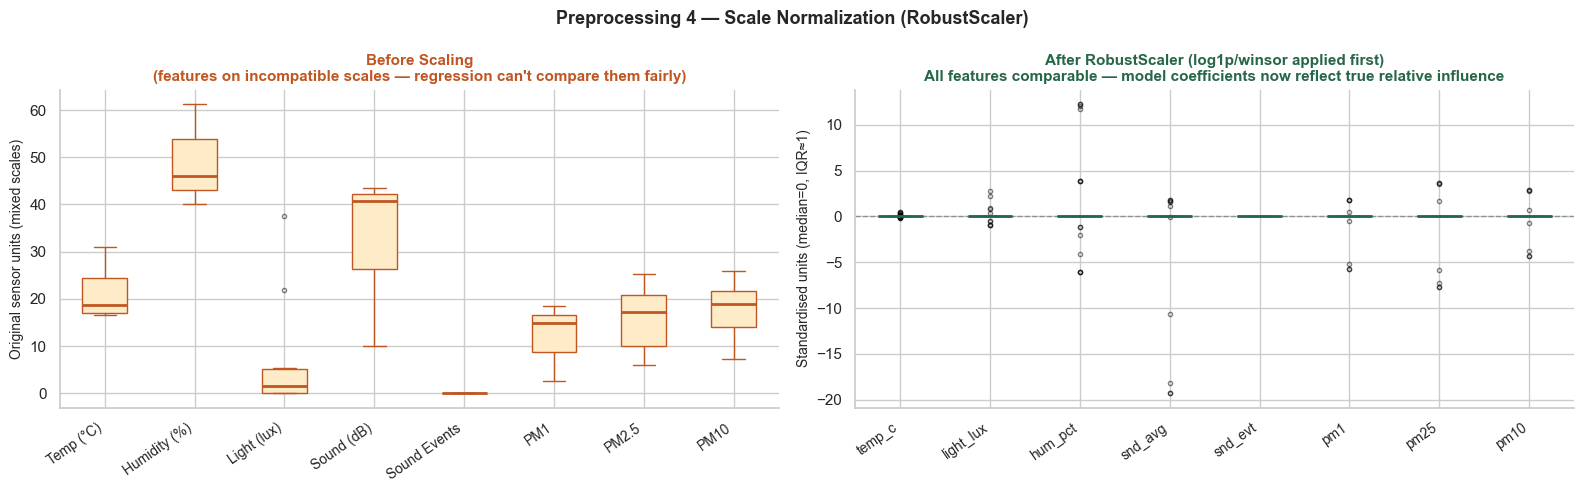

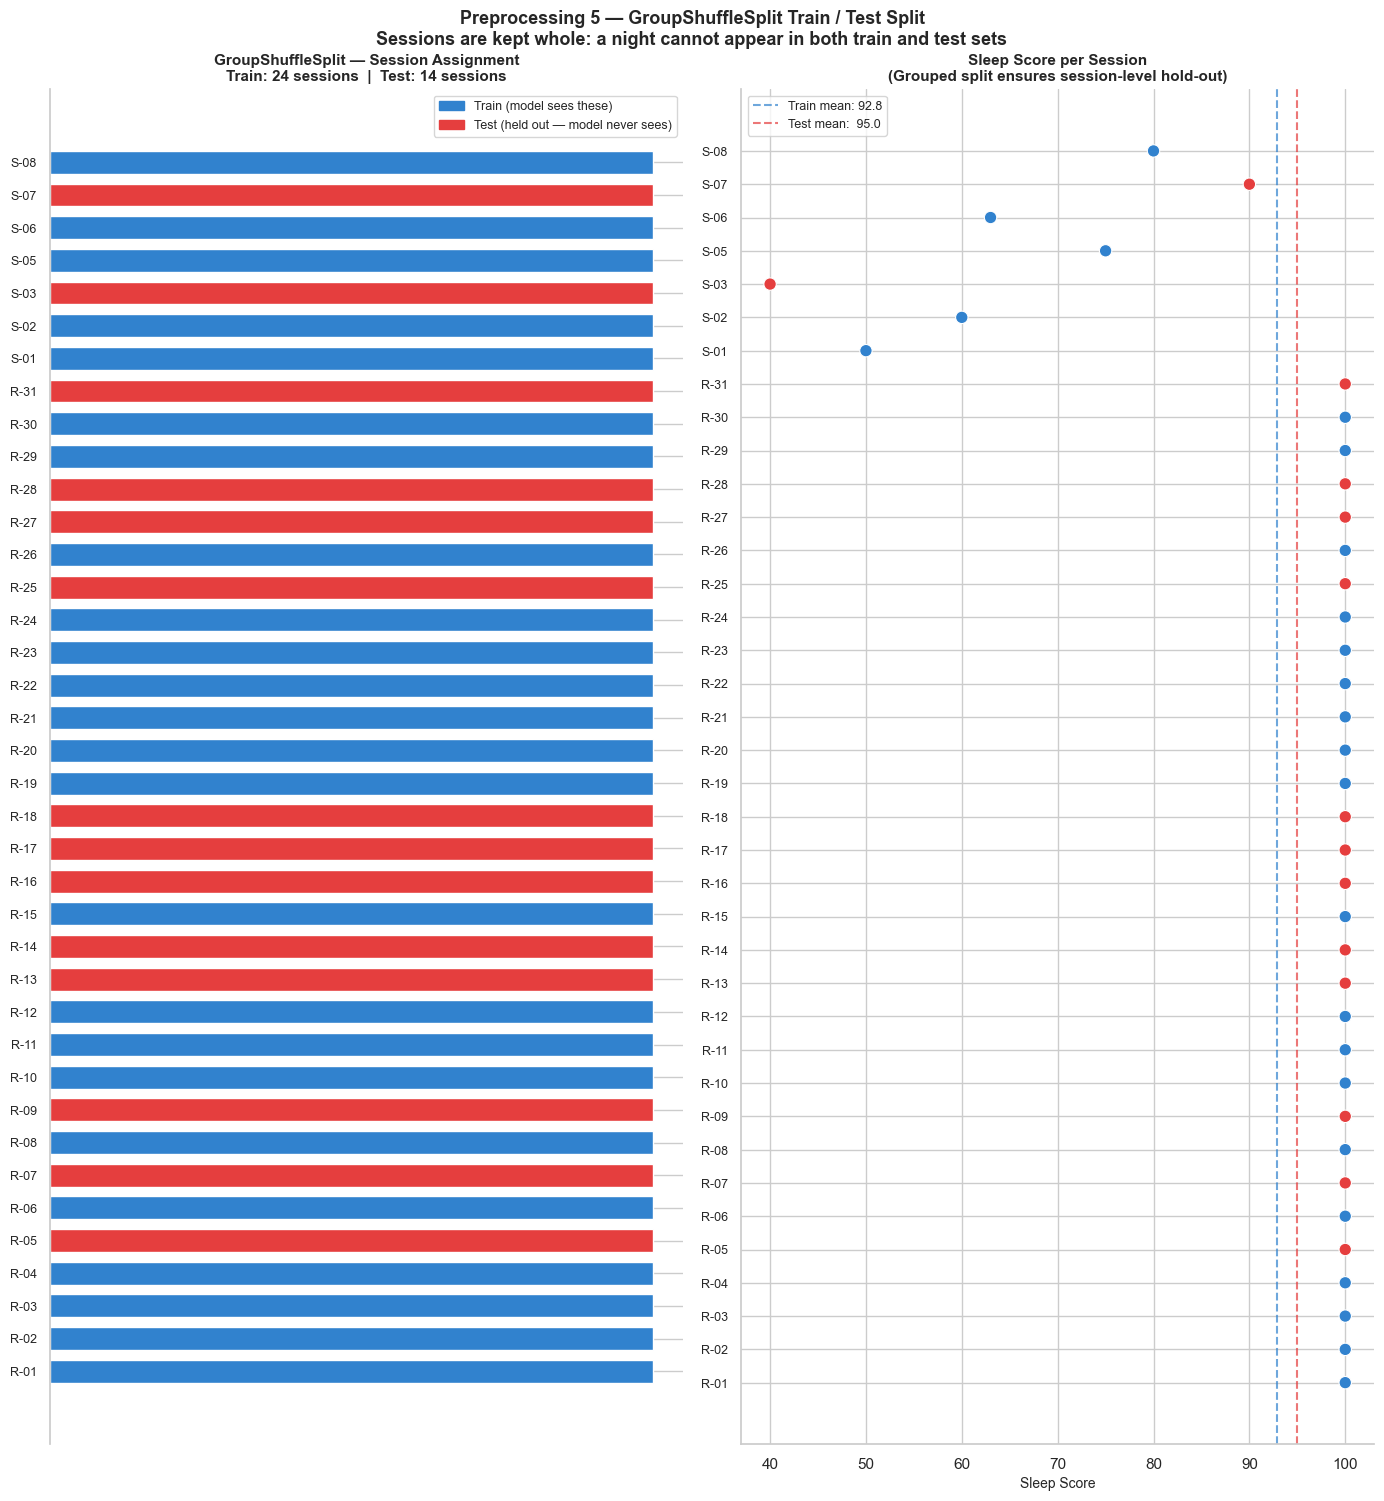

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from scipy import stats as sp_stats

sns.set_theme(style="whitegrid")

ALL_FACTORS  = ['temp_c','hum_pct','light_lux','snd_avg','snd_evt','pm1','pm25','pm10']
LOG_SKEWED   = log_skewed      # computed dynamically in preprocessing cell
COMFORT_COLS = comfort_linear  # remaining features
FLABELS = {
    'temp_c':    'Temp (°C)',   'hum_pct':   'Humidity (%)',
    'light_lux': 'Light (lux)', 'snd_avg':   'Sound (dB)',
    'snd_evt':   'Sound Events','pm1':       'PM1',
    'pm25':      'PM2.5',       'pm10':      'PM10',
}

# ─── Retrieve fitted pipeline objects ────────────────────────────────────────
_prep      = modeling_pipeline.named_steps['prep']
_winsor    = _prep.named_transformers_['comfort'].named_steps['winsor']
_rs_log    = _prep.named_transformers_['log_skew'].named_steps['scale']
_rs_com    = _prep.named_transformers_['comfort'].named_steps['scale']

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Session Aggregation: many raw rows → one session median
# ═══════════════════════════════════════════════════════════════════════════
SHOW_COLS = ['temp_c', 'light_lux', 'snd_avg', 'pm25']
df_raw = df_combined.copy()
for col in SHOW_COLS:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
df_raw = df_raw[df_raw['Session ID'].astype(str).str.startswith('S')]

session_ids = sorted(df_raw['Session ID'].unique())
palette     = sns.color_palette('tab10', len(session_ids))
sid_color   = {s: palette[i % len(palette)] for i, s in enumerate(session_ids)}

fig, axes = plt.subplots(1, len(SHOW_COLS), figsize=(17, 5))
for ax, col in zip(axes, SHOW_COLS):
    # Raw points
    for sid in session_ids:
        sub = df_raw[df_raw['Session ID'] == sid][col].dropna()
        if sub.empty:
            continue
        x_jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(sub)) + session_ids.index(sid)
        ax.scatter(x_jitter, sub, color=sid_color[sid], alpha=0.40, s=22, zorder=2)
        ax.scatter(session_ids.index(sid), sub.median(),
                   color=sid_color[sid], s=110, marker='D', edgecolors='white',
                   linewidth=1.2, zorder=4, label=sid)
        ax.vlines(session_ids.index(sid),
                  sub.min(), sub.max(),
                  colors=sid_color[sid], alpha=0.25, linewidth=1)

    ax.set_xticks(range(len(session_ids)))
    ax.set_xticklabels(session_ids, rotation=40, ha='right', fontsize=8)
    ax.set_title(FLABELS[col], fontweight='bold', fontsize=11)
    ax.set_ylabel('Raw sensor value', fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

raw_dot    = mlines.Line2D([], [], color='grey', marker='o', ms=6, alpha=0.5, linestyle='none', label='Raw readings')
median_dot = mlines.Line2D([], [], color='grey', marker='D', ms=9, linestyle='none', label='Session median (used in model)')
fig.legend(handles=[raw_dot, median_dot], loc='upper right', fontsize=10)
fig.suptitle(
    f'Preprocessing 1 — Session Aggregation\n'
    f'{len(df_combined)} raw rows  →  {len(df_session)} session medians  '
    f'(one row per scored sleep night)',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Skewness Analysis: measure first, transform only where it helps
# ═══════════════════════════════════════════════════════════════════════════
# With a small dataset features may not actually be right-skewed.
# We visualise the measured skewness, the decision threshold, and the
# before/after benefit only for features that genuinely qualified.

fig, (ax_bar, ax_delta) = plt.subplots(1, 2, figsize=(16, 5))

# ── Left panel: skewness bar chart for every feature ──
cols_by_skew = sorted(ALL_FACTORS, key=lambda c: feature_skew.get(c, 0), reverse=True)
skew_vals    = [feature_skew.get(c, float('nan')) for c in cols_by_skew]
bar_colors   = ['#38a169' if c in LOG_SKEWED else '#5a7fb5' for c in cols_by_skew]

bars = ax_bar.barh(
    [FLABELS[c] for c in cols_by_skew], skew_vals,
    color=bar_colors, height=0.55, edgecolor='white',
)
ax_bar.axvline(0,              color='#4a5568', linewidth=1.5)
ax_bar.axvline( SKEW_THRESHOLD, color='#e53e3e', linewidth=1.5,
                linestyle='--', label=f'+{SKEW_THRESHOLD} threshold')
ax_bar.axvline(-SKEW_THRESHOLD, color='#e53e3e', linewidth=1.5, linestyle='--')
for bar, val in zip(bars, skew_vals):
    if pd.notna(val):
        x_off = 0.04 if val >= 0 else -0.04
        ha    = 'left'  if val >= 0 else 'right'
        ax_bar.text(val + x_off, bar.get_y() + bar.get_height() / 2,
                    f'{val:+.2f}', va='center', ha=ha, fontsize=9)

green_p = mpatches.Patch(color='#38a169',
                          label=f'log1p applied ({len(LOG_SKEWED)} feature{"s" if len(LOG_SKEWED) != 1 else ""})')
blue_p  = mpatches.Patch(color='#5a7fb5',
                          label=f'winsor only ({len(COMFORT_COLS)} features)')
thr_l   = mlines.Line2D([], [], color='#e53e3e', linestyle='--',
                         linewidth=1.5, label=f'±{SKEW_THRESHOLD} threshold')
ax_bar.legend(handles=[green_p, blue_p, thr_l], fontsize=9, loc='lower right')
ax_bar.set_xlabel('Pearson Skewness (session-level medians)', fontsize=10)
ax_bar.set_title(
    'Feature Skewness — Measured on This Dataset\n'
    'log1p applied only where skew > threshold AND values ≥ 0',
    fontweight='bold', fontsize=11,
)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

# ── Right panel: before / after skewness delta for log1p features ──
if LOG_SKEWED:
    skew_before = [feature_skew[c] for c in LOG_SKEWED]
    skew_after  = [
        pd.to_numeric(X_sess[c], errors='coerce').dropna().apply(np.log1p).skew()
        for c in LOG_SKEWED
    ]
    x  = np.arange(len(LOG_SKEWED))
    w  = 0.35
    b1 = ax_delta.bar(x - w / 2, skew_before, w,
                      color='#e05a44', alpha=0.85, label='Before log1p', edgecolor='white')
    b2 = ax_delta.bar(x + w / 2, skew_after,  w,
                      color='#38a169', alpha=0.85, label='After  log1p', edgecolor='white')
    for bar, val in zip(b1, skew_before):
        ax_delta.text(bar.get_x() + bar.get_width() / 2,
                      bar.get_height() + 0.03, f'{val:+.2f}',
                      ha='center', fontsize=9)
    for bar, val in zip(b2, skew_after):
        ax_delta.text(bar.get_x() + bar.get_width() / 2,
                      bar.get_height() + 0.03, f'{val:+.2f}',
                      ha='center', fontsize=9)
    ax_delta.axhline(0,               color='#4a5568', linewidth=1)
    ax_delta.axhline( SKEW_THRESHOLD, color='#e53e3e', linestyle='--',
                      linewidth=1.2, alpha=0.6)
    ax_delta.axhline(-SKEW_THRESHOLD, color='#e53e3e', linestyle='--',
                      linewidth=1.2, alpha=0.6)
    ax_delta.set_xticks(x)
    ax_delta.set_xticklabels([FLABELS[c] for c in LOG_SKEWED], fontsize=10)
    ax_delta.set_ylabel('Skewness', fontsize=10)
    ax_delta.set_title(
        f'Before vs After log1p\n({len(LOG_SKEWED)} feature{"s" if len(LOG_SKEWED) != 1 else ""} crossed the threshold)',
        fontweight='bold', fontsize=11,
    )
    ax_delta.legend(fontsize=9)
else:
    ax_delta.text(
        0.5, 0.5,
        'No features exceeded the skew threshold.\n'
        'All features use  Winsor + RobustScaler\n'
        '(log1p would add noise, not reduce it)',
        ha='center', va='center', fontsize=11, color='#718096',
        transform=ax_delta.transAxes,
    )
    ax_delta.axis('off')

ax_delta.spines['top'].set_visible(False)
ax_delta.spines['right'].set_visible(False)

fig.suptitle(
    'Preprocessing 2 — Adaptive Log1p Decision\n'
    'Skewness is measured from the actual data; log1p is only applied where it demonstrably helps',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Winsorization: clip outliers at 5th–95th percentile
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, len(COMFORT_COLS), figsize=(13, 7))

for j, (col, lo, hi) in enumerate(zip(COMFORT_COLS, _winsor.lo_, _winsor.hi_)):
    raw = X_sess[col].dropna().values.astype(float)
    clipped = np.clip(raw, lo, hi)
    n_clipped = (raw < lo).sum() + (raw > hi).sum()

    ax0 = axes[0][j]
    ax0.hist(raw, bins=15, color='#e05a44', alpha=0.70, edgecolor='white')
    ax0.axvline(lo, color='#2d3748', linestyle='--', linewidth=1.8, label=f'5th pct: {lo:.1f}')
    ax0.axvline(hi, color='#2d3748', linestyle=':',  linewidth=1.8, label=f'95th pct: {hi:.1f}')
    ax0.set_title(
        f'{FLABELS[col]} — Raw\n{n_clipped} outlier(s) beyond bounds',
        fontsize=10, fontweight='bold', color='#e05a44',
    )
    ax0.legend(fontsize=7.5)
    ax0.set_ylabel('Count' if j == 0 else '', fontsize=9)
    ax0.spines['top'].set_visible(False); ax0.spines['right'].set_visible(False)

    ax1 = axes[1][j]
    ax1.hist(clipped, bins=15, color='#38a169', alpha=0.70, edgecolor='white')
    ax1.axvline(lo, color='#2d3748', linestyle='--', linewidth=1.8)
    ax1.axvline(hi, color='#2d3748', linestyle=':',  linewidth=1.8)
    ax1.set_title(f'After Winsorize\n[{lo:.1f}, {hi:.1f}] — no extreme leverage',
                  fontsize=10, fontweight='bold', color='#38a169')
    ax1.set_ylabel('Count' if j == 0 else '', fontsize=9)
    ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

    fig.text(
        axes[0][j].get_position().x0 + axes[0][j].get_position().width / 2,
        (axes[0][j].get_position().y0 + axes[1][j].get_position().y1) / 2,
        '▼', ha='center', va='center', fontsize=14, color='#4a5568',
    )

fig.suptitle(
    'Preprocessing 3 — Winsorization (comfort features)\n'
    'Values beyond 5th–95th percentiles are clipped; protects model from sensor malfunction spikes',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 4 — RobustScaler: all features to comparable scale
# ═══════════════════════════════════════════════════════════════════════════
X_raw_t   = X_sess[ALL_FACTORS].apply(pd.to_numeric, errors='coerce').values
X_prep_t  = _prep.transform(X_sess)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before: raw feature distributions on the same y-axis
axes[0].boxplot(
    [pd.to_numeric(X_sess[c], errors='coerce').dropna().values for c in ALL_FACTORS],
    labels=[FLABELS[c] for c in ALL_FACTORS],
    patch_artist=True,
    boxprops=dict(facecolor='#feebc8', color='#c05621'),
    medianprops=dict(color='#c05621', linewidth=2),
    whiskerprops=dict(color='#c05621'),
    capprops=dict(color='#c05621'),
    flierprops=dict(marker='.', color='#c05621', alpha=0.5),
)
axes[0].set_xticklabels([FLABELS[c] for c in ALL_FACTORS], rotation=35, ha='right', fontsize=10)
axes[0].set_ylabel('Original sensor units (mixed scales)', fontsize=10)
axes[0].set_title('Before Scaling\n(features on incompatible scales — regression can\'t compare them fairly)',
                  fontweight='bold', fontsize=11, color='#c05621')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# After: transformed feature distributions on same axis
feat_order = list(_prep.get_feature_names_out())
axes[1].boxplot(
    [X_prep_t[:, i] for i in range(X_prep_t.shape[1])],
    labels=feat_order,
    patch_artist=True,
    boxprops=dict(facecolor='#c6f6d5', color='#276749'),
    medianprops=dict(color='#276749', linewidth=2),
    whiskerprops=dict(color='#276749'),
    capprops=dict(color='#276749'),
    flierprops=dict(marker='.', color='#276749', alpha=0.5),
)
axes[1].set_xticklabels(feat_order, rotation=35, ha='right', fontsize=10)
axes[1].set_ylabel('Standardised units (median=0, IQR≈1)', fontsize=10)
axes[1].set_title('After RobustScaler (log1p/winsor applied first)\n'
                  'All features comparable — model coefficients now reflect true relative influence',
                  fontweight='bold', fontsize=11, color='#276749')
axes[1].axhline(0, color='#4a5568', linewidth=1.0, linestyle='--', alpha=0.5)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.suptitle('Preprocessing 4 — Scale Normalization (RobustScaler)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 5 — GroupShuffleSplit: which sessions go to train vs test
# ═══════════════════════════════════════════════════════════════════════════
split_df = pd.DataFrame({
    'Session ID': groups.values,
    'split':      ['Test 🔴' if i in test_idx else 'Train 🔵' for i in range(len(groups))],
    'Sleep Score': y_sess.values,
})

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(groups) * 0.35 + 2)))

# Left: session timeline coloured by split
colors_split = ['#e53e3e' if s == 'Test 🔴' else '#3182ce' for s in split_df['split']]
axes[0].barh(range(len(split_df)), [1] * len(split_df),
             color=colors_split, edgecolor='white', height=0.7)
axes[0].set_yticks(range(len(split_df)))
axes[0].set_yticklabels(split_df['Session ID'].values, fontsize=9)
axes[0].set_xticks([])
axes[0].set_title(
    f'GroupShuffleSplit — Session Assignment\n'
    f'Train: {(split_df["split"]=="Train 🔵").sum()} sessions  |  '
    f'Test: {(split_df["split"]=="Test 🔴").sum()} sessions',
    fontweight='bold', fontsize=11,
)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)
train_p = mpatches.Patch(color='#3182ce', label='Train (model sees these)')
test_p  = mpatches.Patch(color='#e53e3e', label='Test (held out — model never sees)')
axes[0].legend(handles=[train_p, test_p], fontsize=9)

# Right: Sleep Score per session, split coloured
axes[1].scatter(split_df['Sleep Score'],
                range(len(split_df)),
                c=colors_split, s=80, zorder=3, edgecolors='white', linewidth=0.8)
axes[1].set_yticks(range(len(split_df)))
axes[1].set_yticklabels(split_df['Session ID'].values, fontsize=9)
axes[1].set_xlabel('Sleep Score', fontsize=10)
axes[1].set_title('Sleep Score per Session\n(Grouped split ensures session-level hold-out)',
                  fontweight='bold', fontsize=11)
axes[1].axvline(y_sess.iloc[train_idx].mean(), color='#3182ce', linestyle='--',
                linewidth=1.5, alpha=0.7, label=f'Train mean: {y_sess.iloc[train_idx].mean():.1f}')
axes[1].axvline(y_sess.iloc[test_idx].mean(),  color='#e53e3e', linestyle='--',
                linewidth=1.5, alpha=0.7, label=f'Test mean:  {y_sess.iloc[test_idx].mean():.1f}')
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.suptitle(
    'Preprocessing 5 — GroupShuffleSplit Train / Test Split\n'
    'Sessions are kept whole: a night cannot appear in both train and test sets',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
plt.show()


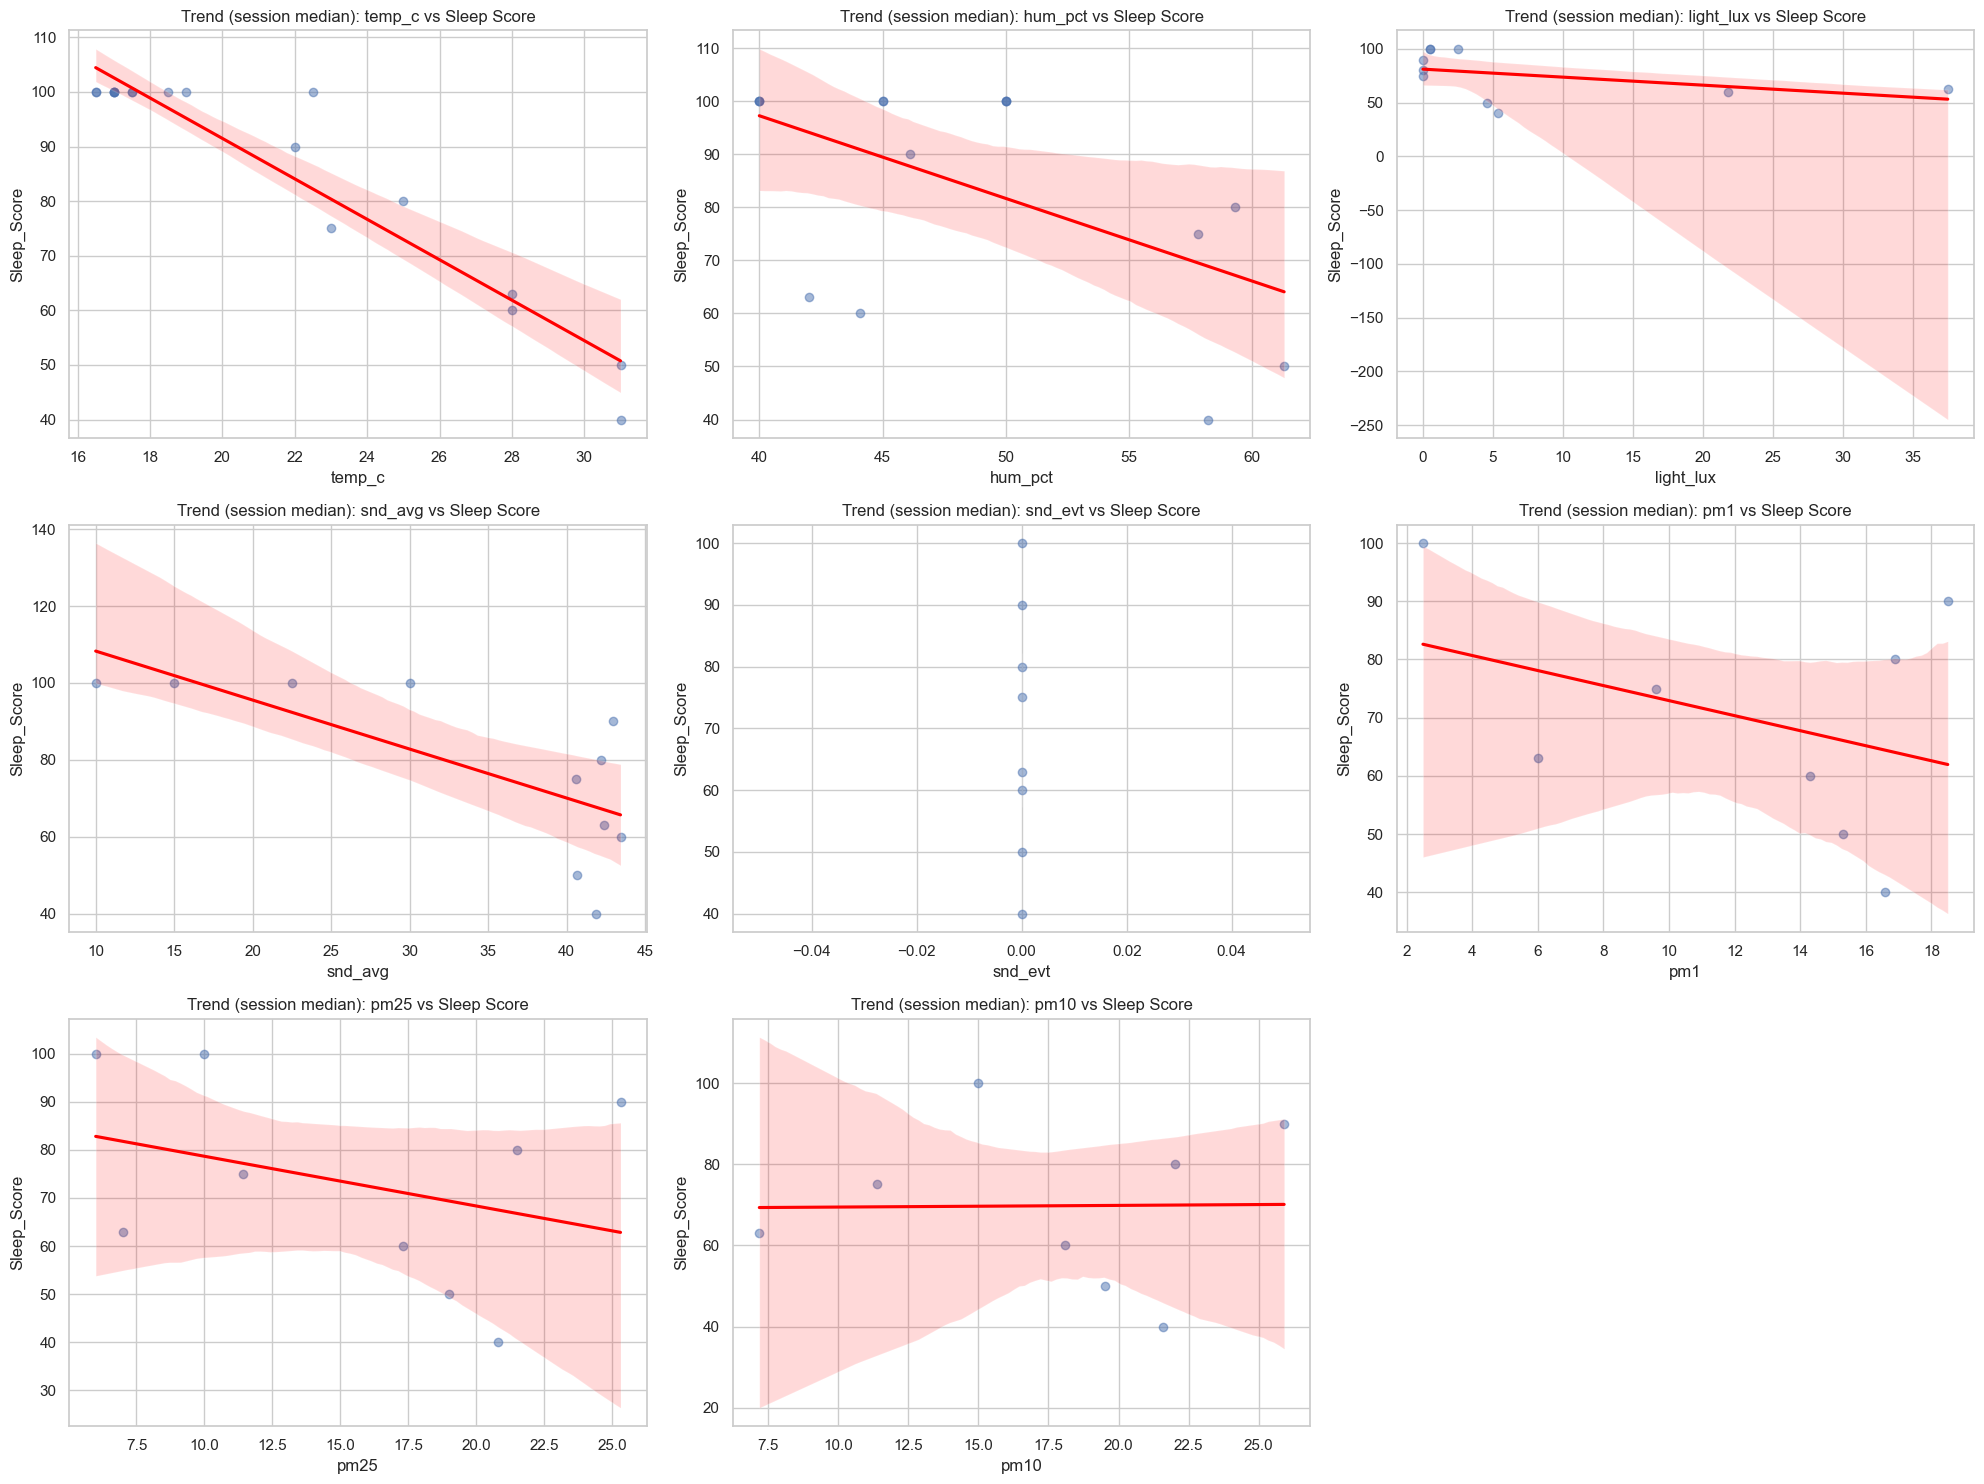

--- Regression on preprocessed session-level features ---
Weights apply after median impute → (log1p+winsor where set) → RobustScaler. Sign still indicates direction on the original factor (log1p is monotone for non‑negative inputs).


,Factor,Impact (transformed space)
5,pm1,1.129091e-01
4,snd_evt,6.217249e-15
3,snd_avg,-1.422315e-01
7,pm10,-1.427881e-01
6,pm25,-2.558073e-01
2,hum_pct,-9.768849e-01
1,light_lux,-6.876665e+00
0,temp_c,-6.005613e+01


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# all_factors, df_session, and modeling_pipeline are defined in the preprocessing cell above.

# --- 1. DETAILED TREND ANALYSIS (session-level; matches regression design matrix) ---
plt.figure(figsize=(20, 15))
for i, col in enumerate(all_factors, 1):
    plt.subplot(3, 3, i)
    sns.regplot(data=df_session, x=col, y='Sleep_Score', scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
    plt.title(f'Trend (session median): {col} vs Sleep Score')
plt.tight_layout()
plt.show()

# --- 2. COEFFICIENTS (after imputation, winsor/log1p, RobustScaler — interpret direction, not raw magnitude) ---
reg = modeling_pipeline.named_steps['reg']
prep = modeling_pipeline.named_steps['prep']
feat_names = prep.get_feature_names_out()
coef_by_factor = dict(zip(feat_names, reg.coef_))

coeffs = pd.DataFrame({'Factor': feat_names, 'Impact (transformed space)': reg.coef_})
print("--- Regression on preprocessed session-level features ---")
print(
    "Weights apply after median impute → (log1p+winsor where set) → RobustScaler. "
    "Sign still indicates direction on the original factor (log1p is monotone for non‑negative inputs)."
)
display(coeffs.sort_values(by='Impact (transformed space)', ascending=False))

# --- 3. PREDICTION & OPTIMIZATION (must use the same Pipeline as training) ---
def optimize_sleep(current_values,
                   model_name='Linear Regression',
                   scenario='No Augmentation'):
    """
    Predict Sleep Score and show coefficient-based directional recommendations.

    Parameters
    ----------
    current_values : dict   {feature: raw_sensor_value}
    model_name     : str    key from `candidates`  e.g. 'Gradient Boosting'
    scenario       : str    key from `scenarios`   e.g. 'KNN Synth ×5'
    """
    key = (scenario, model_name)
    if key not in fitted_pipes:
        avail_s = list({s for s, _ in fitted_pipes})
        avail_m = list({m for _, m in fitted_pipes})
        raise ValueError(
            f"No fitted pipeline for {key}.\n"
            f"  Available scenarios : {avail_s}\n"
            f"  Available models    : {avail_m}"
        )

    _prep, m = fitted_pipes[key]
    input_df       = pd.DataFrame([current_values], columns=all_factors)
    X_in           = _prep.transform(input_df)
    raw_prediction = m.predict(X_in)[0]
    prediction     = float(np.clip(raw_prediction, 0, 100))

    print(f"\n─── {model_name}  /  {scenario} ───")
    print(f"\n>>> Predicted Sleep Score: {prediction:.2f} <<<")
    if raw_prediction > 100:
        print("(Note: Ideal environment reached — score clipped at 100)")

    print("\nRecommendations from model direction:")

    if hasattr(m, 'coef_'):
        # Linear model: map transformed feature names back to original factors
        feat_out = list(_prep.get_feature_names_out())
        coef_map = dict(zip(feat_out, m.coef_))
        for factor in all_factors:
            weight = coef_map.get(factor, 0.0)
            val    = current_values.get(factor, 0)
            if weight > 0.05:
                print(f"  + [{factor}]: {val}  — POSITIVE  (higher → better score)")
            elif weight < -0.05:
                print(f"  - [{factor}]: {val}  — NEGATIVE  (lower  → better score)")
            else:
                print(f"  ~ [{factor}]: {val}  — NEUTRAL / weak effect")
    else:
        print(f"  ({model_name} is non-linear — coefficients not available.")
        print("   Run optimize_sleep_v2() for SHAP-based recommendations.)")

## Multi-Model Comparison + SHAP Recommendations

### Why go beyond linear regression?

| Issue with plain linear regression | What we do instead |
|---|---|
| **Unstable coefficients** with only ~37 session rows and 8 features | **Ridge / Lasso** shrink or zero-out coefficients via regularization |
| **Linear assumption** — environment effects are not linear (too cold AND too hot both hurt sleep; there's an optimal range) | **Random Forest / Gradient Boosting** capture non-linear and interaction effects |
| **Coefficients ≠ explanation** for complex models | **SHAP values** give direction + magnitude for any model |

### Why SHAP for recommendations?
SHAP (SHapley Additive exPlanations) works the same way regardless of model type:
- For **each prediction**, it tells you exactly which features pushed the score **up** or **down** and **by how many points**
- This means even after switching to Random Forest or Gradient Boosting, you still get the same "↓ lower temp_c" style recommendation
- Direction is tied to **this specific reading**, not just a global pattern — so recommendations are contextual

### Fairness of comparison
All models are evaluated on the **exact same held-out sessions** (`GroupShuffleSplit(random_state=42, test_size=0.35)`) and trained on the same preprocessed features from the `prep` pipeline.


c:\Users\proun\Downloads\archive-889266F7-7168-4BE1-B3B8-274F567DA2D1\Users\supakritaphonmaeklong\Code\proud-da-final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 24 sessions | Test: 14 sessions
Transformed features: ['temp_c', 'light_lux', 'hum_pct', 'snd_avg', 'snd_evt', 'pm1', 'pm25', 'pm10']

─── Model Comparison (held-out sessions, same test set) ───


,Model,MAE,RMSE,R²
0,Gradient Boosting,3.695,7.503,0.765
1,Random Forest,4.398,9.724,0.605
2,Linear Regression,5.028,6.622,0.817
3,Ridge (α=1),6.638,8.532,0.696
4,Lasso (α=0.5),6.728,8.749,0.680
5,Ridge (α=10),8.436,11.102,0.485



Best model by MAE: Gradient Boosting
'Gradient Boosting' refitted on all 38 session rows for deployment.


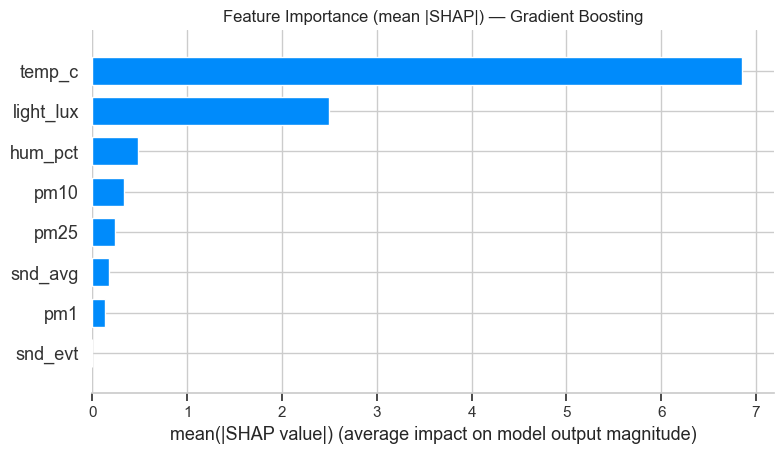

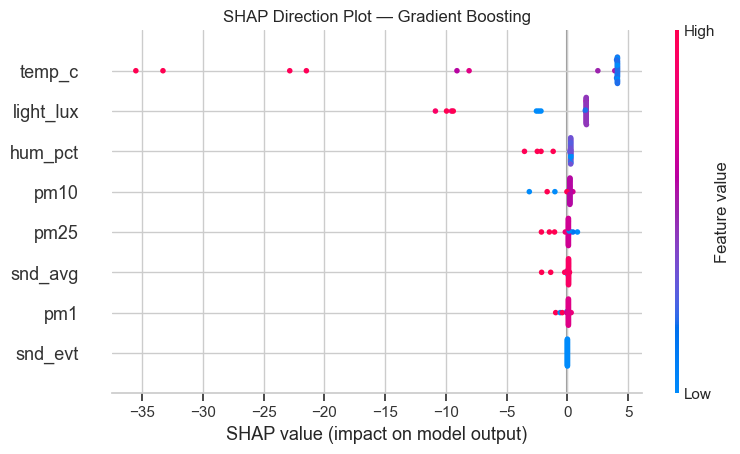

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline

# ── 1. SAME TRAIN / TEST SPLIT ───────────────────────────────────────────────
# Reuse the exact split from the preprocessing cell (same random_state → same sessions)
gss = GroupShuffleSplit(n_splits=1, test_size=0.35, random_state=42)
train_idx, test_idx = next(gss.split(X_sess, y_sess, groups=groups))
X_train, X_test = X_sess.iloc[train_idx], X_sess.iloc[test_idx]
y_train, y_test = y_sess.iloc[train_idx], y_sess.iloc[test_idx]

# Transform using the already-fitted prep (fit on train sessions → no leakage into test)
fitted_prep = modeling_pipeline.named_steps['prep']
feat_names  = list(fitted_prep.get_feature_names_out())
X_train_t   = fitted_prep.transform(X_train)
X_test_t    = fitted_prep.transform(X_test)

print(f"Train: {len(X_train)} sessions | Test: {len(X_test)} sessions")
print(f"Transformed features: {feat_names}\n")

# ── 2. CANDIDATE MODELS ──────────────────────────────────────────────────────
candidates = {
    'Linear Regression': LinearRegression(),
    'Ridge  (α=1)':      Ridge(alpha=1.0),
    'Ridge  (α=10)':     Ridge(alpha=10.0),
    'Lasso  (α=0.5)':    Lasso(alpha=0.5, max_iter=5000),
    'Random Forest':     RandomForestRegressor(
                             n_estimators=300, max_depth=3,
                             min_samples_leaf=2, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(
                             n_estimators=300, max_depth=2,
                             learning_rate=0.05, subsample=0.8,
                             random_state=42),
}

results, fitted_estimators = [], {}
for name, est in candidates.items():
    est.fit(X_train_t, y_train)
    y_hat = est.predict(X_test_t)
    results.append({
        'Model': name,
        'MAE':   round(mean_absolute_error(y_test, y_hat), 3),
        'RMSE':  round(np.sqrt(mean_squared_error(y_test, y_hat)), 3),
        'R²':    round(r2_score(y_test, y_hat), 3),
    })
    fitted_estimators[name] = est

df_model_compare = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
print("─── Model Comparison (held-out sessions, same test set) ───")
display(df_model_compare)

# ── 3. REFIT BEST MODEL ON ALL SESSIONS FOR DEPLOYMENT ───────────────────────
best_name = df_model_compare.iloc[0]['Model']
print(f"\nBest model by MAE: {best_name}")

# Clone prep so the original modeling_pipeline is untouched
best_final_pipe = Pipeline([
    ('prep',  clone(fitted_prep)),
    ('model', clone(fitted_estimators[best_name])),
])
best_final_pipe.fit(X_sess, y_sess)
print(f"'{best_name}' refitted on all {len(X_sess)} session rows for deployment.")

# ── 4. SHAP EXPLANATIONS ─────────────────────────────────────────────────────
fitted_prep_final = best_final_pipe.named_steps['prep']
best_est_final    = best_final_pipe.named_steps['model']
X_all_t = fitted_prep_final.transform(X_sess)

# Pick the right SHAP explainer based on model type
if hasattr(best_est_final, 'estimators_'):        # tree ensemble (RF, GBM)
    explainer_v2 = shap.TreeExplainer(best_est_final)
elif hasattr(best_est_final, 'coef_'):             # linear (LR, Ridge, Lasso)
    explainer_v2 = shap.LinearExplainer(best_est_final, X_all_t)
else:
    bg = shap.kmeans(X_all_t, min(10, len(X_all_t)))
    explainer_v2 = shap.KernelExplainer(best_est_final.predict, bg)

shap_vals_all = np.array(explainer_v2.shap_values(X_all_t))
if shap_vals_all.ndim == 3:        # some explainers wrap in extra dim
    shap_vals_all = shap_vals_all[0]

# Bar chart: global feature importance by mean |SHAP|
shap.summary_plot(shap_vals_all, X_all_t, feature_names=feat_names,
                  plot_type='bar', show=False)
plt.title(f'Feature Importance (mean |SHAP|) — {best_name}')
plt.tight_layout(); plt.show()

# Beeswarm: direction each feature pushes the score
shap.summary_plot(shap_vals_all, X_all_t, feature_names=feat_names, show=False)
plt.title(f'SHAP Direction Plot — {best_name}')
plt.tight_layout(); plt.show()

# ── 5. RECOMMENDATION FUNCTION (SHAP-powered, model-agnostic) ────────────────
_shap_cache = {}   # (scenario, model_name) → shap.Explainer — built lazily


def _get_explainer(scenario, model_name):
    """Return (or build and cache) a SHAP explainer for the given combo."""
    key = (scenario, model_name)
    if key in _shap_cache:
        return _shap_cache[key]

    _prep, m = fitted_pipes[key]
    # Use all training sessions for the background (same as multi-model cell)
    X_all_t = _prep.transform(X_sess)

    if hasattr(m, 'estimators_') or hasattr(m, 'tree_'):      # tree ensembles
        exp = shap.TreeExplainer(m)
    elif hasattr(m, 'coef_'):                                  # linear models
        exp = shap.LinearExplainer(m, X_all_t)
    else:                                                      # fallback
        bg  = shap.kmeans(X_all_t, min(10, len(X_all_t)))
        exp = shap.KernelExplainer(m.predict, bg)

    _shap_cache[key] = exp
    return exp


def optimize_sleep_v2(current_values,
                      model_name='Gradient Boosting',
                      scenario='No Augmentation',
                      threshold=0.05):
    """
    Predict Sleep Score and give SHAP-based directional recommendations
    for any (model, augmentation scenario) combination.

    Parameters
    ----------
    current_values : dict   {feature: raw_sensor_value}
    model_name     : str    key from `candidates`  e.g. 'Gradient Boosting'
    scenario       : str    key from `scenarios`   e.g. 'KNN Synth ×5'
    threshold      : float  minimum |SHAP| to include in output
    """
    key = (scenario, model_name)
    if key not in fitted_pipes:
        avail_s = sorted({s for s, _ in fitted_pipes})
        avail_m = sorted({m for _, m in fitted_pipes})
        raise ValueError(
            f"No fitted pipeline for {key}.\n"
            f"  Available scenarios : {avail_s}\n"
            f"  Available models    : {avail_m}"
        )

    _prep, m   = fitted_pipes[key]
    input_df   = pd.DataFrame([current_values], columns=all_factors)
    X_in       = _prep.transform(input_df)
    raw_score  = m.predict(X_in)[0]
    predicted  = float(np.clip(raw_score, 0, 100))

    explainer  = _get_explainer(scenario, model_name)
    sv         = np.array(explainer.shap_values(X_in)).flatten()
    feat_out   = list(_prep.get_feature_names_out())

    shap_df = pd.DataFrame({
        'Feature':       feat_out,
        'Current Value': [current_values.get(f, np.nan) for f in feat_out],
        'SHAP Impact':   sv,
    }).sort_values('SHAP Impact')

    print(f"\n─── {model_name}  /  {scenario} ───")
    print(f"\n>>> Predicted Sleep Score: {predicted:.2f} / 100 <<<")

    drags = shap_df[shap_df['SHAP Impact'] < -threshold]
    if not drags.empty:
        print("\nFactors HURTING your score — consider reducing:")
        for _, r in drags.iterrows():
            print(f"  ↓  {r['Feature']:12s}  now={r['Current Value']:.2f}   "
                  f"dragging score by {r['SHAP Impact']:+.2f} pts")

    boosts = shap_df[shap_df['SHAP Impact'] > threshold].iloc[::-1]
    if not boosts.empty:
        print("\nFactors HELPING your score — keep or increase:")
        for _, r in boosts.iterrows():
            print(f"  ↑  {r['Feature']:12s}  now={r['Current Value']:.2f}   "
                  f"boosting score by {r['SHAP Impact']:+.2f} pts")

    neutral = shap_df[shap_df['SHAP Impact'].abs() <= threshold]
    if not neutral.empty:
        print(f"\nNeutral / low effect: {', '.join(neutral['Feature'].tolist())}")


## Model Error Analysis

Four complementary visualisations help understand not just *which* model wins, but *how* and *where* each model fails:

1. **Metric comparison** — side-by-side bar chart of MAE / RMSE / R² for all six models
2. **Actual vs Predicted** — scatter plot per model with the perfect-fit diagonal; points coloured by absolute error
3. **Residual distributions** — KDE of (actual − predicted) overlaid for all models; deviation from zero = systematic bias
4. **Per-session residual heatmap** — rows = models, columns = held-out test sessions; cell value = prediction error, so you can see which sessions trip up which models


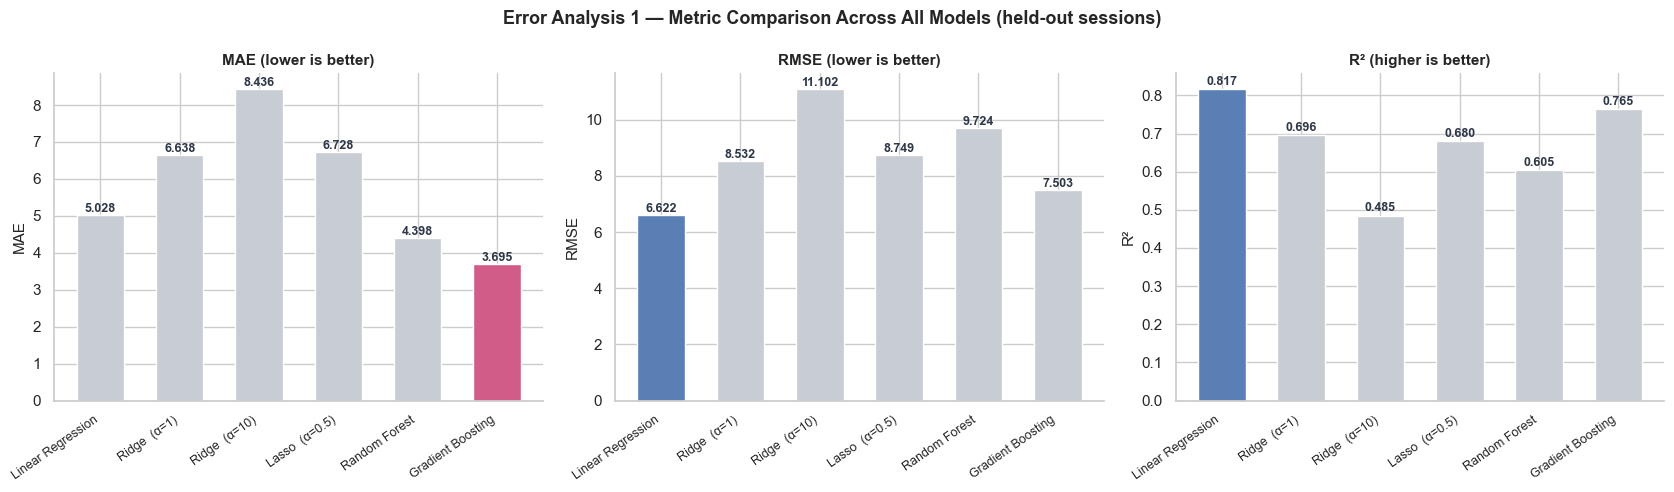

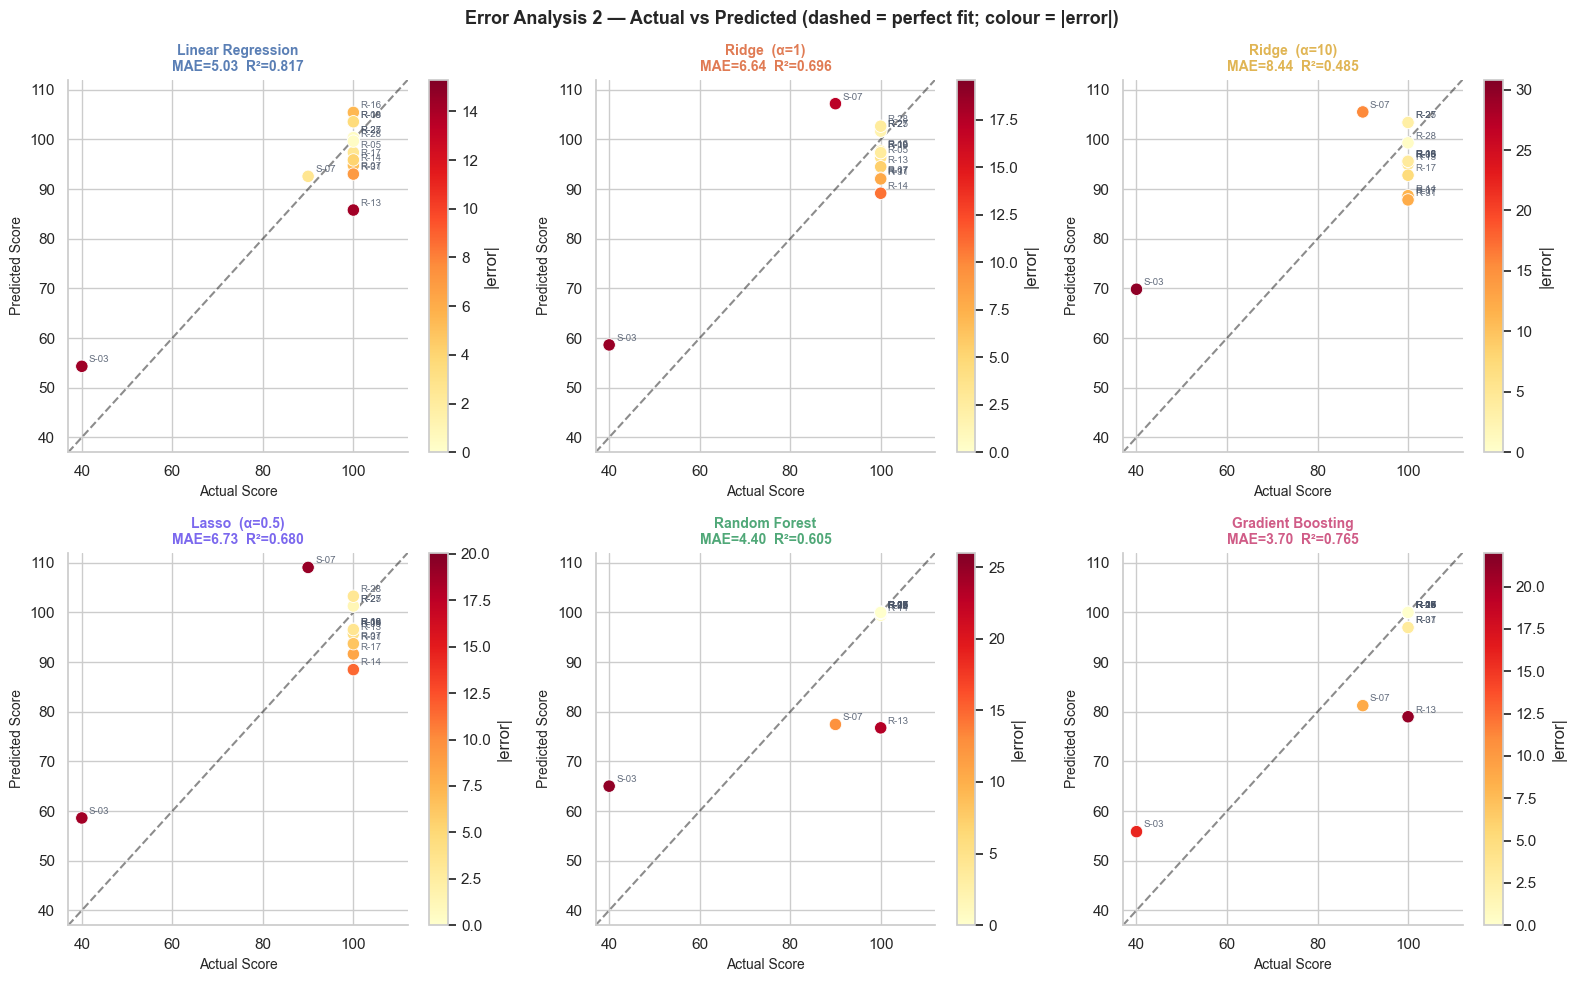

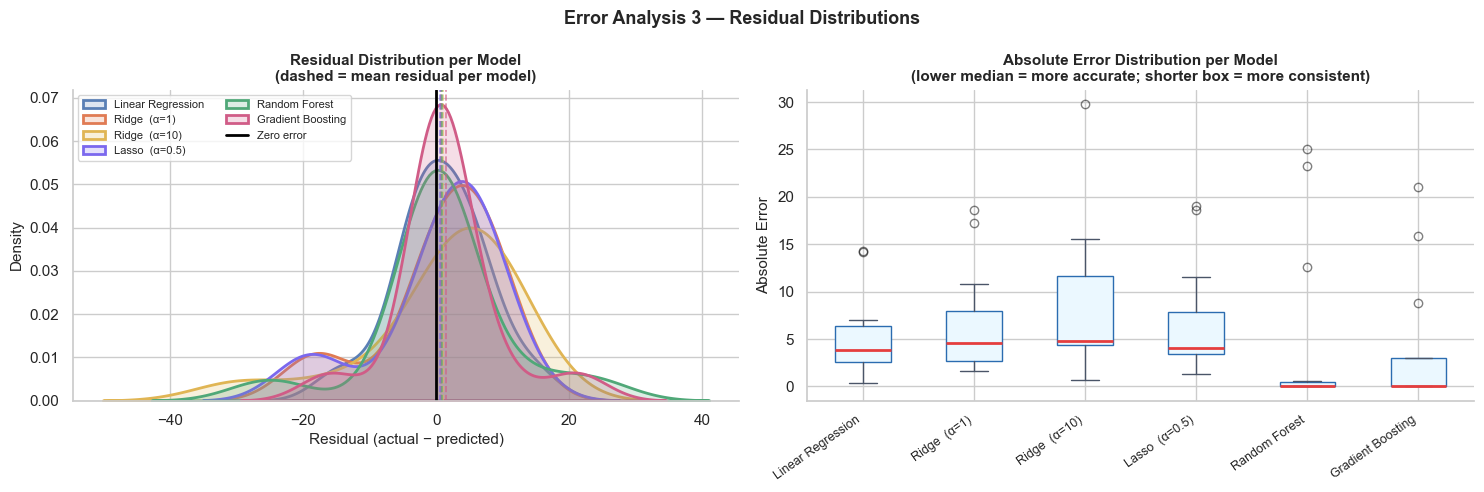

C:\Users\proun\AppData\Local\Temp\ipykernel_5672\2821061894.py:168: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\proun\AppData\Local\Temp\ipykernel_5672\2821061894.py:168: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\proun\Downloads\archive-889266F7-7168-4BE1-B3B8-274F567DA2D1\Users\supakritaphonmaeklong\Code\proud-da-final\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\proun\Downloads\archive-889266F7-7168-4BE1-B3B8-274F567DA2D1\Users\supakritaphonmaeklong\Code\proud-da-final\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


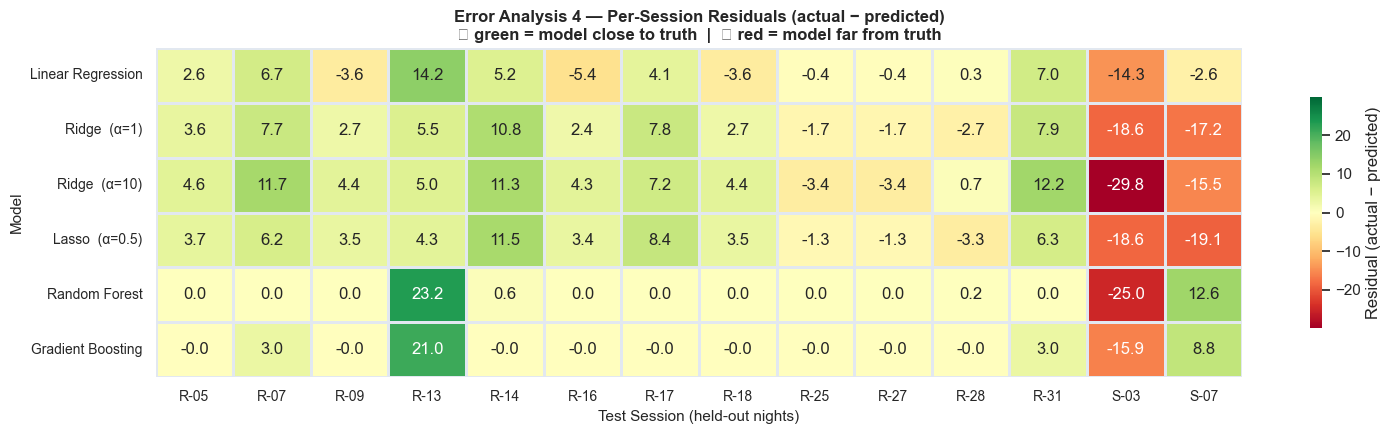


─── Bias & Error Spread Summary ───


,Model,Mean Residual,Std Residual,Max Overpredict,Max Underpredict,% Within ±10 pts
0,Linear Regression,0.716,6.583,14.31,14.22,86%
5,Gradient Boosting,1.427,7.366,15.85,21.01,86%
1,Ridge (α=1),0.663,8.507,18.62,10.83,79%
3,Lasso (α=0.5),0.508,8.734,19.07,11.52,79%
4,Random Forest,0.824,9.689,25.01,23.24,79%
2,Ridge (α=10),0.978,11.059,29.83,12.18,64%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid")

# ── Re-collect predictions from every model on the same test set ─────────────
model_names  = list(fitted_estimators.keys())
predictions  = {name: est.predict(X_test_t) for name, est in fitted_estimators.items()}
residuals    = {name: y_test.values - predictions[name] for name in model_names}
test_session_ids = groups.iloc[test_idx].values   # Session IDs for axis labels

PALETTE = {
    'Linear Regression': '#5a7fb5',
    'Ridge  (α=1)':      '#e07b54',
    'Ridge  (α=10)':     '#e0b554',
    'Lasso  (α=0.5)':    '#7b68ee',
    'Random Forest':     '#50a878',
    'Gradient Boosting': '#d05c87',
}
COLORS = [PALETTE[n] for n in model_names]

# ── 1. METRIC COMPARISON BAR CHART ──────────────────────────────────────────
metrics = ['MAE', 'RMSE', 'R²']
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, metric in zip(axes, metrics):
    vals    = [df_model_compare.set_index('Model').loc[n, metric] for n in model_names]
    # Highlight best model
    best_val   = min(vals) if metric != 'R²' else max(vals)
    bar_colors = [PALETTE[n] if v == best_val else '#c8cdd4' for n, v in zip(model_names, vals)]
    bars = ax.bar(range(len(model_names)), vals, color=bar_colors, width=0.6, edgecolor='white')
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric} (lower is better)' if metric != 'R²' else 'R² (higher is better)',
                 fontweight='bold', fontsize=11)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold',
                color='#2d3748')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Error Analysis 1 — Metric Comparison Across All Models (held-out sessions)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. ACTUAL VS PREDICTED SCATTER (one subplot per model) ───────────────────
n_models = len(model_names)
ncols    = 3
nrows    = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

score_lo = min(y_test.min(), min(p.min() for p in predictions.values())) - 3
score_hi = max(y_test.max(), max(p.max() for p in predictions.values())) + 3

for i, name in enumerate(model_names):
    ax   = axes[i]
    y_p  = predictions[name]
    errs = np.abs(y_test.values - y_p)

    sc = ax.scatter(y_test, y_p, c=errs, cmap='YlOrRd', vmin=0, vmax=errs.max() + 1,
                    s=80, zorder=3, edgecolors='white', linewidth=0.6)
    plt.colorbar(sc, ax=ax, label='|error|')

    # Annotate each point with session ID
    for sid, yt, yp in zip(test_session_ids, y_test.values, y_p):
        ax.annotate(sid, (yt, yp), textcoords='offset points', xytext=(5, 3),
                    fontsize=7, color='#4a5568', alpha=0.85)

    # Perfect-fit diagonal
    ax.plot([score_lo, score_hi], [score_lo, score_hi], 'k--', linewidth=1.5,
            alpha=0.5, label='Perfect fit')
    ax.set_xlim(score_lo, score_hi)
    ax.set_ylim(score_lo, score_hi)
    ax.set_xlabel('Actual Score', fontsize=10)
    ax.set_ylabel('Predicted Score', fontsize=10)

    mae_i = mean_absolute_error(y_test, y_p)
    r2_i  = r2_score(y_test, y_p)
    ax.set_title(f'{name}\nMAE={mae_i:.2f}  R²={r2_i:.3f}',
                 fontweight='bold', fontsize=10,
                 color=PALETTE.get(name, '#333'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Error Analysis 2 — Actual vs Predicted (dashed = perfect fit; colour = |error|)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. RESIDUAL DISTRIBUTIONS ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: overlaid KDE of residuals
ax = axes[0]
for name in model_names:
    res = residuals[name]
    if len(np.unique(res)) > 1:
        sns.kdeplot(res, ax=ax, fill=True, alpha=0.20,
                    color=PALETTE[name], linewidth=2.0, label=name)
    ax.axvline(np.mean(res), color=PALETTE[name], linestyle='--', linewidth=1.2, alpha=0.7)

ax.axvline(0, color='black', linewidth=2.0, label='Zero error')
ax.set_xlabel('Residual (actual − predicted)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Residual Distribution per Model\n(dashed = mean residual per model)',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=8, ncol=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: box-plot of absolute residuals (easier to rank spread)
ax2   = axes[1]
res_df = pd.DataFrame({n: np.abs(residuals[n]) for n in model_names})
res_df.boxplot(ax=ax2, patch_artist=True,
               boxprops=dict(facecolor='#ebf8ff', color='#2b6cb0'),
               medianprops=dict(color='#e53e3e', linewidth=2),
               whiskerprops=dict(color='#4a5568'),
               capprops=dict(color='#4a5568'),
               flierprops=dict(marker='o', color='#e53e3e', alpha=0.5))
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax2.set_ylabel('Absolute Error', fontsize=11)
ax2.set_title('Absolute Error Distribution per Model\n(lower median = more accurate; shorter box = more consistent)',
              fontweight='bold', fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Error Analysis 3 — Residual Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. PER-SESSION RESIDUAL HEATMAP ─────────────────────────────────────────
res_matrix = pd.DataFrame(
    {name: residuals[name] for name in model_names},
    index=test_session_ids,
).T   # rows = models, cols = test sessions

fig, ax = plt.subplots(figsize=(max(10, len(test_session_ids) * 1.1), 4.5))
abs_max  = res_matrix.abs().values.max()
sns.heatmap(
    res_matrix, ax=ax,
    cmap='RdYlGn', center=0, vmin=-abs_max, vmax=abs_max,
    annot=True, fmt='.1f',
    linewidths=0.8, linecolor='#e2e8f0',
    cbar_kws={'label': 'Residual (actual − predicted)', 'shrink': 0.7},
)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)
ax.set_xlabel('Test Session (held-out nights)', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
ax.set_title(
    'Error Analysis 4 — Per-Session Residuals (actual − predicted)\n'
    '🟢 green = model close to truth  |  🔴 red = model far from truth',
    fontweight='bold', fontsize=12,
)
plt.tight_layout()
plt.show()

# ── 5. BIAS SUMMARY TABLE ────────────────────────────────────────────────────
bias_rows = []
for name in model_names:
    res  = residuals[name]
    yhat = predictions[name]
    bias_rows.append({
        'Model':          name,
        'Mean Residual':  round(res.mean(), 3),      # positive = underpredicts
        'Std Residual':   round(res.std(),  3),
        'Max Overpredict':  round((-res).clip(min=0).max(), 2),
        'Max Underpredict': round(res.clip(min=0).max(),    2),
        '% Within ±10 pts': f"{(np.abs(res) <= 10).mean()*100:.0f}%",
    })

print('\n─── Bias & Error Spread Summary ───')
display(pd.DataFrame(bias_rows).sort_values('Std Residual'))


## SHAP Analysis — All Models

Two sets of SHAP plots are generated for **every** model so you can compare how each one weights the environmental factors:

- **Feature Importance (bar chart)** — mean absolute SHAP value per feature across all sessions. A longer bar means that feature had a larger average influence on predictions, regardless of direction.
- **Direction plot (beeswarm)** — each dot is one session. Position left of zero = that feature *pulled the score down* for that session; right of zero = it *pushed the score up*. Colour shows the raw feature value (red = high, blue = low), so you can see whether high temperature hurts or helps.

Comparing the same feature across all six models reveals where models agree (robust signal) and where they disagree (model-dependent interpretation).


Building SHAP explainers for all models …
  ✓ Linear Regression
  ✓ Ridge  (α=1)
  ✓ Ridge  (α=10)
  ✓ Lasso  (α=0.5)
  ✓ Random Forest
  ✓ Gradient Boosting

All SHAP values computed.



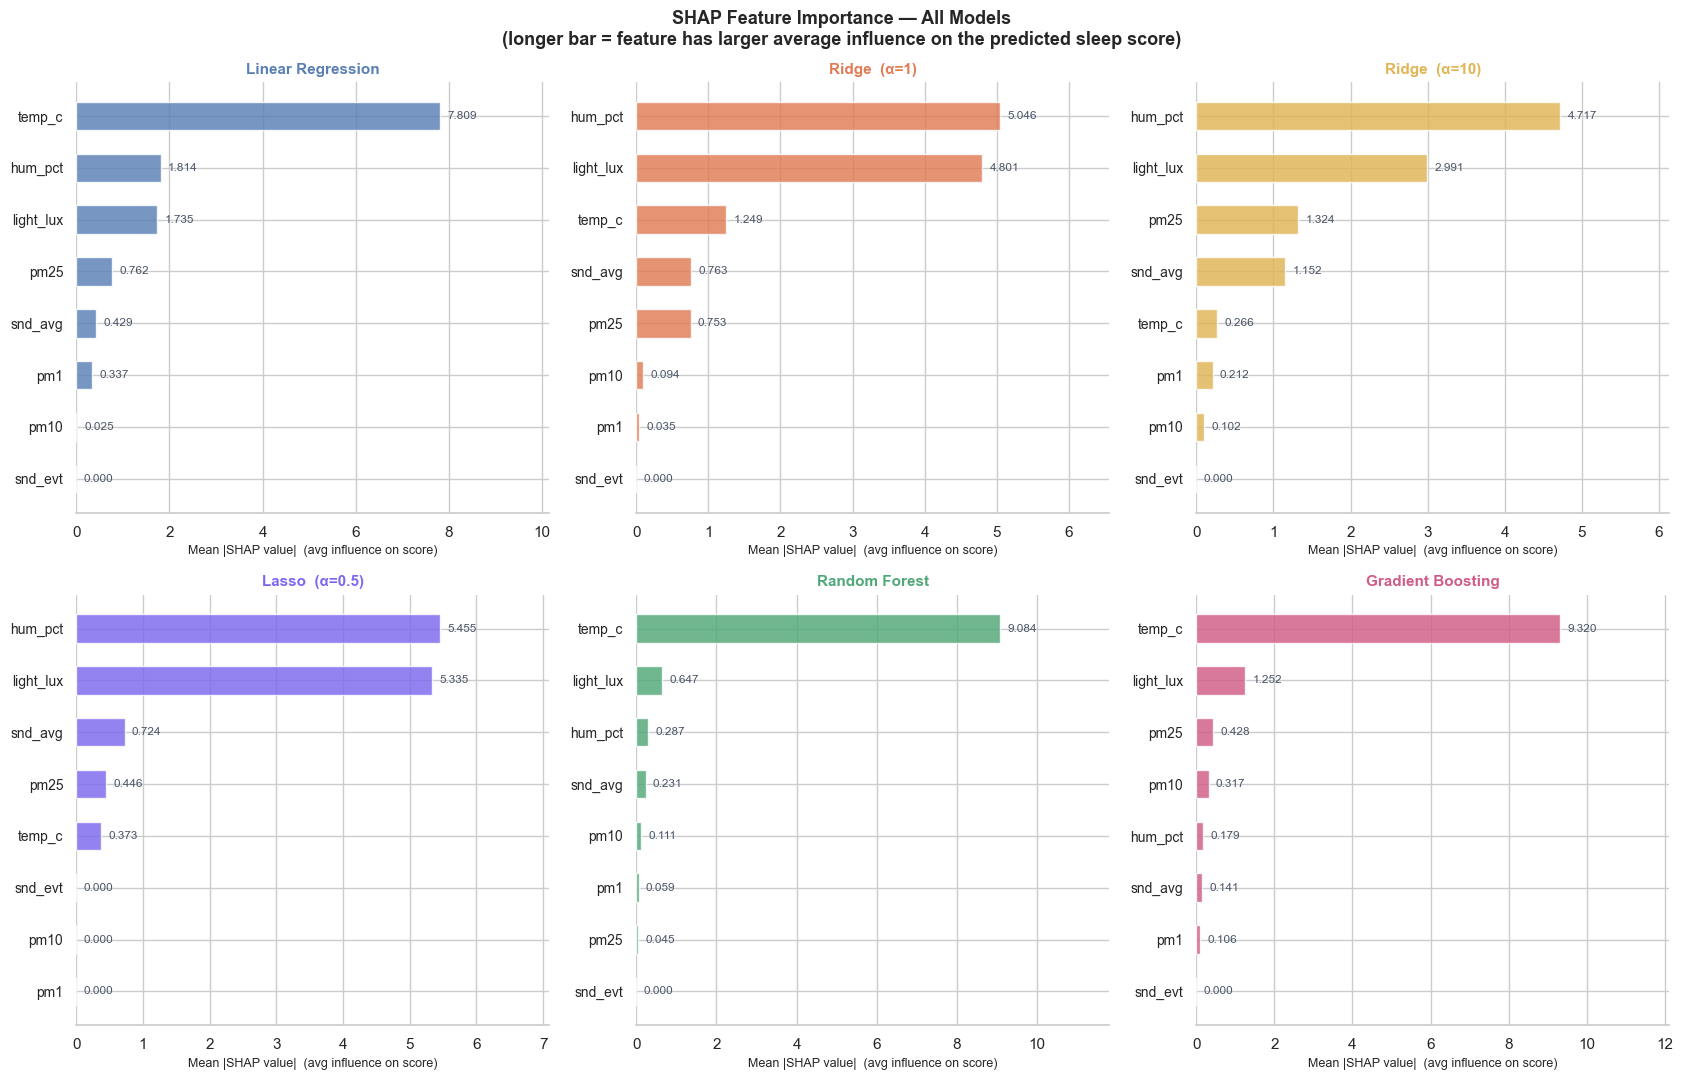

─── SHAP Direction Plots (beeswarm) — per model ───



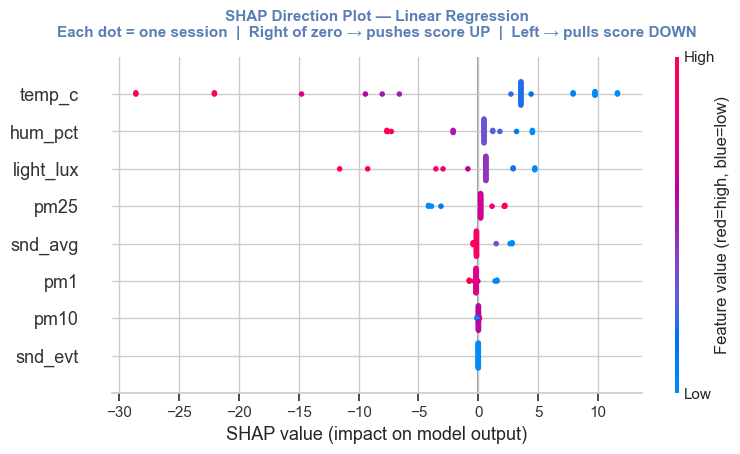

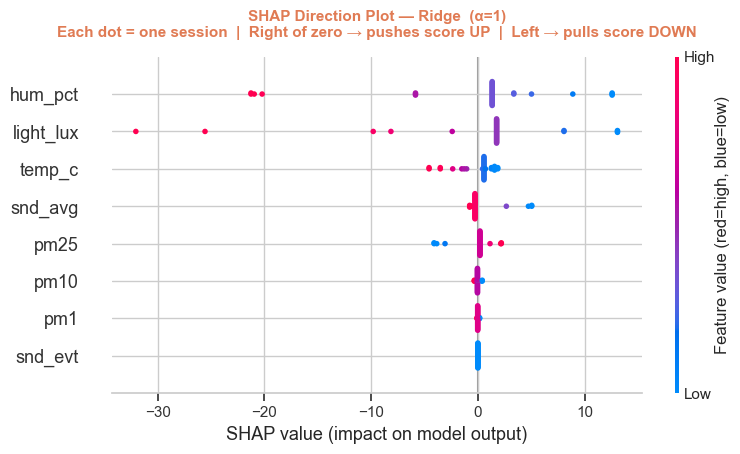

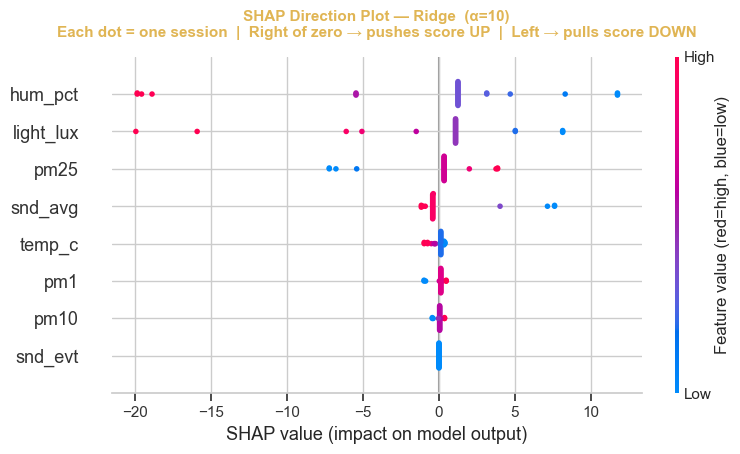

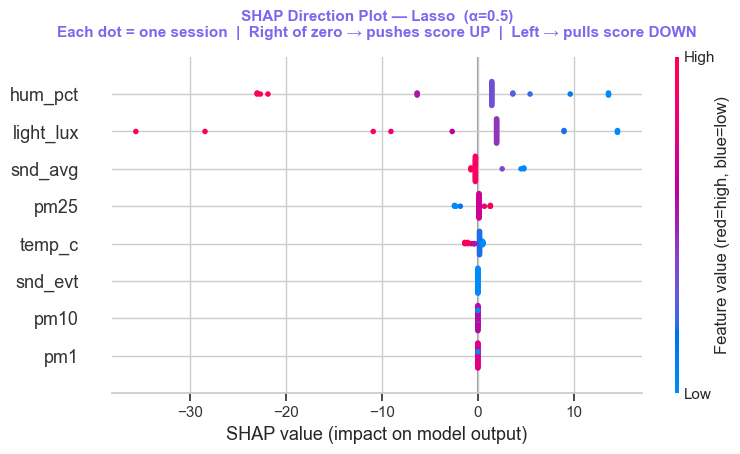

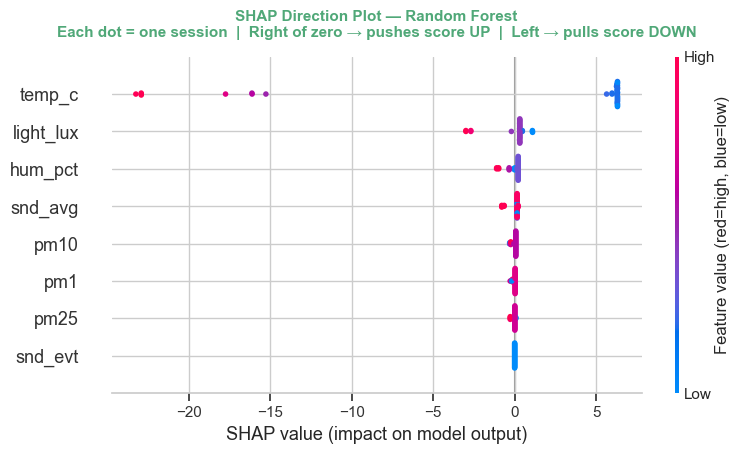

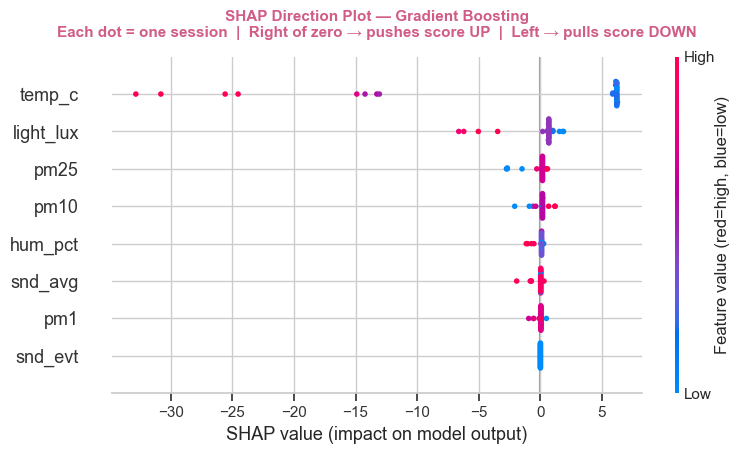

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

sns.set_theme(style="whitegrid")

# ── Same colour identity as the error analysis section ───────────────────────
PALETTE = {
    'Linear Regression': '#5a7fb5',
    'Ridge  (α=1)':      '#e07b54',
    'Ridge  (α=10)':     '#e0b554',
    'Lasso  (α=0.5)':    '#7b68ee',
    'Random Forest':     '#50a878',
    'Gradient Boosting': '#d05c87',
}

# Transform ALL session rows with the training-fitted prep (consistent with model training)
X_all_for_shap = fitted_prep.transform(X_sess)
model_names    = list(fitted_estimators.keys())

# ── Compute SHAP values for every model ──────────────────────────────────────
print("Building SHAP explainers for all models …")
shap_values_all = {}
for name, est in fitted_estimators.items():
    if hasattr(est, 'estimators_'):             # RF / GBM
        exp = shap.TreeExplainer(est)
    elif hasattr(est, 'coef_'):                 # Linear / Ridge / Lasso
        exp = shap.LinearExplainer(est, X_train_t)
    else:
        bg  = shap.kmeans(X_train_t, min(10, len(X_train_t)))
        exp = shap.KernelExplainer(est.predict, bg)

    sv = np.array(exp.shap_values(X_all_for_shap))
    if sv.ndim == 3:
        sv = sv[0]                              # strip extra dim some explainers add
    shap_values_all[name] = sv
    print(f"  ✓ {name}")

print("\nAll SHAP values computed.\n")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — SHAP Feature Importance (mean |SHAP|) for ALL models in one grid
# ─────────────────────────────────────────────────────────────────────────────
ncols = 3
nrows = (len(model_names) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(17, 5.5 * nrows))
axes = axes.flatten()

for i, name in enumerate(model_names):
    ax        = axes[i]
    sv        = shap_values_all[name]
    mean_abs  = np.abs(sv).mean(axis=0)          # shape: (n_features,)
    order     = np.argsort(mean_abs)             # ascending → least important first
    sorted_v  = mean_abs[order]
    sorted_l  = [feat_names[j] for j in order]
    color     = PALETTE.get(name, '#5a7fb5')

    bars = ax.barh(sorted_l, sorted_v, color=color, alpha=0.82,
                   height=0.55, edgecolor='white')
    for bar, val in zip(bars, sorted_v):
        ax.text(bar.get_width() + sorted_v.max() * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=8.5, color='#4a5568')

    ax.set_title(name, fontweight='bold', fontsize=11, color=color)
    ax.set_xlabel('Mean |SHAP value|  (avg influence on score)', fontsize=9)
    ax.set_xlim(0, sorted_v.max() * 1.30)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', labelsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'SHAP Feature Importance — All Models\n'
    '(longer bar = feature has larger average influence on the predicted sleep score)',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — SHAP Direction Plots (beeswarm) — one figure per model
# ─────────────────────────────────────────────────────────────────────────────
print("─── SHAP Direction Plots (beeswarm) — per model ───\n")
for name in model_names:
    sv    = shap_values_all[name]
    color = PALETTE.get(name, '#5a7fb5')

    plt.figure(figsize=(10, 5))
    shap.summary_plot(
        sv, X_all_for_shap,
        feature_names=feat_names,
        plot_type='dot',
        show=False,
        max_display=len(feat_names),
        color_bar_label='Feature value (red=high, blue=low)',
    )
    plt.title(
        f'SHAP Direction Plot — {name}\n'
        'Each dot = one session  |  Right of zero → pushes score UP  |  Left → pulls score DOWN',
        fontweight='bold', fontsize=11, pad=14,
        color=color,
    )
    plt.tight_layout()
    plt.show()


## Training-Data Synthesis

### Why we need synthesis
The session table has ~37 rows total, of which a subset are real collected nights.  
After `GroupShuffleSplit` roughly **25–28 sessions** go to training — far too few for tree ensembles to generalise well and barely enough for linear models.

### Techniques chosen

| Technique | Paper / Origin | Mechanism |
|---|---|---|
| **SMOTER** | Torgo et al., 2013 — *SMOTE for Regression* | For each synthetic point, pick a random base sample **i**, find its **k** nearest neighbours, pick one neighbour **j**, then interpolate: `x' = xᵢ + U(0,1)·(xⱼ − xᵢ)`, `y' = yᵢ + U(0,1)·(yⱼ − yᵢ)` (same λ for X and y). Stays on the line segment between real sessions — **no extrapolation**. |
| **KNN Regression Synthesis** | Standard KNN-based generative augmentation | Generate `x'` as a **convex combination of a seed session and its k nearest neighbours** (Dirichlet weights). Assign `y'` independently via a **distance-weighted KNN regressor** trained on real data — decouples geometry from label assignment and uses the full local neighbourhood rather than a single paired point. |

### Key difference between the two
SMOTER pairs **one** neighbour per synthetic sample and carries its y by direct interpolation (y is completely tied to the pair).  
KNN synthesis uses **all k neighbours** to shape the new point and assigns y through a separate regression — it can produce a y that is consistent with the *entire local region*, not just one edge.

### Evaluation protocol
- Synthesis is applied **only to training sessions** — the test set remains 100 % real nights.
- Both methods are tested at **×3 and ×5** augmentation factors.
- Each combination is evaluated against every model from the multi-model comparison, on the **same fixed test split**.


Training sessions : 24
Test sessions     : 14


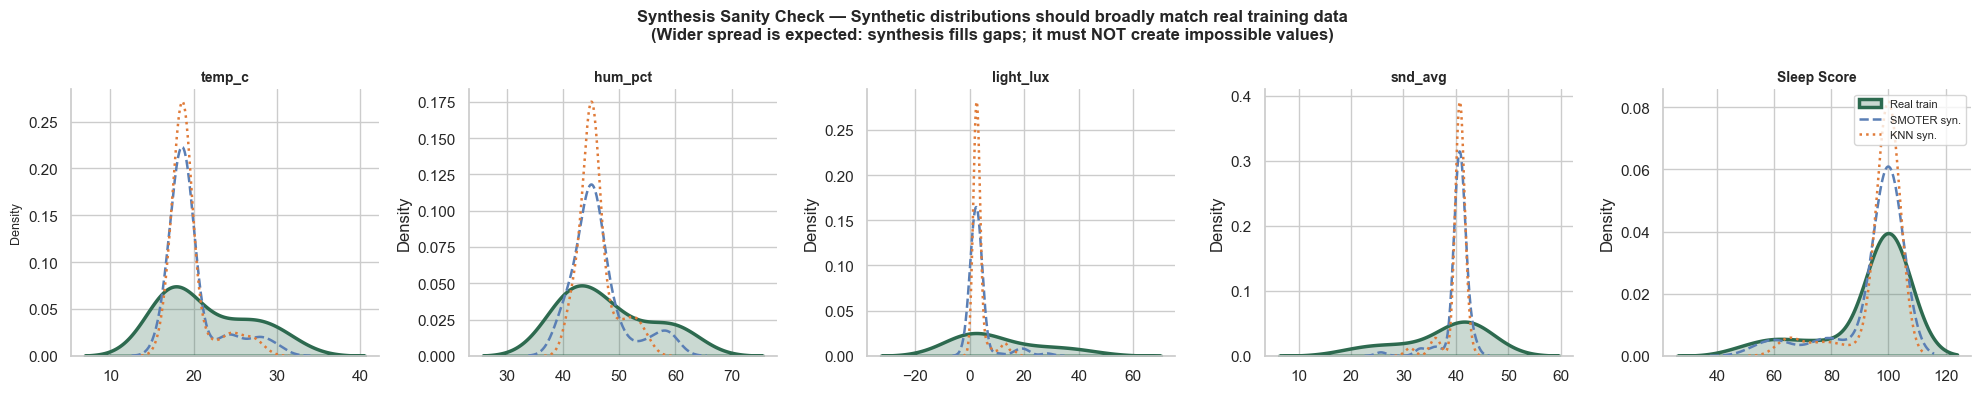


Augmentation sizes:
  No Augmentation     : 24 real  +    0 synthetic  = 24 total
  SMOTER ×3           : 24 real  +   72 synthetic  = 96 total
  SMOTER ×5           : 24 real  +  120 synthetic  = 144 total
  KNN Synth ×3        : 24 real  +   72 synthetic  = 96 total
  KNN Synth ×5        : 24 real  +  120 synthetic  = 144 total


c:\Users\proun\Downloads\archive-889266F7-7168-4BE1-B3B8-274F567DA2D1\Users\supakritaphonmaeklong\Code\proud-da-final\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2660469001665947e-31.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\proun\Downloads\archive-889266F7-7168-4BE1-B3B8-274F567DA2D1\Users\supakritaphonmaeklong\Code\proud-da-final\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2660469001665947e-30.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\proun\Downloads\archive-889266F7-7168-4BE1-B3B8-274F567DA2D1\Users\supakritaphonmaeklong\Code\proud-da-final\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features 

Saved 30 fitted pipelines: 5 scenarios × 6 models

── MAE on real test sessions (lower = better) ──
                   No Augmentation  SMOTER ×3  SMOTER ×5  KNN Synth ×3  KNN Synth ×5
Linear Regression             7.09       5.87       5.53          5.21          5.63
Ridge  (α=1)                  6.18       7.54       5.48          5.01          6.34
Ridge  (α=10)                 5.48       8.06       5.24          4.71          6.46
Lasso  (α=0.5)                5.38       8.10       5.05          4.99          6.34
Random Forest                 4.40       4.01       2.44          2.81          2.16
Gradient Boosting             3.63       3.50       2.54          2.20          2.59


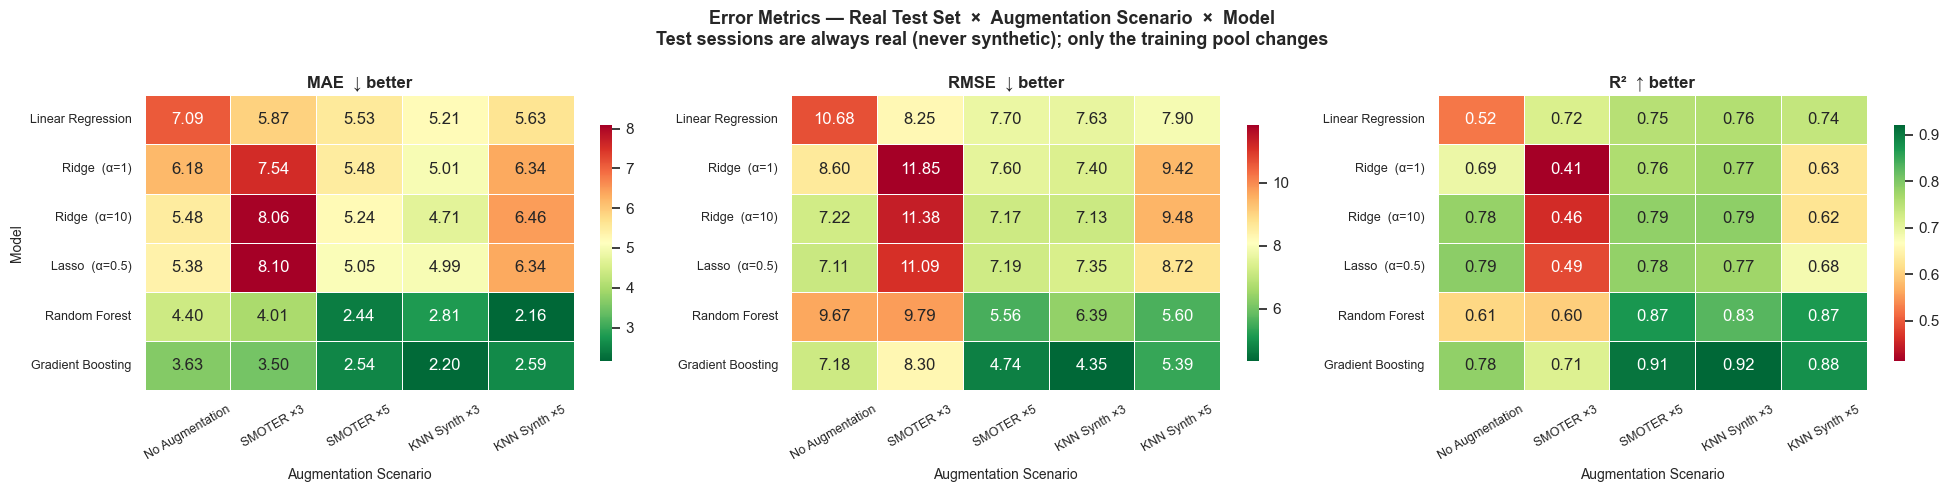

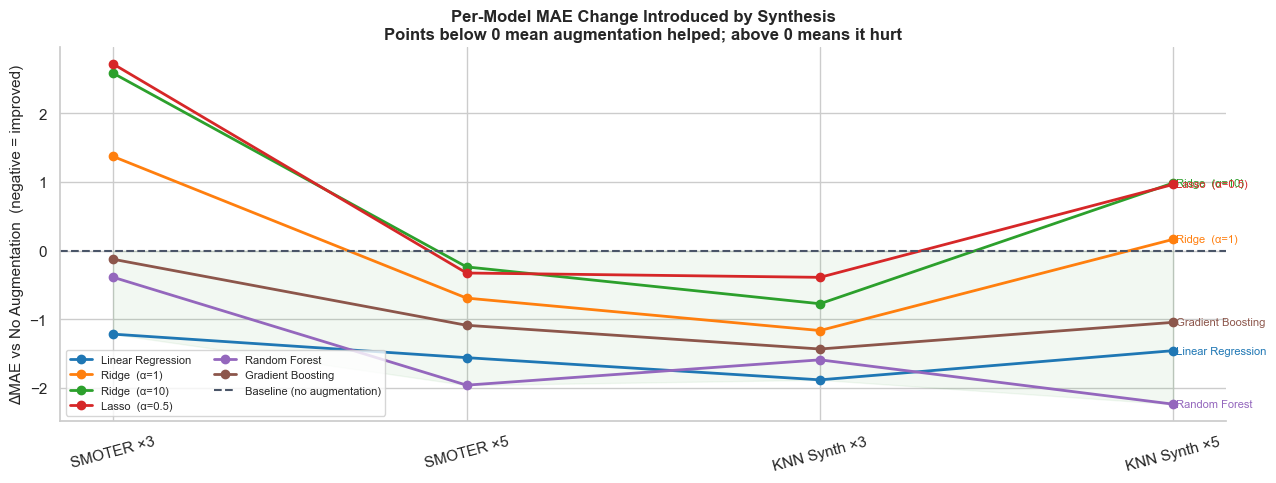


── Best augmentation scenario per model ──
            Model  Baseline MAE Best Scenario  Best MAE  Δ MAE Improved?
    Random Forest         4.400  KNN Synth ×5     2.164 -2.236         ✓
Gradient Boosting         3.631  KNN Synth ×3     2.198 -1.433         ✓
    Ridge  (α=10)         5.480  KNN Synth ×3     4.706 -0.774         ✓
   Lasso  (α=0.5)         5.382  KNN Synth ×3     4.992 -0.390         ✓
     Ridge  (α=1)         6.176  KNN Synth ×3     5.012 -1.164         ✓
Linear Regression         7.090  KNN Synth ×3     5.209 -1.882         ✓


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.base import clone
from sklearn.neighbors import NearestNeighbors, KNeighborsRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')

# ── Raw train / test slices in the ORIGINAL feature space ──────────────────
X_train_raw = X_sess.iloc[train_idx].reset_index(drop=True)
y_train_raw = y_sess.iloc[train_idx].reset_index(drop=True)
X_test_raw  = X_sess.iloc[test_idx].reset_index(drop=True)
y_test_raw  = y_sess.iloc[test_idx].reset_index(drop=True)

print(f"Training sessions : {len(X_train_raw)}")
print(f"Test sessions     : {len(X_test_raw)}")


# ══════════════════════════════════════════════════════════════════════════════
# SYNTHESIS FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def _prep_X(X_df):
    """Median-impute + return numpy array. Internal helper."""
    return SimpleImputer(strategy='median').fit_transform(
        X_df.values.astype(float)
    )


def synth_smoter(X_df, y_s, n_synth, k_neighbors=5, seed=42):
    """
    SMOTER — Torgo et al. 2013 (SMOTE for Regression).

    Algorithm:
      1. Pick a random base sample i.
      2. Find k nearest neighbours of i (in RobustScaled space).
      3. Pick one neighbour j uniformly at random.
      4. Draw lambda ~ Uniform(0, 1).
      5. x' = x_i + lambda * (x_j - x_i)
         y' = y_i + lambda * (y_j - y_i)   ← same lambda keeps X–y consistent.

    Synthetic points lie strictly on line segments between real sessions
    (convex hull guarantee, no extrapolation).
    """
    rng   = np.random.default_rng(seed)
    X_imp = _prep_X(X_df)
    y     = y_s.values.astype(float)
    n, k  = len(X_imp), min(k_neighbors, len(X_imp) - 1)

    X_sc       = RobustScaler().fit_transform(X_imp)
    _, nbrs    = NearestNeighbors(n_neighbors=k + 1).fit(X_sc).kneighbors(X_sc)

    i_idx  = rng.integers(0, n,     size=n_synth)
    j_col  = rng.integers(1, k + 1, size=n_synth)   # skip col-0 (self)
    j_idx  = nbrs[i_idx, j_col]
    lam    = rng.uniform(0, 1, size=n_synth)         # Uniform — the SMOTER spec

    X_syn = X_imp[i_idx] + lam[:, None] * (X_imp[j_idx] - X_imp[i_idx])
    y_syn = y[i_idx]     + lam           * (y[j_idx]     - y[i_idx])

    return (
        pd.DataFrame(X_syn, columns=X_df.columns),
        pd.Series(y_syn, name=y_s.name),
    )


def synth_knn(X_df, y_s, n_synth, k_neighbors=5, seed=42):
    """
    KNN Regression Synthesis.

    Algorithm (decouples geometry from label assignment):
      1. For each synthetic point, pick a seed session i.
      2. Generate x' as a Dirichlet-weighted convex combination of i and its
         k nearest neighbours — uses the *full* local neighbourhood, not just
         one paired point.
      3. Assign y' via a distance-weighted KNN regressor trained on real data.
         The predicted y reflects the *entire* local region rather than a
         single interpolated pair.

    Key difference from SMOTER: y is not tied to a specific pair edge;
    instead it is estimated from the local distribution of real labels.
    """
    rng   = np.random.default_rng(seed)
    X_imp = _prep_X(X_df)
    y     = y_s.values.astype(float)
    n, k  = len(X_imp), min(k_neighbors, len(X_imp) - 1)

    scaler     = RobustScaler().fit(X_imp)
    X_sc       = scaler.transform(X_imp)
    _, nbrs    = NearestNeighbors(n_neighbors=k + 1).fit(X_sc).kneighbors(X_sc)

    # KNN regressor on real data — used to assign y for every synthetic point
    knn_reg = KNeighborsRegressor(
        n_neighbors=k, weights='distance', metric='euclidean'
    ).fit(X_sc, y)

    # Build synthetic X as convex combination of seed + k neighbours
    i_idx = rng.integers(0, n, size=n_synth)
    X_syn = np.zeros((n_synth, X_imp.shape[1]))
    for t in range(n_synth):
        base_pts = np.vstack([
            X_imp[i_idx[t]],
            X_imp[nbrs[i_idx[t], 1:k + 1]],   # k neighbours
        ])                                      # shape (k+1, d)
        weights  = rng.dirichlet(np.ones(k + 1))
        X_syn[t] = weights @ base_pts

    # Assign y via KNN regression in scaled space
    y_syn = knn_reg.predict(scaler.transform(X_syn))
    y_syn = np.clip(y_syn, y.min(), y.max())

    return (
        pd.DataFrame(X_syn, columns=X_df.columns),
        pd.Series(y_syn, name=y_s.name),
    )


def augment(X_real, y_real, synth_fn, n_synth, **kw):
    """Combine real training data with synthetic samples."""
    X_syn, y_syn = synth_fn(X_real, y_real, n_synth, **kw)
    X_aug = pd.concat([X_real, X_syn], ignore_index=True)
    y_aug = pd.concat([y_real, y_syn], ignore_index=True)
    return X_aug, y_aug


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Distribution check: are synthetic samples plausible?
# ══════════════════════════════════════════════════════════════════════════════
N_BASE  = len(X_train_raw)
N_SYNTH = N_BASE * 3

X_smoter_sample, y_smoter_sample = synth_smoter(X_train_raw, y_train_raw, N_SYNTH)
X_knn_sample,    y_knn_sample    = synth_knn(X_train_raw, y_train_raw, N_SYNTH)

show_cols = all_factors[:4] + ['Sleep_Score']   # 5 panels

fig, axes = plt.subplots(1, len(show_cols), figsize=(20, 4))

for ax, col in zip(axes, show_cols):
    real_vals   = y_train_raw.values    if col == 'Sleep_Score' else X_train_raw[col].values
    smoter_vals = y_smoter_sample.values if col == 'Sleep_Score' else X_smoter_sample[col].values
    knn_vals    = y_knn_sample.values    if col == 'Sleep_Score' else X_knn_sample[col].values

    bw = 'scott'
    sns.kdeplot(real_vals,   ax=ax, color='#2d6a4f', linewidth=2.5,
                label='Real train', fill=True, alpha=0.25, bw_method=bw)
    sns.kdeplot(smoter_vals, ax=ax, color='#5a7fb5', linewidth=1.8,
                label='SMOTER syn.', linestyle='--', bw_method=bw)
    sns.kdeplot(knn_vals,    ax=ax, color='#e07b39', linewidth=1.8,
                label='KNN syn.', linestyle=':', bw_method=bw)

    lbl = 'Sleep Score' if col == 'Sleep_Score' else col
    ax.set_title(lbl, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Density', fontsize=9)
axes[-1].legend(fontsize=8, loc='upper right')
fig.suptitle(
    'Synthesis Sanity Check — Synthetic distributions should broadly match real training data\n'
    '(Wider spread is expected: synthesis fills gaps; it must NOT create impossible values)',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# BUILD SCENARIOS
# ══════════════════════════════════════════════════════════════════════════════
scenarios = {
    'No Augmentation' : (X_train_raw, y_train_raw),
    'SMOTER ×3'       : augment(X_train_raw, y_train_raw, synth_smoter, N_BASE * 3),
    'SMOTER ×5'       : augment(X_train_raw, y_train_raw, synth_smoter, N_BASE * 5),
    'KNN Synth ×3'    : augment(X_train_raw, y_train_raw, synth_knn,    N_BASE * 3),
    'KNN Synth ×5'    : augment(X_train_raw, y_train_raw, synth_knn,    N_BASE * 5),
}

print("\nAugmentation sizes:")
for name, (Xa, _) in scenarios.items():
    real_n = len(X_train_raw)
    syn_n  = len(Xa) - real_n
    print(f"  {name:20s}: {real_n} real  +  {syn_n:3d} synthetic  = {len(Xa)} total")


# ══════════════════════════════════════════════════════════════════════════════
# RUN COMPARISON — every model × every scenario, same real test set
# ══════════════════════════════════════════════════════════════════════════════
results     = {}
fitted_pipes = {}   # (scenario, model_name) → (fitted_prep, fitted_model)

for scen_name, (X_aug, y_aug) in scenarios.items():
    _prep = clone(prep)                              # fresh copy per scenario
    X_tr_t = _prep.fit_transform(X_aug)             # fit only on augmented train
    X_te_t = _prep.transform(X_test_raw)            # transform real test

    scen_r = {}
    for model_name, model_proto in candidates.items():
        m = clone(model_proto)
        m.fit(X_tr_t, y_aug)
        fitted_pipes[(scen_name, model_name)] = (_prep, m)   # save for later use
        y_pred = m.predict(X_te_t)
        scen_r[model_name] = {
            'MAE' : mean_absolute_error(y_test_raw, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test_raw, y_pred)),
            'R²'  : r2_score(y_test_raw, y_pred),
        }
    results[scen_name] = scen_r

print(f"Saved {len(fitted_pipes)} fitted pipelines: {len(scenarios)} scenarios × {len(candidates)} models")

# Summary table (MAE)
mae_df = pd.DataFrame(
    {scen: {m: v['MAE'] for m, v in mdict.items()}
     for scen, mdict in results.items()}
)
print("\n── MAE on real test sessions (lower = better) ──")
print(mae_df.round(2).to_string())


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — MAE heatmap: models × augmentation scenarios
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
metrics_to_plot = [('MAE', True), ('RMSE', True), ('R²', False)]

for ax, (metric, lower_better) in zip(axes, metrics_to_plot):
    m_df = pd.DataFrame(
        {scen: {m: v[metric] for m, v in mdict.items()}
         for scen, mdict in results.items()}
    )
    cmap = 'RdYlGn_r' if lower_better else 'RdYlGn'
    sns.heatmap(
        m_df, ax=ax, annot=True, fmt='.2f',
        cmap=cmap, linewidths=0.5, linecolor='white',
        cbar_kws={'shrink': 0.8},
    )
    ax.set_title(f'{metric}  {"↓ better" if lower_better else "↑ better"}',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Augmentation Scenario', fontsize=10)
    ax.set_ylabel('Model' if ax == axes[0] else '', fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

fig.suptitle(
    'Error Metrics — Real Test Set  ×  Augmentation Scenario  ×  Model\n'
    'Test sessions are always real (never synthetic); only the training pool changes',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Per-model MAE change from baseline
# ══════════════════════════════════════════════════════════════════════════════
baseline_mae = {m: results['No Augmentation'][m]['MAE'] for m in candidates}
scen_order   = [s for s in scenarios if s != 'No Augmentation']

fig, ax = plt.subplots(figsize=(13, 5))
palette = sns.color_palette('tab10', n_colors=len(candidates))

for (model_name, color) in zip(candidates, palette):
    deltas = [
        results[s][model_name]['MAE'] - baseline_mae[model_name]
        for s in scen_order
    ]
    ax.plot(scen_order, deltas, marker='o', linewidth=2, color=color,
            label=model_name)
    ax.text(scen_order[-1], deltas[-1], f' {model_name}',
            va='center', fontsize=8, color=color)

ax.axhline(0, color='#4a5568', linewidth=1.5, linestyle='--',
           label='Baseline (no augmentation)')
ax.fill_between(scen_order,
                [min(results[s][m]['MAE'] - baseline_mae[m]
                     for m in candidates) for s in scen_order],
                0,
                alpha=0.05, color='green')
ax.set_ylabel('ΔMAE vs No Augmentation  (negative = improved)', fontsize=11)
ax.set_title(
    'Per-Model MAE Change Introduced by Synthesis\n'
    'Points below 0 mean augmentation helped; above 0 means it hurt',
    fontweight='bold', fontsize=12,
)
ax.tick_params(axis='x', rotation=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=8, loc='lower left', ncol=2)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Best scenario per model (summary)
# ══════════════════════════════════════════════════════════════════════════════
summary_rows = []
for model_name in candidates:
    best_scen = min(results, key=lambda s: results[s][model_name]['MAE'])
    best_mae  = results[best_scen][model_name]['MAE']
    base_mae  = results['No Augmentation'][model_name]['MAE']
    summary_rows.append({
        'Model'       : model_name,
        'Baseline MAE': round(base_mae, 3),
        'Best Scenario': best_scen,
        'Best MAE'    : round(best_mae, 3),
        'Δ MAE'       : round(best_mae - base_mae, 3),
        'Improved?'   : '✓' if best_mae < base_mae else '✗',
    })

df_summary = pd.DataFrame(summary_rows).sort_values('Best MAE')
print("\n── Best augmentation scenario per model ──")
print(df_summary.to_string(index=False))


In [ ]:
# --- 4. PREDICT SCORE FROM LATEST DATABASE RECORD ---
import requests
from datetime import datetime
import pytz

def get_latest_sensor_reading():
    url = "https://iot.cpe.ku.ac.th/red/b6410545576/api/sleepsense"
    try:
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json().get('data', [])
            if data:
                # API usually returns oldest first or an array; get the last entry
                latest = data[-1]

                # Convert UTC timestamp to Thailand Time
                utc_time = datetime.strptime(latest.get('recorded_at'), '%Y-%m-%dT%H:%M:%S.%fZ')
                utc_time = pytz.utc.localize(utc_time)
                th_tz = pytz.timezone('Asia/Bangkok')
                th_time = utc_time.astimezone(th_tz)

                # Formatting: e.g., 5 April 2026 15:31:55
                formatted_time = th_time.strftime('%-d %B %Y  %H:%M:%S')
                print(f"Latest data fetched at (Thailand Time): {formatted_time}")
                return latest
    except Exception as e:
        print(f"Error fetching data: {e}")
    return None

# Execution
latest_record = get_latest_sensor_reading()

if latest_record:
    # Map API keys to model factor keys
    current_env = {
        'temp_c': float(latest_record.get('temp_c', 0)),
        'hum_pct': float(latest_record.get('hum_pct', 0)),
        'light_lux': float(latest_record.get('light_lux', 0)),
        'snd_avg': float(latest_record.get('snd_avg', 0)),
        'snd_evt': float(latest_record.get('snd_evt', 0)),
        'pm1': float(latest_record.get('pm1', 0)),
        'pm25': float(latest_record.get('pm25', 0)),
        'pm10': float(latest_record.get('pm10', 0))
    }

    # ── Change model_name / scenario to any combination you like ─────────────
    # Models   : 'Linear Regression'  'Ridge  (α=1)'  'Ridge  (α=10)'
    #            'Lasso  (α=0.5)'     'Random Forest'  'Gradient Boosting'
    # Scenarios: 'No Augmentation'  'SMOTER ×3'  'SMOTER ×5'
    #            'KNN Synth ×3'      'KNN Synth ×5'
    CHOSEN_MODEL    = 'Gradient Boosting'
    CHOSEN_SCENARIO = 'KNN Synth ×5'

    print("\n─── Coefficient-based recommendations (linear models) ───")
    optimize_sleep(current_env,
                   model_name='Linear Regression',
                   scenario='No Augmentation')

    print("\n─── SHAP-based recommendations ───")
    optimize_sleep_v2(current_env,
                      model_name=CHOSEN_MODEL,
                      scenario=CHOSEN_SCENARIO)
else:
    print("Could not retrieve latest data from database.")

Error fetching data: Invalid format string
Could not retrieve latest data from database.
